# Import Required Libraries

In [1]:
%load_ext autotime

time: 0 ns (started: 2026-05-31 13:29:13 +03:00)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
import os
from pathlib import Path
import zipfile
import re
from typing import Dict, Sequence, List, Tuple
from functools import reduce
from scipy import stats
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import ParameterGrid
import time
from xgboost import XGBRegressor
import joblib
import json
from datetime import datetime
import requests
from urllib.parse import urlencode
import shap
import hashlib
from typing import Any

time: 3.23 s (started: 2026-05-31 13:29:13 +03:00)


- Check https://open-meteo.com/en/docs?latitude=50.1006&longitude=8.7665&timezone=Europe%2FBerlin&bounding_box=-90,-180,90,180
- For weather data


# How to Load a Saved Model Later

Later, instead of retraining the model, you can load a saved model using `joblib`.

```python
artifact = joblib.load("outputs/saved_models/tuned_xgboost_YYYYMMDD_HHMMSS.joblib")

loaded_model = artifact["model"]
loaded_scaler = artifact["scaler"]
loaded_features = artifact["feature_columns"]
loaded_metrics = artifact["metrics"]
loaded_params = artifact["best_params"]

print(artifact["model_name"])
print(loaded_metrics)
print(loaded_params)
```

## For Random Forest or XGBoost

Use the saved feature columns, then make predictions directly:

```python
X_test_for_model = X_test[loaded_features]

loaded_pred = loaded_model.predict(X_test_for_model)
```

## For Elastic Net

Use the saved feature columns, scale the test data, then make predictions:

```python
X_test_for_model = X_test[loaded_features]
X_test_for_model_scaled = loaded_scaler.transform(X_test_for_model)

loaded_pred = loaded_model.predict(X_test_for_model_scaled)
```

# Constants

## Setting up the view for columns

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.6f}".format)

time: 0 ns (started: 2026-05-31 13:29:16 +03:00)


## Setting up the path for the data source and folder to download the extracted Data

In [4]:
RAW_ZIP = Path("Data/reduced_data.zip")
OUT_DIR = Path("Data/reduced_1h_extracted")

time: 0 ns (started: 2026-05-31 13:29:16 +03:00)


In [5]:
OUT_DIR.mkdir(parents=True, exist_ok=True)

time: 0 ns (started: 2026-05-31 13:29:16 +03:00)


## Dictionary to Rename variables to avoid conflict

In [6]:
DATETIME_COL = "datetime_utc"

COLUMN_RENAME_MAP = {
    "electricity_W": {
        "total": "grid_energy_kwh",
        "PV": "pv_energy_kwh",
        "CHP": "chp_energy_kwh"
    },
    "cooling_W": {
        "total": "cooling_energy_kwh",
        "cool_elec": "cooling_electricity_kwh"
    },
    "heating_W": {
        "total": "heating_energy_kwh",
        "CHP_heat": "chp_heat_energy_kwh",
        "CHP_elec": "chp_electricity_from_heating_kwh"
    },
    "weather": {
        "WeatherStation.Weather.Igm": "solar_irradiance_w_m2",
        "WeatherStation.Weather.Ta": "outdoor_temperature_c"
    }
}

time: 0 ns (started: 2026-05-31 13:29:16 +03:00)


## Constants for weather data retrieval

In [7]:
BUILDING_LATITUDE = 50.08479571253933
BUILDING_LONGITUDE = 8.840644948005155
BUILDING_TIMEZONE = "Europe/Berlin"

time: 0 ns (started: 2026-05-31 13:29:16 +03:00)


## Dictionary to guide model on what to Drop, Keep, Impute, and Target

In [8]:
PROJECT_FEATURE_POLICY = {
    "drop_columns_main_model": [
        "pv_energy_kwh"
    ],
    "impute_later_columns": [
        "solar_irradiance_w_m2",
        "outdoor_temperature_c"
    ],
    "target_source_column": "grid_energy_kwh",
    "target_column": "target_next_hour_grid_energy_kwh"
}

time: 0 ns (started: 2026-05-31 13:29:16 +03:00)


## Target Forecast Hour For the model

In [9]:
FORECAST_HORIZON_STEPS = 1

time: 0 ns (started: 2026-05-31 13:29:16 +03:00)


## Configurations needed for Feature Engineering before Making the data Ready for Modelling

In [10]:
TIME_SERIES_FEATURE_CONFIG = {
    "lag_features": {
        "grid_energy_kwh": [1, 24, 168]
    },
    "rolling_mean_features": {
        "grid_energy_kwh": [24, 168]
    },
    "rolling_std_features": {
        "grid_energy_kwh": [24, 168]
    },
    "rolling_include_current_hour": True
}

time: 0 ns (started: 2026-05-31 13:29:16 +03:00)


## Constants for saving the visualization plots

In [11]:
EDA_OUTPUT_DIR = Path("outputs/eda_plots")
EDA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

time: 15 ms (started: 2026-05-31 13:29:16 +03:00)


## Configurations for EDA

In [12]:
EDA_CONFIG = {
    "datetime_col": DATETIME_COL,
    "target_col": PROJECT_FEATURE_POLICY["target_column"],
    "main_columns": [
        "grid_energy_kwh",
        "target_next_hour_grid_energy_kwh",
        "chp_energy_kwh",
        "chp_electricity_from_heating_kwh",
        "chp_heat_energy_kwh",
        "cooling_energy_kwh",
        "cooling_electricity_kwh",
        "heating_energy_kwh",
        "outdoor_temperature_c",
        "relative_humidity_2m"
    ]
}

time: 0 ns (started: 2026-05-31 13:29:16 +03:00)


## Configurations for saving models

In [13]:
MODEL_OUTPUT_DIR = Path("outputs/saved_models")
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_OUTPUT_DIR = Path("outputs/model_results")
RESULTS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

time: 0 ns (started: 2026-05-31 13:29:16 +03:00)


## Model Loading Config

In [14]:
USE_SAVED_TUNED_MODELS = True
RETRAIN_IF_FEATURES_CHANGED = False

EXPERIMENT_NAME = "sin_cos_hour"

time: 0 ns (started: 2026-05-31 13:29:16 +03:00)


# Helper Function

## Validating the Hourly Data

In [15]:
def validate_hourly_sequence( df: pd.DataFrame, datetime_col: str = DATETIME_COL ) -> None:
    """
    Validate that the dataframe is sorted and mostly hourly.
    """
    if datetime_col not in df.columns:
        raise ValueError(f"Missing datetime column: {datetime_col}")

    df_sorted = df.sort_values(datetime_col).reset_index(drop=True)
    time_diffs = df_sorted[datetime_col].diff().dropna()

    non_hourly_count = (time_diffs != pd.Timedelta(hours=1)).sum()

    if non_hourly_count > 0:
        print(f"Warning: Found {non_hourly_count} non-hourly time gaps.")
    else:
        print("Datetime sequence is hourly and continuous.")

time: 0 ns (started: 2026-05-31 13:29:16 +03:00)


# Extract Data From ZIP File And Making it Readable

## Extracting Zip File

In [16]:
# Check files inside the main zip
with zipfile.ZipFile(RAW_ZIP, "r") as z:
    all_members = z.namelist()

one_hour_members = [
    m for m in all_members
    if re.search(r"(^|/)1h(/|$)", m)
]

time: 15 ms (started: 2026-05-31 13:29:16 +03:00)


In [17]:
print(f"Total files/folders in zip: {len(all_members)}")
print(f"1h-related files/folders: {len(one_hour_members)}")
print("\nFirst 20 1h files:")
for m in one_hour_members[:20]:
    print(m)

Total files/folders in zip: 25
1h-related files/folders: 8

First 20 1h files:
reduced_data/1h/
reduced_data/1h/cooling_W.csv.gz
reduced_data/1h/electricity_P.csv.gz
reduced_data/1h/cooling_P.csv.gz
reduced_data/1h/electricity_W.csv.gz
reduced_data/1h/weather.csv.gz
reduced_data/1h/heating_W.csv.gz
reduced_data/1h/heating_P.csv.gz
time: 0 ns (started: 2026-05-31 13:29:16 +03:00)


In [18]:
def safe_extract(zip_file, members, destination):
    destination = Path(destination).resolve()

    with zipfile.ZipFile(zip_file, "r") as z:
        for member in members:
            target_path = (destination / member).resolve()

            # Safety check to prevent zip path traversal
            if not str(target_path).startswith(str(destination)):
                raise ValueError(f"Unsafe path detected: {member}")

            z.extract(member, destination)

safe_extract(RAW_ZIP, one_hour_members, OUT_DIR)

print("1h files extracted successfully.")

1h files extracted successfully.
time: 32 ms (started: 2026-05-31 13:29:16 +03:00)


In [19]:
csv_gz_files = sorted(OUT_DIR.rglob("*.csv.gz"))

print(f"Number of CSV.GZ files found: {len(csv_gz_files)}")

for file in csv_gz_files:
    print(file)

Number of CSV.GZ files found: 7
Data\reduced_1h_extracted\reduced_data\1h\cooling_P.csv.gz
Data\reduced_1h_extracted\reduced_data\1h\cooling_W.csv.gz
Data\reduced_1h_extracted\reduced_data\1h\electricity_P.csv.gz
Data\reduced_1h_extracted\reduced_data\1h\electricity_W.csv.gz
Data\reduced_1h_extracted\reduced_data\1h\heating_P.csv.gz
Data\reduced_1h_extracted\reduced_data\1h\heating_W.csv.gz
Data\reduced_1h_extracted\reduced_data\1h\weather.csv.gz
time: 0 ns (started: 2026-05-31 13:29:16 +03:00)


## Convert Extracted Compressed CSV to DataFrame

In [20]:
dfs_raw = {}

for file in csv_gz_files:
    name = file.name.replace(".csv.gz", "")
    
    df = pd.read_csv(file, compression="gzip")
    df.columns = df.columns.str.strip()
    
    dfs_raw[name] = df
    
    print("=" * 80)
    print(f"Loaded: {name}")
    print(f"Shape: {df.shape}")
    print("Columns:")
    print(df.columns.tolist())
    print()

Loaded: cooling_P
Shape: (52584, 3)
Columns:
['datetime_utc', 'total', 'cool_elec']

Loaded: cooling_W
Shape: (52583, 3)
Columns:
['datetime_utc', 'total', 'cool_elec']

Loaded: electricity_P
Shape: (52584, 4)
Columns:
['datetime_utc', 'total', 'PV', 'CHP']

Loaded: electricity_W
Shape: (52583, 4)
Columns:
['datetime_utc', 'total', 'PV', 'CHP']

Loaded: heating_P
Shape: (52584, 4)
Columns:
['datetime_utc', 'total', 'CHP_heat', 'CHP_elec']

Loaded: heating_W
Shape: (52583, 4)
Columns:
['datetime_utc', 'total', 'CHP_heat', 'CHP_elec']

Loaded: weather
Shape: (52608, 3)
Columns:
['datetime_utc', 'WeatherStation.Weather.Igm', 'WeatherStation.Weather.Ta']

time: 313 ms (started: 2026-05-31 13:29:16 +03:00)


# Initial Data Preprocessing

## Checking Columns , Missing Values, and shape of each data

In [21]:
print("DataFrames Available:")
print(dfs_raw.keys(), "\n")
for name, df in dfs_raw.items():
    print("=" * 80)
    print(name)
    print(df.shape)
    display(df.head(3))
    print("Columns type: \n")
    print(df.dtypes)
    print()

DataFrames Available:
dict_keys(['cooling_P', 'cooling_W', 'electricity_P', 'electricity_W', 'heating_P', 'heating_W', 'weather']) 

cooling_P
(52584, 3)


,datetime_utc,total,cool_elec
0,2017-12-31 23:00:00,688.793103,1213.917583
1,2018-01-01 00:00:00,661.666667,1196.451917
2,2018-01-01 01:00:00,628.333333,1228.437833


Columns type: 

datetime_utc        str
total           float64
cool_elec       float64
dtype: object

cooling_W
(52583, 3)


,datetime_utc,total,cool_elec
0,2018-01-01 00:00:00,0.000000,0.000000
1,2018-01-01 01:00:00,0.000000,0.792500
2,2018-01-01 02:00:00,0.000000,1.595833


Columns type: 

datetime_utc        str
total           float64
cool_elec       float64
dtype: object

electricity_P
(52584, 4)


,datetime_utc,total,PV,CHP
0,2017-12-31 23:00:00,48119.801926,NaN,-141611.518667
1,2018-01-01 00:00:00,73709.255599,NaN,-116945.953833
2,2018-01-01 01:00:00,3523.699562,NaN,-185698.193167


Columns type: 

datetime_utc        str
total           float64
PV              float64
CHP             float64
dtype: object

electricity_W
(52583, 4)


,datetime_utc,total,PV,CHP
0,2018-01-01 00:00:00,0.000000,NaN,0.000000
1,2018-01-01 01:00:00,74.667256,NaN,-116.000000
2,2018-01-01 02:00:00,77.188400,NaN,-302.440000


Columns type: 

datetime_utc        str
total           float64
PV              float64
CHP             float64
dtype: object

heating_P
(52584, 4)


,datetime_utc,total,CHP_heat,CHP_elec
0,2017-12-31 23:00:00,330053.333333,211263.333333,-141611.518667
1,2018-01-01 00:00:00,322531.666667,196696.666667,-116945.953833
2,2018-01-01 01:00:00,396676.666667,279819.666667,-185698.193167


Columns type: 

datetime_utc        str
total           float64
CHP_heat        float64
CHP_elec        float64
dtype: object

heating_W
(52583, 4)


,datetime_utc,total,CHP_heat,CHP_elec
0,2018-01-01 00:00:00,0.000000,0.000000,0.000000
1,2018-01-01 01:00:00,300.000000,193.333333,-116.000000
2,2018-01-01 02:00:00,700.000000,478.333333,-302.440000


Columns type: 

datetime_utc        str
total           float64
CHP_heat        float64
CHP_elec        float64
dtype: object

weather
(52608, 3)


,datetime_utc,WeatherStation.Weather.Igm,WeatherStation.Weather.Ta
0,2017-12-30 23:00:00,0.064194,11.129424
1,2017-12-31 00:00:00,0.000000,10.986136
2,2017-12-31 01:00:00,0.000000,10.688404


Columns type: 

datetime_utc                      str
WeatherStation.Weather.Igm    float64
WeatherStation.Weather.Ta     float64
dtype: object

time: 47 ms (started: 2026-05-31 13:29:17 +03:00)


## Selecting only relevant DataFrames and Adjusting their column names to avoid conflict

In [22]:
def select_w_and_weather_dataframes( dfs_raw: Dict[str, pd.DataFrame], include_weather: bool = True) -> Dict[str, pd.DataFrame]:
    """
    Select all energy-based W dataframes automatically, plus weather if available.
    Example selected keys:
    electricity_W, cooling_W, heating_W, weather
    """
    selected_keys = [name for name in dfs_raw.keys() if name.endswith("_W")]

    if include_weather and "weather" in dfs_raw:
        selected_keys.append("weather")

    if not selected_keys:
        raise ValueError("No '_W' dataframes were found in dfs_raw.")

    selected_dfs = {}

    for name in selected_keys:
        selected_dfs[name] = dfs_raw[name].copy()

    return selected_dfs

time: 0 ns (started: 2026-05-31 13:29:17 +03:00)


In [23]:
def clean_and_rename_dataframe( name: str, df: pd.DataFrame, datetime_col: str = DATETIME_COL ) -> pd.DataFrame:
    """
    Clean one dataframe:
    - strip column names
    - validate datetime column
    - rename columns using project-specific rename map
    - convert datetime to UTC datetime
    - sort by datetime
    - remove duplicate timestamps
    """
    df = df.copy()

    df.columns = df.columns.str.strip()

    if datetime_col not in df.columns:
        raise ValueError(f"{name} is missing required datetime column: {datetime_col}")

    rename_map = COLUMN_RENAME_MAP.get(name, {})
    df = df.rename(columns=rename_map)

    df[datetime_col] = pd.to_datetime(df[datetime_col], utc=True, errors="coerce")

    if df[datetime_col].isna().any():
        bad_rows = df[df[datetime_col].isna()].shape[0]
        raise ValueError(f"{name} has {bad_rows} invalid datetime values.")

    df = df.sort_values(datetime_col).reset_index(drop=True)

    duplicate_count = df[datetime_col].duplicated().sum()
    if duplicate_count > 0:
        print(f"Warning: {name} has {duplicate_count} duplicate timestamps. Keeping the first occurrence.")
        df = df.drop_duplicates(subset=datetime_col, keep="first").reset_index(drop=True)

    return df

time: 16 ms (started: 2026-05-31 13:29:17 +03:00)


In [24]:
def prepare_selected_dataframes( dfs_raw: Dict[str, pd.DataFrame] ) -> Dict[str, pd.DataFrame]:
    """
    Full preparation pipeline for W dataframes and weather.
    """
    selected_dfs = select_w_and_weather_dataframes(dfs_raw)

    cleaned_dfs = {}

    for name, df in selected_dfs.items():
        cleaned_dfs[name] = clean_and_rename_dataframe(name, df)

    return cleaned_dfs

time: 0 ns (started: 2026-05-31 13:29:17 +03:00)


In [25]:
prepared_dfs = prepare_selected_dataframes(dfs_raw)

for name, df in prepared_dfs.items():
    print("=" * 80)
    print(name)
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print("Start:", df[DATETIME_COL].min())
    print("End:", df[DATETIME_COL].max())
    print("Missing values:", df.isna().sum().sum())

cooling_W
Shape: (52583, 3)
Columns: ['datetime_utc', 'cooling_energy_kwh', 'cooling_electricity_kwh']
Start: 2018-01-01 00:00:00+00:00
End: 2023-12-31 22:00:00+00:00
Missing values: 0
electricity_W
Shape: (52583, 4)
Columns: ['datetime_utc', 'grid_energy_kwh', 'pv_energy_kwh', 'chp_energy_kwh']
Start: 2018-01-01 00:00:00+00:00
End: 2023-12-31 22:00:00+00:00
Missing values: 13055
heating_W
Shape: (52583, 4)
Columns: ['datetime_utc', 'heating_energy_kwh', 'chp_heat_energy_kwh', 'chp_electricity_from_heating_kwh']
Start: 2018-01-01 00:00:00+00:00
End: 2023-12-31 22:00:00+00:00
Missing values: 0
weather
Shape: (52608, 3)
Columns: ['datetime_utc', 'solar_irradiance_w_m2', 'outdoor_temperature_c']
Start: 2017-12-30 23:00:00+00:00
End: 2023-12-31 22:00:00+00:00
Missing values: 2468
time: 141 ms (started: 2026-05-31 13:29:17 +03:00)


## Find percentage of missing rows for each column in the selected data

In [26]:
def build_missing_report( dfs: Dict[str, pd.DataFrame], datetime_col: str = DATETIME_COL) -> pd.DataFrame:
    """
    Build a column-level missing-value report for multiple dataframes.
    """
    records = []

    for df_name, df in dfs.items():
        row_count = len(df)

        for col in df.columns:
            missing_count = df[col].isna().sum()
            missing_percentage = (missing_count / row_count) * 100 if row_count > 0 else 0

            records.append({
                "dataframe": df_name,
                "column": col,
                "rows": row_count,
                "missing_count": missing_count,
                "missing_percentage": round(missing_percentage, 3)
            })

    report = pd.DataFrame(records)

    return report.sort_values(
        by=["dataframe", "missing_count"],
        ascending=[True, False]
    ).reset_index(drop=True)


missing_report = build_missing_report(prepared_dfs)

display(missing_report)

,dataframe,column,rows,missing_count,missing_percentage
0,cooling_W,datetime_utc,52583,0,0.000000
1,cooling_W,cooling_energy_kwh,52583,0,0.000000
2,cooling_W,cooling_electricity_kwh,52583,0,0.000000
3,electricity_W,pv_energy_kwh,52583,13055,24.827000
4,electricity_W,datetime_utc,52583,0,0.000000
5,electricity_W,grid_energy_kwh,52583,0,0.000000
6,electricity_W,chp_energy_kwh,52583,0,0.000000
7,heating_W,datetime_utc,52583,0,0.000000
8,heating_W,heating_energy_kwh,52583,0,0.000000
9,heating_W,chp_heat_energy_kwh,52583,0,0.000000


time: 282 ms (started: 2026-05-31 13:29:17 +03:00)


In [27]:
missing_only_report = missing_report[missing_report["missing_count"] > 0]

display(missing_only_report)

,dataframe,column,rows,missing_count,missing_percentage
3,electricity_W,pv_energy_kwh,52583,13055,24.827000
11,weather,solar_irradiance_w_m2,52608,1234,2.346000
12,weather,outdoor_temperature_c,52608,1234,2.346000


time: 15 ms (started: 2026-05-31 13:29:17 +03:00)


In [28]:
def missing_pattern_report(df: pd.DataFrame, datetime_col: str = DATETIME_COL) -> pd.DataFrame:
    """
    Show which combinations of columns are missing together.
    """
    feature_cols = [col for col in df.columns if col != datetime_col]

    pattern_labels = []

    for row in df[feature_cols].isna().itertuples(index=False, name=None):
        missing_cols = [
            col for col, is_missing in zip(feature_cols, row)
            if is_missing
        ]

        if missing_cols:
            pattern_labels.append(", ".join(missing_cols))
        else:
            pattern_labels.append("No missing")

    pattern_df = pd.DataFrame({
        "missing_pattern": pattern_labels
    })

    summary = (
        pattern_df["missing_pattern"]
        .value_counts()
        .reset_index()
    )

    summary.columns = ["missing_pattern", "row_count"]
    summary["percentage"] = (summary["row_count"] / len(df) * 100).round(3)

    return summary


for name in ["electricity_W", "weather"]:
    print("=" * 80)
    print(f"Missing pattern report: {name}")
    display(missing_pattern_report(prepared_dfs[name]))

Missing pattern report: electricity_W


,missing_pattern,row_count,percentage
0,No missing,39528,75.173000
1,pv_energy_kwh,13055,24.827000


Missing pattern report: weather


,missing_pattern,row_count,percentage
0,No missing,51374,97.654000
1,"solar_irradiance_w_m2, outdoor_temperature_c",1234,2.346000


time: 140 ms (started: 2026-05-31 13:29:17 +03:00)


## Note
----------------
**solar_irradiance_w_m2** and **outdoor_temperature_c** Are always missing at the same time

## Find the missing Columns and how many in each month

In [29]:
def monthly_missing_report(df: pd.DataFrame, datetime_col: str = DATETIME_COL ) -> pd.DataFrame:
    """
    Count missing values per month for each column.
    """
    feature_cols = [col for col in df.columns if col != datetime_col]

    monthly_report = (
        df.set_index(datetime_col)[feature_cols]
        .isna()
        .resample("ME")
        .sum()
    )

    monthly_report = monthly_report.loc[
        monthly_report.sum(axis=1) > 0
    ]

    return monthly_report


for name in ["electricity_W", "weather"]:
    print("=" * 80)
    print(f"Monthly missing report: {name}")
    display(monthly_missing_report(prepared_dfs[name]))

Monthly missing report: electricity_W


,grid_energy_kwh,pv_energy_kwh,chp_energy_kwh
datetime_utc,,,
2018-01-31 00:00:00+00:00,0,744,0
2018-02-28 00:00:00+00:00,0,672,0
2018-03-31 00:00:00+00:00,0,744,0
2018-04-30 00:00:00+00:00,0,720,0
2018-05-31 00:00:00+00:00,0,744,0
2018-06-30 00:00:00+00:00,0,720,0
2018-07-31 00:00:00+00:00,0,744,0
2018-08-31 00:00:00+00:00,0,744,0
2018-09-30 00:00:00+00:00,0,720,0


Monthly missing report: weather


,solar_irradiance_w_m2,outdoor_temperature_c
datetime_utc,,
2018-08-31 00:00:00+00:00,187,187
2018-09-30 00:00:00+00:00,251,251
2018-10-31 00:00:00+00:00,116,116
2018-11-30 00:00:00+00:00,69,69
2019-05-31 00:00:00+00:00,9,9
2019-09-30 00:00:00+00:00,68,68
2020-01-31 00:00:00+00:00,26,26
2020-04-30 00:00:00+00:00,64,64
2020-06-30 00:00:00+00:00,69,69


time: 187 ms (started: 2026-05-31 13:29:17 +03:00)


## Finding for how long these missing data continue to happen for each column

In [30]:
def missing_intervals(df: pd.DataFrame,column: str,datetime_col: str = DATETIME_COL ) -> pd.DataFrame:
    """
    Find consecutive missing intervals for one column.
    Assumes the dataframe is hourly and sorted by datetime.
    """
    if column not in df.columns:
        raise ValueError(f"Column '{column}' not found.")

    temp = df[[datetime_col, column]].copy()
    temp = temp.sort_values(datetime_col).reset_index(drop=True)

    missing_mask = temp[column].isna()

    if not missing_mask.any():
        return pd.DataFrame(columns=[
            "column", "start", "end", "missing_rows", "duration_hours"
        ])

    group_id = (missing_mask != missing_mask.shift(fill_value=False)).cumsum()

    intervals = (
        temp.loc[missing_mask]
        .groupby(group_id[missing_mask])
        .agg(
            start=(datetime_col, "min"),
            end=(datetime_col, "max"),
            missing_rows=(column, "size")
        )
        .reset_index(drop=True)
    )

    intervals["column"] = column
    intervals["duration_hours"] = intervals["missing_rows"]

    return intervals[[
        "column", "start", "end", "missing_rows", "duration_hours"
    ]]

time: 0 ns (started: 2026-05-31 13:29:18 +03:00)


In [31]:
def all_missing_intervals_report(dfs: Dict[str, pd.DataFrame], datetime_col: str = DATETIME_COL, top_n: int = 1000 ) -> Dict[str, pd.DataFrame]:
    """
    Find missing intervals for every column in every dataframe.
    """
    reports = {}

    for df_name, df in dfs.items():
        interval_reports = []

        for col in df.columns:
            if col == datetime_col:
                continue

            if df[col].isna().sum() > 0:
                intervals = missing_intervals(df, col, datetime_col)
                interval_reports.append(intervals)

        if interval_reports:
            combined = pd.concat(interval_reports, ignore_index=True)
            combined = combined.sort_values(
                by="missing_rows",
                ascending=False
            ).head(top_n)

            reports[df_name] = combined

    return reports


interval_reports = all_missing_intervals_report(prepared_dfs)

for name, report in interval_reports.items():
    print("=" * 80)
    print(f"Top missing intervals: {name}")
    display(report)

Top missing intervals: electricity_W


,column,start,end,missing_rows,duration_hours
0,pv_energy_kwh,2018-01-01 00:00:00+00:00,2019-06-28 22:00:00+00:00,13055,13055


Top missing intervals: weather


,column,start,end,missing_rows,duration_hours
1,solar_irradiance_w_m2,2018-09-20 13:00:00+00:00,2018-10-04 12:00:00+00:00,336,336
25,outdoor_temperature_c,2018-09-20 13:00:00+00:00,2018-10-04 12:00:00+00:00,336,336
24,outdoor_temperature_c,2018-08-20 13:00:00+00:00,2018-08-28 07:00:00+00:00,187,187
0,solar_irradiance_w_m2,2018-08-20 13:00:00+00:00,2018-08-28 07:00:00+00:00,187,187
6,solar_irradiance_w_m2,2019-09-26 13:00:00+00:00,2019-09-29 08:00:00+00:00,68,68
30,outdoor_temperature_c,2019-09-26 13:00:00+00:00,2019-09-29 08:00:00+00:00,68,68
18,solar_irradiance_w_m2,2021-11-09 13:00:00+00:00,2021-11-12 07:00:00+00:00,67,67
42,outdoor_temperature_c,2021-11-09 13:00:00+00:00,2021-11-12 07:00:00+00:00,67,67
19,solar_irradiance_w_m2,2021-11-18 11:00:00+00:00,2021-11-20 23:00:00+00:00,61,61
43,outdoor_temperature_c,2021-11-18 11:00:00+00:00,2021-11-20 23:00:00+00:00,61,61


time: 156 ms (started: 2026-05-31 13:29:18 +03:00)


## Show a sample of missing rows

In [32]:
def show_rows_around_missing(df: pd.DataFrame, column: str, datetime_col: str = DATETIME_COL, n_examples: int = 3, window: int = 3 ) -> None:
    """
    Display rows around the first few missing values for a selected column.
    """
    if column not in df.columns:
        raise ValueError(f"Column '{column}' not found.")

    missing_indices = df.index[df[column].isna()].tolist()

    if not missing_indices:
        print(f"No missing values found in column: {column} \n")
        return

    for idx in missing_indices[:n_examples]:
        start_idx = max(0, idx - window)
        end_idx = min(len(df), idx + window + 1)

        print("=" * 80)
        print(f"Rows around missing value in '{column}' at index {idx} \n")
        display(df.iloc[start_idx:end_idx])

time: 16 ms (started: 2026-05-31 13:29:18 +03:00)


In [33]:
show_rows_around_missing(
    prepared_dfs["electricity_W"],
    column="pv_energy_kwh"
)

show_rows_around_missing(
    prepared_dfs["weather"],
    column="solar_irradiance_w_m2"
)

show_rows_around_missing(
    prepared_dfs["weather"],
    column="outdoor_temperature_c"
)

Rows around missing value in 'pv_energy_kwh' at index 0 



,datetime_utc,grid_energy_kwh,pv_energy_kwh,chp_energy_kwh
0,2018-01-01 00:00:00+00:00,0.000000,NaN,0.000000
1,2018-01-01 01:00:00+00:00,74.667256,NaN,-116.000000
2,2018-01-01 02:00:00+00:00,77.188400,NaN,-302.440000
3,2018-01-01 03:00:00+00:00,125.235171,NaN,-444.990000


Rows around missing value in 'pv_energy_kwh' at index 1 



,datetime_utc,grid_energy_kwh,pv_energy_kwh,chp_energy_kwh
0,2018-01-01 00:00:00+00:00,0.000000,NaN,0.000000
1,2018-01-01 01:00:00+00:00,74.667256,NaN,-116.000000
2,2018-01-01 02:00:00+00:00,77.188400,NaN,-302.440000
3,2018-01-01 03:00:00+00:00,125.235171,NaN,-444.990000
4,2018-01-01 04:00:00+00:00,150.362133,NaN,-610.360000


Rows around missing value in 'pv_energy_kwh' at index 2 



,datetime_utc,grid_energy_kwh,pv_energy_kwh,chp_energy_kwh
0,2018-01-01 00:00:00+00:00,0.000000,NaN,0.000000
1,2018-01-01 01:00:00+00:00,74.667256,NaN,-116.000000
2,2018-01-01 02:00:00+00:00,77.188400,NaN,-302.440000
3,2018-01-01 03:00:00+00:00,125.235171,NaN,-444.990000
4,2018-01-01 04:00:00+00:00,150.362133,NaN,-610.360000
5,2018-01-01 05:00:00+00:00,154.355600,NaN,-799.700000


Rows around missing value in 'solar_irradiance_w_m2' at index 5582 



,datetime_utc,solar_irradiance_w_m2,outdoor_temperature_c
5579,2018-08-20 10:00:00+00:00,431.270373,25.257331
5580,2018-08-20 11:00:00+00:00,371.915628,25.726656
5581,2018-08-20 12:00:00+00:00,414.207345,26.518556
5582,2018-08-20 13:00:00+00:00,NaN,NaN
5583,2018-08-20 14:00:00+00:00,NaN,NaN
5584,2018-08-20 15:00:00+00:00,NaN,NaN
5585,2018-08-20 16:00:00+00:00,NaN,NaN


Rows around missing value in 'solar_irradiance_w_m2' at index 5583 



,datetime_utc,solar_irradiance_w_m2,outdoor_temperature_c
5580,2018-08-20 11:00:00+00:00,371.915628,25.726656
5581,2018-08-20 12:00:00+00:00,414.207345,26.518556
5582,2018-08-20 13:00:00+00:00,NaN,NaN
5583,2018-08-20 14:00:00+00:00,NaN,NaN
5584,2018-08-20 15:00:00+00:00,NaN,NaN
5585,2018-08-20 16:00:00+00:00,NaN,NaN
5586,2018-08-20 17:00:00+00:00,NaN,NaN


Rows around missing value in 'solar_irradiance_w_m2' at index 5584 



,datetime_utc,solar_irradiance_w_m2,outdoor_temperature_c
5581,2018-08-20 12:00:00+00:00,414.207345,26.518556
5582,2018-08-20 13:00:00+00:00,NaN,NaN
5583,2018-08-20 14:00:00+00:00,NaN,NaN
5584,2018-08-20 15:00:00+00:00,NaN,NaN
5585,2018-08-20 16:00:00+00:00,NaN,NaN
5586,2018-08-20 17:00:00+00:00,NaN,NaN
5587,2018-08-20 18:00:00+00:00,NaN,NaN


Rows around missing value in 'outdoor_temperature_c' at index 5582 



,datetime_utc,solar_irradiance_w_m2,outdoor_temperature_c
5579,2018-08-20 10:00:00+00:00,431.270373,25.257331
5580,2018-08-20 11:00:00+00:00,371.915628,25.726656
5581,2018-08-20 12:00:00+00:00,414.207345,26.518556
5582,2018-08-20 13:00:00+00:00,NaN,NaN
5583,2018-08-20 14:00:00+00:00,NaN,NaN
5584,2018-08-20 15:00:00+00:00,NaN,NaN
5585,2018-08-20 16:00:00+00:00,NaN,NaN


Rows around missing value in 'outdoor_temperature_c' at index 5583 



,datetime_utc,solar_irradiance_w_m2,outdoor_temperature_c
5580,2018-08-20 11:00:00+00:00,371.915628,25.726656
5581,2018-08-20 12:00:00+00:00,414.207345,26.518556
5582,2018-08-20 13:00:00+00:00,NaN,NaN
5583,2018-08-20 14:00:00+00:00,NaN,NaN
5584,2018-08-20 15:00:00+00:00,NaN,NaN
5585,2018-08-20 16:00:00+00:00,NaN,NaN
5586,2018-08-20 17:00:00+00:00,NaN,NaN


Rows around missing value in 'outdoor_temperature_c' at index 5584 



,datetime_utc,solar_irradiance_w_m2,outdoor_temperature_c
5581,2018-08-20 12:00:00+00:00,414.207345,26.518556
5582,2018-08-20 13:00:00+00:00,NaN,NaN
5583,2018-08-20 14:00:00+00:00,NaN,NaN
5584,2018-08-20 15:00:00+00:00,NaN,NaN
5585,2018-08-20 16:00:00+00:00,NaN,NaN
5586,2018-08-20 17:00:00+00:00,NaN,NaN
5587,2018-08-20 18:00:00+00:00,NaN,NaN


time: 15 ms (started: 2026-05-31 13:29:18 +03:00)


## Notes 
----------------
***pv_energy_kwh*** is missing for a very long period

- It is better to **Remove** than to Interpolate

- Later, as an extra experiment, create a second model using only the period after PV becomes available and include PV.

- Regarding weather, we will try to impute it later on since only a small percentage is missing

----------

## Merging DataFrames into one DataFrame And Removing unwanted Columns

In [34]:
def validate_time_column(name: str, df: pd.DataFrame, datetime_col: str = DATETIME_COL ) -> None:
    """
    Validate that a dataframe has a clean datetime column before merging.
    """
    if datetime_col not in df.columns:
        raise ValueError(f"{name} is missing required datetime column: {datetime_col}")

    if df[datetime_col].isna().any():
        raise ValueError(f"{name} contains missing datetime values.")

    duplicate_count = df[datetime_col].duplicated().sum()
    if duplicate_count > 0:
        raise ValueError(f"{name} contains {duplicate_count} duplicate timestamps.")

time: 0 ns (started: 2026-05-31 13:29:18 +03:00)


In [35]:
def merge_prepared_dataframes( prepared_dfs: Dict[str, pd.DataFrame], base_key: str = "electricity_W", datetime_col: str = DATETIME_COL, how: str = "left" ) -> pd.DataFrame:
    """
    Merge prepared dataframes into one modelling dataframe.

    electricity_W is used as the base because the prediction target is
    next-hour grid electricity consumption.
    """
    if base_key not in prepared_dfs:
        raise ValueError(f"Base dataframe '{base_key}' not found.")

    for name, df in prepared_dfs.items():
        validate_time_column(name, df, datetime_col)

    merged_df = prepared_dfs[base_key].copy()

    for name, df in prepared_dfs.items():
        if name == base_key:
            continue

        rows_before = len(merged_df)

        merged_df = merged_df.merge(
            df,
            on=datetime_col,
            how=how,
            validate="one_to_one"
        )

        rows_after = len(merged_df)

        if rows_after != rows_before:
            raise ValueError(
                f"Merging {name} changed row count from {rows_before} to {rows_after}."
            )

    merged_df = merged_df.sort_values(datetime_col).reset_index(drop=True)

    return merged_df

time: 0 ns (started: 2026-05-31 13:29:18 +03:00)


In [36]:
model_df_raw = merge_prepared_dataframes(prepared_dfs)

print("Merged dataframe created. \n")
print("Shape:", model_df_raw.shape, "\n")
print("Columns: \n" )
print(model_df_raw.columns.tolist(), "\n")

display(model_df_raw.head(3))

Merged dataframe created. 

Shape: (52583, 11) 

Columns: 

['datetime_utc', 'grid_energy_kwh', 'pv_energy_kwh', 'chp_energy_kwh', 'cooling_energy_kwh', 'cooling_electricity_kwh', 'heating_energy_kwh', 'chp_heat_energy_kwh', 'chp_electricity_from_heating_kwh', 'solar_irradiance_w_m2', 'outdoor_temperature_c'] 



,datetime_utc,grid_energy_kwh,pv_energy_kwh,chp_energy_kwh,cooling_energy_kwh,cooling_electricity_kwh,heating_energy_kwh,chp_heat_energy_kwh,chp_electricity_from_heating_kwh,solar_irradiance_w_m2,outdoor_temperature_c
0,2018-01-01 00:00:00+00:00,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.750040
1,2018-01-01 01:00:00+00:00,74.667256,NaN,-116.000000,0.000000,0.792500,300.000000,193.333333,-116.000000,0.000000,11.316956
2,2018-01-01 02:00:00+00:00,77.188400,NaN,-302.440000,0.000000,1.595833,700.000000,478.333333,-302.440000,0.000000,10.963065


time: 141 ms (started: 2026-05-31 13:29:18 +03:00)


## Notes 
----------------
***pv_energy_kwh*** was removed because it contains a lot of missing value that it will be hard to interpolate, or it will reduce the available data significantly when dropping the Na Values

In [37]:
def apply_main_feature_policy(df: pd.DataFrame, drop_columns: list[str]) -> pd.DataFrame:
    """
    Apply project feature policy for the main model.
    """
    df = df.copy()

    existing_drop_columns = [col for col in drop_columns if col in df.columns]

    if existing_drop_columns:
        df = df.drop(columns=existing_drop_columns)
        print(f"Dropped columns for main model: {existing_drop_columns}")
    else:
        print("No configured columns were found to drop.")

    return df


model_df = apply_main_feature_policy(
    model_df_raw,
    PROJECT_FEATURE_POLICY["drop_columns_main_model"]
)

print("Main modelling dataframe shape:", model_df.shape)
display(model_df.head(2))

Dropped columns for main model: ['pv_energy_kwh']
Main modelling dataframe shape: (52583, 10)


,datetime_utc,grid_energy_kwh,chp_energy_kwh,cooling_energy_kwh,cooling_electricity_kwh,heating_energy_kwh,chp_heat_energy_kwh,chp_electricity_from_heating_kwh,solar_irradiance_w_m2,outdoor_temperature_c
0,2018-01-01 00:00:00+00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.750040
1,2018-01-01 01:00:00+00:00,74.667256,-116.000000,0.000000,0.792500,300.000000,193.333333,-116.000000,0.000000,11.316956


time: 0 ns (started: 2026-05-31 13:29:18 +03:00)


# EDA Before Preprocessing and Transforming The Data

## Getting DataFrame for Exploring

In [38]:
model_df_pre_transform = model_df.copy()

print("Pre-transformation dataframe saved for EDA.")
print("Shape:", model_df_pre_transform.shape)

Pre-transformation dataframe saved for EDA.
Shape: (52583, 10)
time: 0 ns (started: 2026-05-31 13:29:18 +03:00)


- The merged dataset was first explored before applying any cumulative-to-hourly transformation. This step was used to understand the raw behavior of the energy variables and identify whether the kWh columns represented direct hourly consumption or cumulative meter readings.

In [39]:
def plot_pre_differencing_daily_trend( df: pd.DataFrame, columns: Sequence[str], datetime_col: str = DATETIME_COL, save_dir: Path | None = None ) -> None:
    """
    Plot daily mean trends before differencing.

    This is used as an EDA step to show that the W/kWh energy columns
    behave like cumulative meter readings.
    """
    df = df.copy().sort_values(datetime_col).reset_index(drop=True)

    existing_columns = [col for col in columns if col in df.columns]

    if not existing_columns:
        raise ValueError("None of the selected columns exist in the dataframe.")

    daily_df = (
        df[[datetime_col] + existing_columns]
        .set_index(datetime_col)
        .resample("D")
        .mean()
    )

    for col in existing_columns:
        plt.figure(figsize=(14, 5))
        plt.plot(daily_df.index, daily_df[col], linewidth=1.2)
        plt.title(f"Pre-Differencing Daily Mean Trend: {col}")
        plt.xlabel("Date")
        plt.ylabel(col)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        if save_dir is not None:
            save_dir.mkdir(parents=True, exist_ok=True)
            plt.savefig(
                save_dir / f"pre_differencing_daily_trend_{col}.png",
                bbox_inches="tight",
                dpi=150
            )

        plt.show()

time: 0 ns (started: 2026-05-31 13:29:18 +03:00)


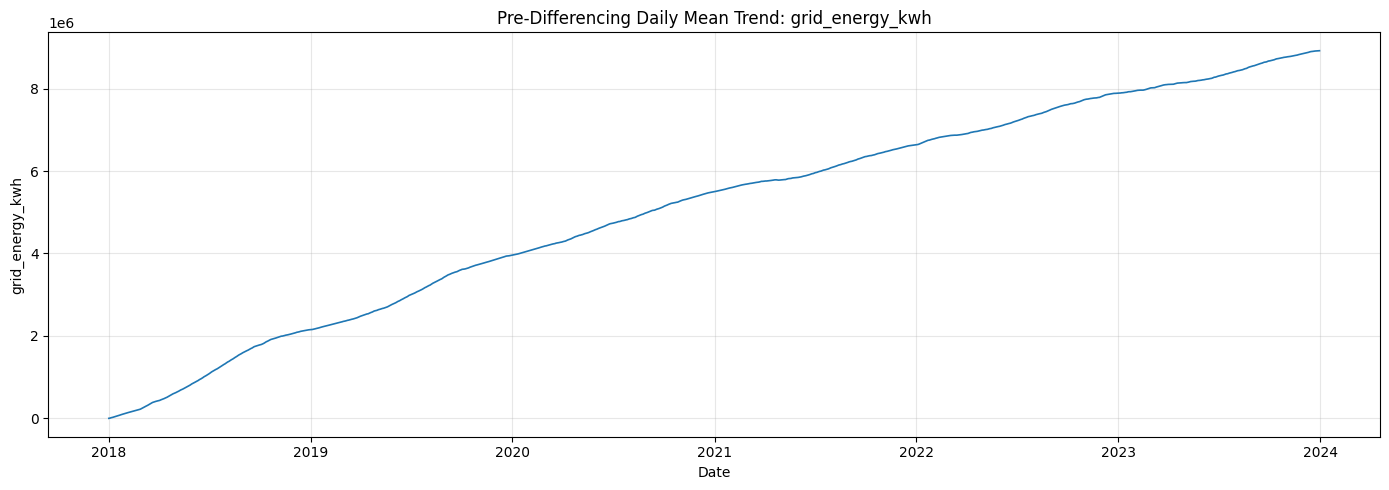

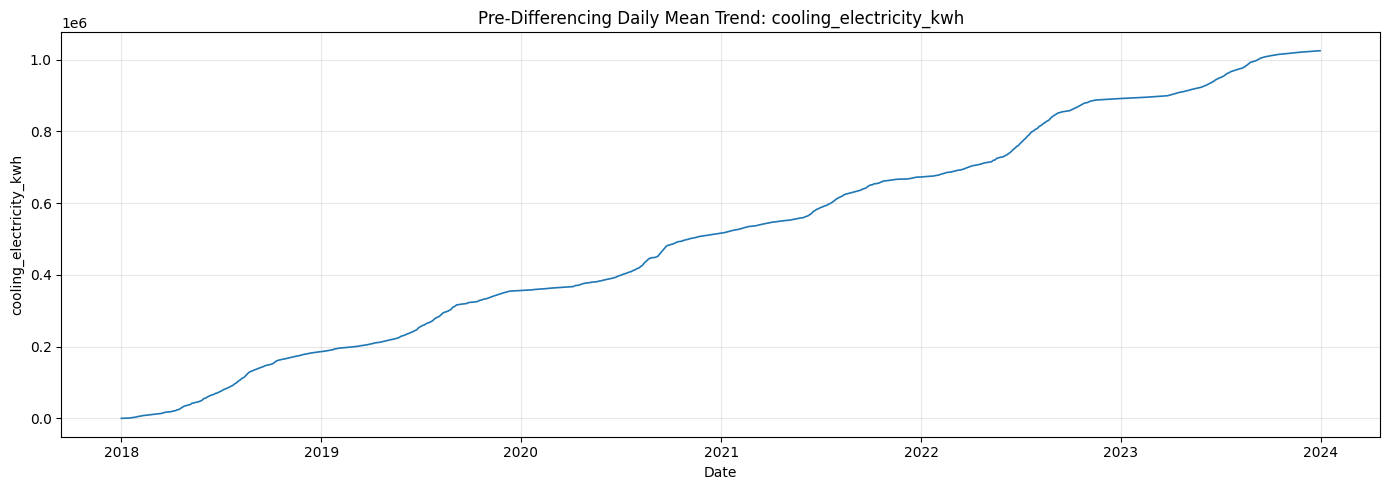

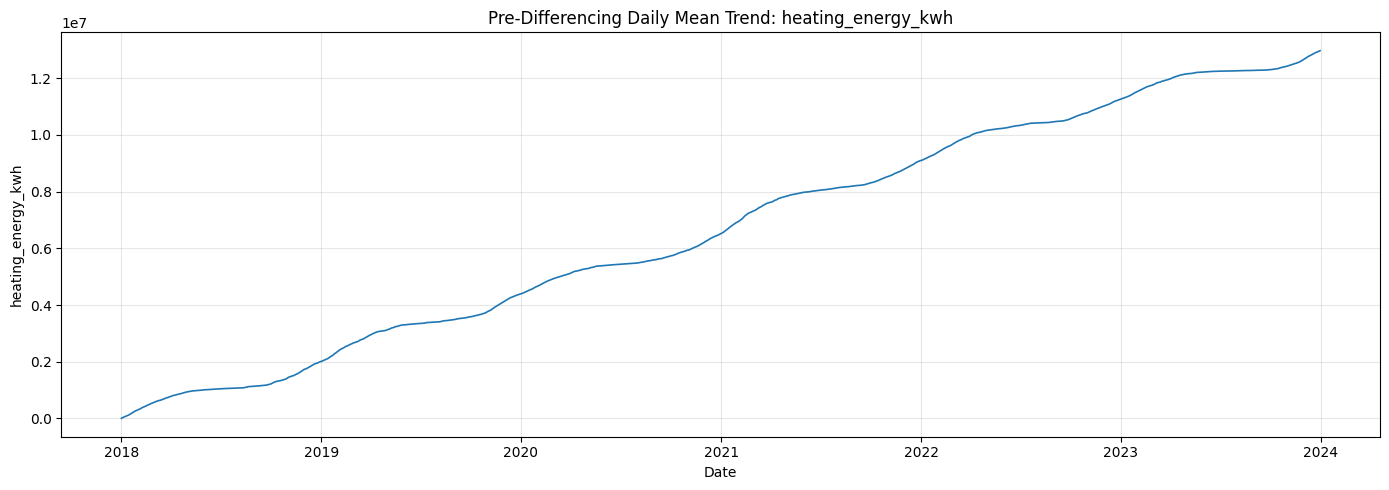

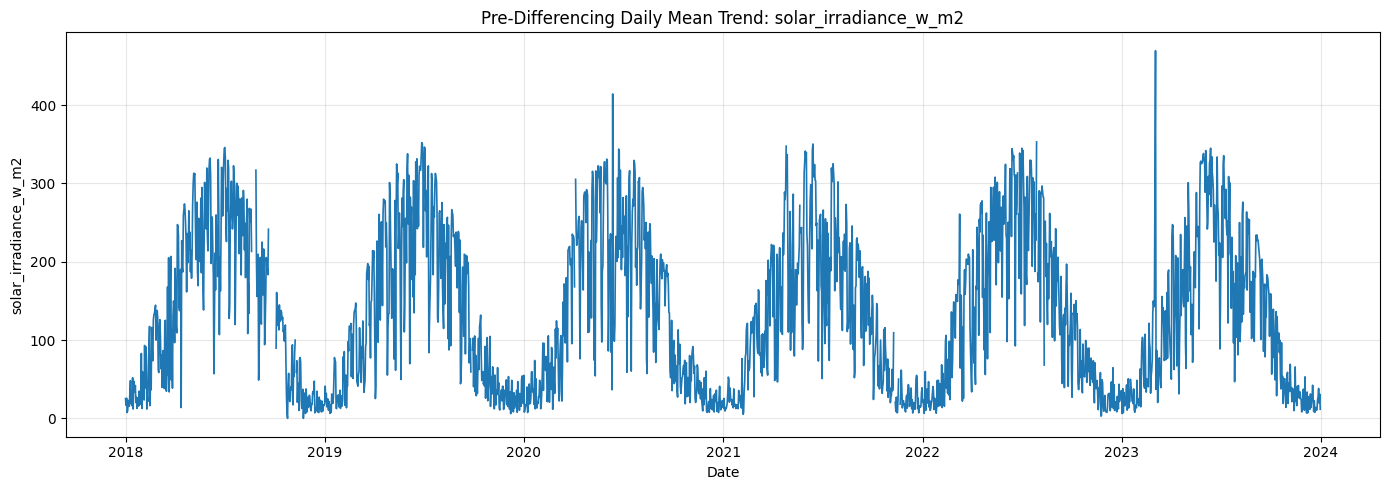

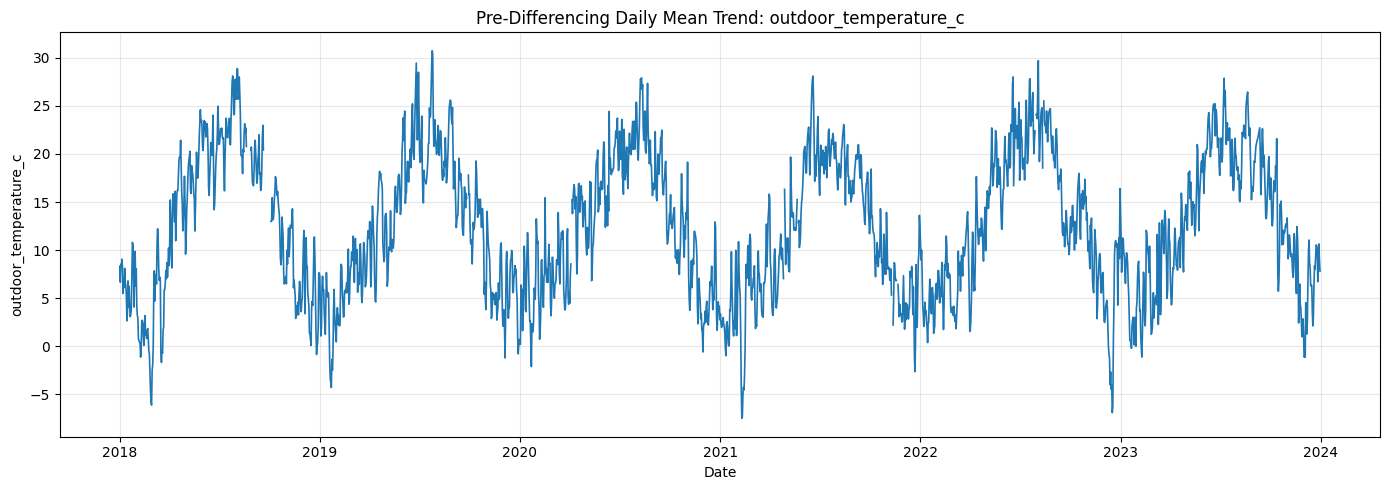

time: 1.25 s (started: 2026-05-31 13:29:18 +03:00)


In [40]:
pre_differencing_plot_columns = [
    "grid_energy_kwh",
    "cooling_electricity_kwh",
    "heating_energy_kwh",
    "solar_irradiance_w_m2",
    "outdoor_temperature_c"
]


plot_pre_differencing_daily_trend(
    model_df_pre_transform,
    columns=pre_differencing_plot_columns,
    save_dir=EDA_OUTPUT_DIR
)

## Note
----------------
- It was noticed that some of the variables were cummulative which needs differencing to make it back to original state

In [41]:
def convert_cumulative_energy_to_hourly_increment( df: pd.DataFrame, cumulative_columns: Sequence[str], datetime_col: str = DATETIME_COL, drop_first_row: bool = True ) -> pd.DataFrame:
    """
    Convert cumulative W/kWh energy readings into hourly increments.

    The same column names are maintained after transformation.

    hourly value at time t = cumulative value at time t - cumulative value at time t-1
    """
    df = df.copy().sort_values(datetime_col).reset_index(drop=True)

    missing_columns = [col for col in cumulative_columns if col not in df.columns]

    if missing_columns:
        raise ValueError(f"Columns not found: {missing_columns}")

    for col in cumulative_columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").diff()

    if drop_first_row:
        df = df.iloc[1:].reset_index(drop=True)

    return df


time: 0 ns (started: 2026-05-31 13:29:19 +03:00)


In [42]:
energy_columns_to_difference = [
    col for col in model_df_pre_transform.columns
    if col != DATETIME_COL and col.endswith("_kwh")
]

print("Energy columns to difference:")
print(energy_columns_to_difference, "\n")

validate_hourly_sequence(model_df_pre_transform)

model_df = convert_cumulative_energy_to_hourly_increment(
    df=model_df_pre_transform,
    cumulative_columns=energy_columns_to_difference,
    datetime_col=DATETIME_COL,
    drop_first_row=True
)

print("Differencing completed.")
print("model_df now contains hourly increment values with the same column names.")
print("Shape:", model_df.shape)

display(model_df.head(3))
display(model_df.tail(3))

Energy columns to difference:
['grid_energy_kwh', 'chp_energy_kwh', 'cooling_energy_kwh', 'cooling_electricity_kwh', 'heating_energy_kwh', 'chp_heat_energy_kwh', 'chp_electricity_from_heating_kwh'] 

Datetime sequence is hourly and continuous.
Differencing completed.
model_df now contains hourly increment values with the same column names.
Shape: (52582, 10)


,datetime_utc,grid_energy_kwh,chp_energy_kwh,cooling_energy_kwh,cooling_electricity_kwh,heating_energy_kwh,chp_heat_energy_kwh,chp_electricity_from_heating_kwh,solar_irradiance_w_m2,outdoor_temperature_c
0,2018-01-01 01:00:00+00:00,74.667256,-116.000000,0.000000,0.792500,300.000000,193.333333,-116.000000,0.000000,11.316956
1,2018-01-01 02:00:00+00:00,2.521144,-186.440000,0.000000,0.803333,400.000000,285.000000,-186.440000,0.000000,10.963065
2,2018-01-01 03:00:00+00:00,48.046771,-142.550000,0.000000,0.794167,300.000000,235.000000,-142.550000,0.000000,10.499501


,datetime_utc,grid_energy_kwh,chp_energy_kwh,cooling_energy_kwh,cooling_electricity_kwh,heating_energy_kwh,chp_heat_energy_kwh,chp_electricity_from_heating_kwh,solar_irradiance_w_m2,outdoor_temperature_c
52579,2023-12-31 20:00:00+00:00,47.348448,-184.730000,100.000000,4.970000,300.000000,290.000000,-184.730000,0.000034,7.960528
52580,2023-12-31 21:00:00+00:00,42.867470,-185.950000,0.000000,4.890000,400.000000,300.000000,-185.950000,0.001582,8.033087
52581,2023-12-31 22:00:00+00:00,41.308005,-185.270000,0.000000,5.160000,400.000000,300.000000,-185.270000,0.000215,7.911465


time: 16 ms (started: 2026-05-31 13:29:19 +03:00)


# Data Preprocessing

## Find Any 0 values for consumed electricity (and check if it is a fault to remove or it is by default a 0)

In [43]:
def find_zero_values_in_column( df: pd.DataFrame, column: str, datetime_col: str = DATETIME_COL, tolerance: float = 1e-9 ) -> pd.DataFrame:
    """
    Find rows where a selected numeric column is zero or very close to zero.
    """
    if column not in df.columns:
        raise ValueError(f"Column not found: {column}")

    if datetime_col not in df.columns:
        raise ValueError(f"Datetime column not found: {datetime_col}")

    df = df.copy()
    df = df.sort_values(datetime_col).reset_index(drop=True)

    zero_mask = np.isclose(df[column], 0, atol=tolerance)

    zero_rows = df.loc[zero_mask].copy()

    print(f"Column checked: {column}")
    print(f"Zero rows found: {len(zero_rows)}")
    print(f"Percentage of dataset: {len(zero_rows) / len(df) * 100:.4f}%")

    return zero_rows

time: 0 ns (started: 2026-05-31 13:29:19 +03:00)


In [44]:
target_source_col = PROJECT_FEATURE_POLICY["target_source_column"]

zero_grid_rows = find_zero_values_in_column(
    model_df,
    column=target_source_col
)

display(zero_grid_rows.head(20))

Column checked: grid_energy_kwh
Zero rows found: 0
Percentage of dataset: 0.0000%


,datetime_utc,grid_energy_kwh,chp_energy_kwh,cooling_energy_kwh,cooling_electricity_kwh,heating_energy_kwh,chp_heat_energy_kwh,chp_electricity_from_heating_kwh,solar_irradiance_w_m2,outdoor_temperature_c


time: 16 ms (started: 2026-05-31 13:29:19 +03:00)


In [45]:
model_df.head(3)

,datetime_utc,grid_energy_kwh,chp_energy_kwh,cooling_energy_kwh,cooling_electricity_kwh,heating_energy_kwh,chp_heat_energy_kwh,chp_electricity_from_heating_kwh,solar_irradiance_w_m2,outdoor_temperature_c
0,2018-01-01 01:00:00+00:00,74.667256,-116.000000,0.000000,0.792500,300.000000,193.333333,-116.000000,0.000000,11.316956
1,2018-01-01 02:00:00+00:00,2.521144,-186.440000,0.000000,0.803333,400.000000,285.000000,-186.440000,0.000000,10.963065
2,2018-01-01 03:00:00+00:00,48.046771,-142.550000,0.000000,0.794167,300.000000,235.000000,-142.550000,0.000000,10.499501


time: 0 ns (started: 2026-05-31 13:29:19 +03:00)


## Find Columns that contain values of 0 and remove the rows if it is not logical

In [46]:
def zero_value_report( df: pd.DataFrame, datetime_col: str = DATETIME_COL, columns: Sequence[str] | None = None,tolerance: float = 1e-9) -> pd.DataFrame:
    """
    Create a zero-value report for each numeric column individually.

    A value is considered zero if it is very close to 0 within the tolerance.
    NaN values are not counted as zero.
    """
    if datetime_col not in df.columns:
        raise ValueError(f"Datetime column not found: {datetime_col}")

    df = df.copy().sort_values(datetime_col).reset_index(drop=True)

    if columns is None:
        columns = df.select_dtypes(include="number").columns.tolist()
    else:
        missing_columns = [col for col in columns if col not in df.columns]
        if missing_columns:
            raise ValueError(f"Columns not found: {missing_columns}")

    records = []

    for col in columns:
        numeric_series = pd.to_numeric(df[col], errors="coerce")

        zero_mask = numeric_series.notna() & np.isclose(
            numeric_series,
            0,
            atol=tolerance
        )

        zero_count = int(zero_mask.sum())
        zero_percentage = zero_count / len(df) * 100

        if zero_count > 0:
            first_zero_time = df.loc[zero_mask, datetime_col].min()
            last_zero_time = df.loc[zero_mask, datetime_col].max()
        else:
            first_zero_time = pd.NaT
            last_zero_time = pd.NaT

        records.append({
            "column": col,
            "zero_count": zero_count,
            "zero_percentage": round(zero_percentage, 3),
            "first_zero_time": first_zero_time,
            "last_zero_time": last_zero_time,
            "missing_count": int(numeric_series.isna().sum())
        })

    report = pd.DataFrame(records)

    return report.sort_values(
        by="zero_count",
        ascending=False
    ).reset_index(drop=True)


zero_report = zero_value_report(model_df)

display(zero_report)

,column,zero_count,zero_percentage,first_zero_time,last_zero_time,missing_count
0,chp_heat_energy_kwh,26353,50.118000,2018-01-03 06:00:00+00:00,2023-12-12 10:00:00+00:00,0
1,cooling_energy_kwh,24946,47.442000,2018-01-01 01:00:00+00:00,2023-12-31 22:00:00+00:00,0
2,solar_irradiance_w_m2,17273,32.850000,2018-01-01 01:00:00+00:00,2023-12-31 19:00:00+00:00,1234
3,heating_energy_kwh,9170,17.439000,2018-01-26 09:00:00+00:00,2023-10-30 06:00:00+00:00,0
4,chp_electricity_from_heating_kwh,16,0.030000,2018-11-29 03:00:00+00:00,2020-11-06 07:00:00+00:00,0
5,chp_energy_kwh,16,0.030000,2018-11-29 03:00:00+00:00,2020-11-06 07:00:00+00:00,0
6,grid_energy_kwh,0,0.000000,NaT,NaT,0
7,cooling_electricity_kwh,0,0.000000,NaT,NaT,0
8,outdoor_temperature_c,0,0.000000,NaT,NaT,1234


time: 0 ns (started: 2026-05-31 13:29:19 +03:00)


- Solar irradiance won't be removed because at night time it can be 0, and also for cooling energy it can be that there was a maintenance, or cooling simply was not used

---------------------------------

## Recover Missing Weather Temperature Using Open-Meteo & add humidity

### Fetch Historical Weather Data from Open-Meteo

In [47]:
def fetch_open_meteo_historical_weather( start_date: str, end_date: str, latitude: float = BUILDING_LATITUDE,
                                        longitude: float = BUILDING_LONGITUDE, timezone: str = "UTC" ) -> pd.DataFrame:
    """
    Fetch hourly historical weather and solar radiation variables from Open-Meteo.

    Returns hourly data in UTC so it can merge directly with datetime_utc.
    Solar variables are treated as external proxy candidates for the original Igm sensor.
    """

    base_url = "https://archive-api.open-meteo.com/v1/archive"

    hourly_variables = [
        "temperature_2m",
        "relative_humidity_2m",

        # Solar/radiation candidates
        "shortwave_radiation",
        "shortwave_radiation_instant",
        "direct_radiation",
        "direct_radiation_instant",
        "diffuse_radiation",
        "diffuse_radiation_instant",
        "direct_normal_irradiance",
        "direct_normal_irradiance_instant",
        "global_tilted_irradiance",
        "global_tilted_irradiance_instant",
        "terrestrial_radiation",
        "terrestrial_radiation_instant"
    ]

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": ",".join(hourly_variables),
        "timezone": timezone,

        # Required for GTI. 0 means horizontal surface. It is because we don't know the exact mounting angle of their solar panels
        # This makes GTI comparable to horizontal radiation-style variables.
        "tilt": 0,
        "azimuth": 0
    }

    response = requests.get(base_url, params=params, timeout=60)
    response.raise_for_status()

    data = response.json()

    if "hourly" not in data:
        raise ValueError(f"No hourly data returned from Open-Meteo. Response: {data}")

    weather_df = pd.DataFrame(data["hourly"])

    weather_df["datetime_utc"] = pd.to_datetime(
        weather_df["time"],
        utc=True,
        errors="coerce"
    )

    weather_df = weather_df.drop(columns=["time"])

    weather_df = weather_df.rename(columns={
        "temperature_2m": "openmeteo_temperature_2m_c",
        "relative_humidity_2m": "openmeteo_relative_humidity_2m",

        "shortwave_radiation": "openmeteo_shortwave_radiation_w_m2",
        "shortwave_radiation_instant": "openmeteo_shortwave_radiation_instant_w_m2",

        "direct_radiation": "openmeteo_direct_radiation_w_m2",
        "direct_radiation_instant": "openmeteo_direct_radiation_instant_w_m2",

        "diffuse_radiation": "openmeteo_diffuse_radiation_w_m2",
        "diffuse_radiation_instant": "openmeteo_diffuse_radiation_instant_w_m2",

        "direct_normal_irradiance": "openmeteo_dni_w_m2",
        "direct_normal_irradiance_instant": "openmeteo_dni_instant_w_m2",

        "global_tilted_irradiance": "openmeteo_gti_w_m2",
        "global_tilted_irradiance_instant": "openmeteo_gti_instant_w_m2",

        "terrestrial_radiation": "openmeteo_terrestrial_radiation_w_m2",
        "terrestrial_radiation_instant": "openmeteo_terrestrial_radiation_instant_w_m2"
    })

    weather_df = weather_df.sort_values("datetime_utc").reset_index(drop=True)

    return weather_df

time: 0 ns (started: 2026-05-31 13:29:19 +03:00)


In [48]:
weather_start_date = model_df[DATETIME_COL].min().date().isoformat()
weather_end_date = model_df[DATETIME_COL].max().date().isoformat()

print("Fetching Open-Meteo weather from", weather_start_date, "to", weather_end_date)

openmeteo_weather_df = fetch_open_meteo_historical_weather(
    start_date=weather_start_date,
    end_date=weather_end_date,
    timezone="UTC"
)

print(openmeteo_weather_df.shape)
display(openmeteo_weather_df.head())

Fetching Open-Meteo weather from 2018-01-01 to 2023-12-31
(52584, 15)


,openmeteo_temperature_2m_c,openmeteo_relative_humidity_2m,openmeteo_shortwave_radiation_w_m2,openmeteo_shortwave_radiation_instant_w_m2,openmeteo_direct_radiation_w_m2,openmeteo_direct_radiation_instant_w_m2,openmeteo_diffuse_radiation_w_m2,openmeteo_diffuse_radiation_instant_w_m2,openmeteo_dni_w_m2,openmeteo_dni_instant_w_m2,openmeteo_gti_w_m2,openmeteo_gti_instant_w_m2,openmeteo_terrestrial_radiation_w_m2,openmeteo_terrestrial_radiation_instant_w_m2,datetime_utc
0,10.100000,80,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2018-01-01 00:00:00+00:00
1,10.000000,78,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2018-01-01 01:00:00+00:00
2,9.200000,78,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2018-01-01 02:00:00+00:00
3,8.900000,73,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2018-01-01 03:00:00+00:00
4,8.400000,72,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2018-01-01 04:00:00+00:00


time: 4.52 s (started: 2026-05-31 13:29:19 +03:00)


### Check if radiation matches dataframe values

In [49]:
radiation_candidates = [
    "openmeteo_shortwave_radiation_w_m2",
    "openmeteo_shortwave_radiation_instant_w_m2",
    "openmeteo_direct_radiation_w_m2",
    "openmeteo_direct_radiation_instant_w_m2",
    "openmeteo_diffuse_radiation_w_m2",
    "openmeteo_diffuse_radiation_instant_w_m2",
    "openmeteo_dni_w_m2",
    "openmeteo_dni_instant_w_m2",
    "openmeteo_gti_w_m2",
    "openmeteo_gti_instant_w_m2",
    "openmeteo_terrestrial_radiation_w_m2",
    "openmeteo_terrestrial_radiation_instant_w_m2"
]

time: 0 ns (started: 2026-05-31 13:29:24 +03:00)


In [50]:
weather_validation_df = model_df.merge(
    openmeteo_weather_df,
    on=DATETIME_COL,
    how="left",
    validate="one_to_one"
)

comparison_rows = []

for candidate in radiation_candidates:
    temp = weather_validation_df[
        ["solar_irradiance_w_m2", candidate]
    ].dropna()

    if len(temp) == 0:
        continue

    corr = temp["solar_irradiance_w_m2"].corr(temp[candidate])
    mae = mean_absolute_error(temp["solar_irradiance_w_m2"], temp[candidate])
    rmse = np.sqrt(mean_squared_error(temp["solar_irradiance_w_m2"], temp[candidate]))

    comparison_rows.append({
        "candidate_variable": candidate,
        "available_overlap_rows": len(temp),
        "correlation_with_original_Igm": corr,
        "MAE_vs_original_Igm": mae,
        "RMSE_vs_original_Igm": rmse
    })

radiation_comparison_df = pd.DataFrame(comparison_rows).sort_values(
    by=["correlation_with_original_Igm", "RMSE_vs_original_Igm"],
    ascending=[False, True]
).reset_index(drop=True)

display(radiation_comparison_df)

,candidate_variable,available_overlap_rows,correlation_with_original_Igm,MAE_vs_original_Igm,RMSE_vs_original_Igm
0,openmeteo_shortwave_radiation_instant_w_m2,51348,0.940330,38.154792,74.532462
1,openmeteo_gti_instant_w_m2,51348,0.940316,38.170717,74.541737
2,openmeteo_shortwave_radiation_w_m2,51348,0.919792,47.780282,86.047687
3,openmeteo_gti_w_m2,51348,0.919791,47.780384,86.048446
4,openmeteo_direct_radiation_instant_w_m2,51348,0.900416,55.421552,108.781467
5,openmeteo_direct_radiation_w_m2,51348,0.884100,59.782141,114.395009
6,openmeteo_terrestrial_radiation_instant_w_m2,51348,0.875909,153.303884,257.911017
7,openmeteo_terrestrial_radiation_w_m2,51348,0.849485,156.864248,264.930477
8,openmeteo_dni_instant_w_m2,51348,0.841878,79.913136,146.645139
9,openmeteo_dni_w_m2,51348,0.822330,80.540189,149.476131


time: 31 ms (started: 2026-05-31 13:29:24 +03:00)


### Plot to check if radiation matches dataframe values

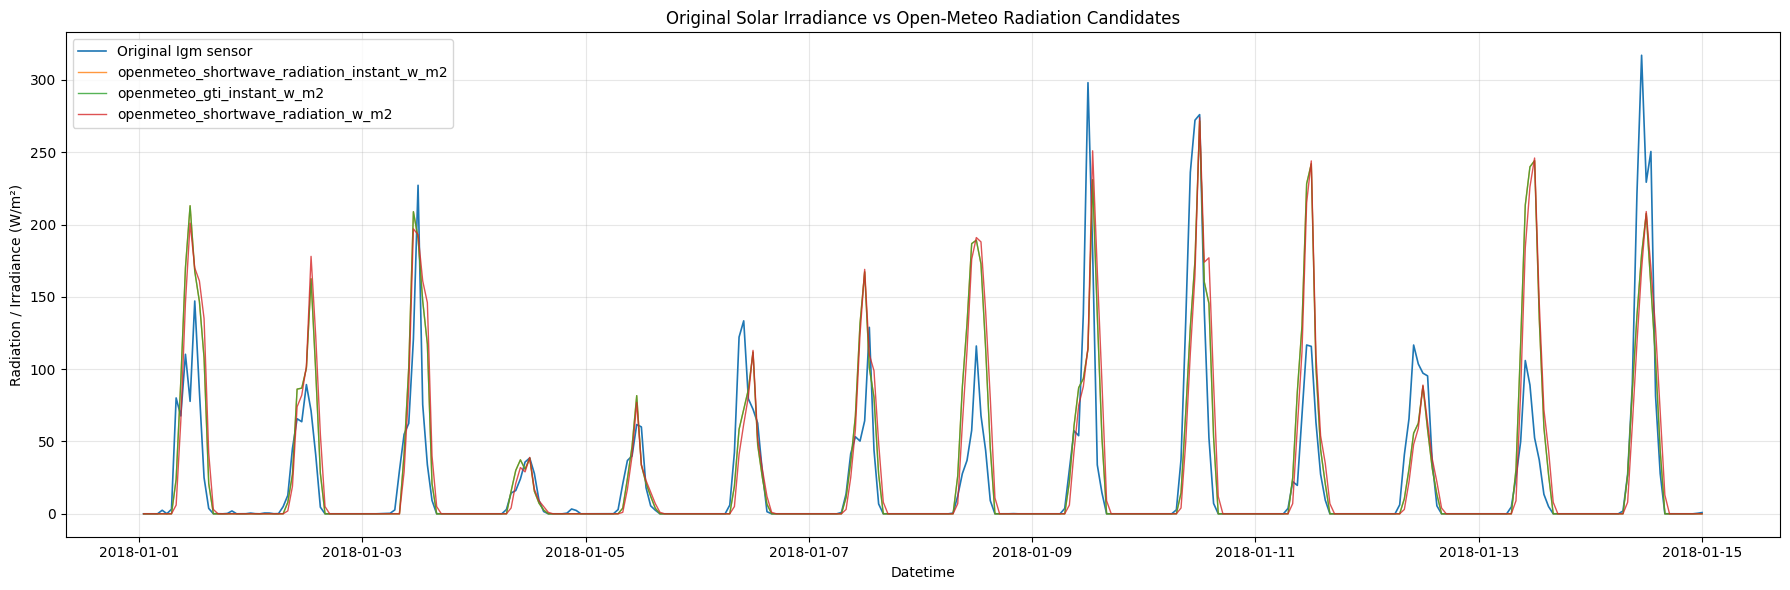

time: 109 ms (started: 2026-05-31 13:29:24 +03:00)


In [51]:
best_radiation_candidates = radiation_comparison_df["candidate_variable"].head(3).tolist()

plot_sample = weather_validation_df[
    [DATETIME_COL, "solar_irradiance_w_m2"] + best_radiation_candidates
].dropna().copy()

# Choose a smaller window so the plot is readable
plot_sample = plot_sample.head(24 * 14)

plt.figure(figsize=(18, 6))

plt.plot(
    plot_sample[DATETIME_COL],
    plot_sample["solar_irradiance_w_m2"],
    label="Original Igm sensor",
    linewidth=1.2
)

for candidate in best_radiation_candidates:
    plt.plot(
        plot_sample[DATETIME_COL],
        plot_sample[candidate],
        label=candidate,
        linewidth=1.0,
        alpha=0.8
    )

plt.title("Original Solar Irradiance vs Open-Meteo Radiation Candidates")
plt.xlabel("Datetime")
plt.ylabel("Radiation / Irradiance (W/m²)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Note
----------------
- It was noticed that Radiation does't match data. Therefore it will not be used for imputation

### Validate Open-Meteo Temperature Against Original Sensor

In [52]:
weather_validation_df = model_df.merge(
    openmeteo_weather_df,
    on=DATETIME_COL,
    how="left",
    validate="one_to_one"
)

time: 0 ns (started: 2026-05-31 13:29:24 +03:00)


In [53]:
temperature_comparison_df = weather_validation_df[
    [
        DATETIME_COL,
        "outdoor_temperature_c",
        "openmeteo_temperature_2m_c"
    ]
].dropna().copy()

print("Available overlap rows:", len(temperature_comparison_df))

temp_corr = temperature_comparison_df["outdoor_temperature_c"].corr(
    temperature_comparison_df["openmeteo_temperature_2m_c"]
)

temp_mae = mean_absolute_error(
    temperature_comparison_df["outdoor_temperature_c"],
    temperature_comparison_df["openmeteo_temperature_2m_c"]
)

temp_rmse = np.sqrt(mean_squared_error(
    temperature_comparison_df["outdoor_temperature_c"],
    temperature_comparison_df["openmeteo_temperature_2m_c"]
))

temp_bias = (
    temperature_comparison_df["openmeteo_temperature_2m_c"]
    - temperature_comparison_df["outdoor_temperature_c"]
).mean()

temperature_validation_summary = pd.DataFrame([{
    "candidate_variable": "openmeteo_temperature_2m_c",
    "available_overlap_rows": len(temperature_comparison_df),
    "correlation_with_original_temperature": temp_corr,
    "MAE_vs_original_temperature": temp_mae,
    "RMSE_vs_original_temperature": temp_rmse,
    "mean_bias_openmeteo_minus_original": temp_bias
}])

display(temperature_validation_summary)

Available overlap rows: 51348


,candidate_variable,available_overlap_rows,correlation_with_original_temperature,MAE_vs_original_temperature,RMSE_vs_original_temperature,mean_bias_openmeteo_minus_original
0,openmeteo_temperature_2m_c,51348,0.987866,1.155857,1.474119,-0.710244


time: 0 ns (started: 2026-05-31 13:29:24 +03:00)


### Plot to check if temperature matches dataframe values

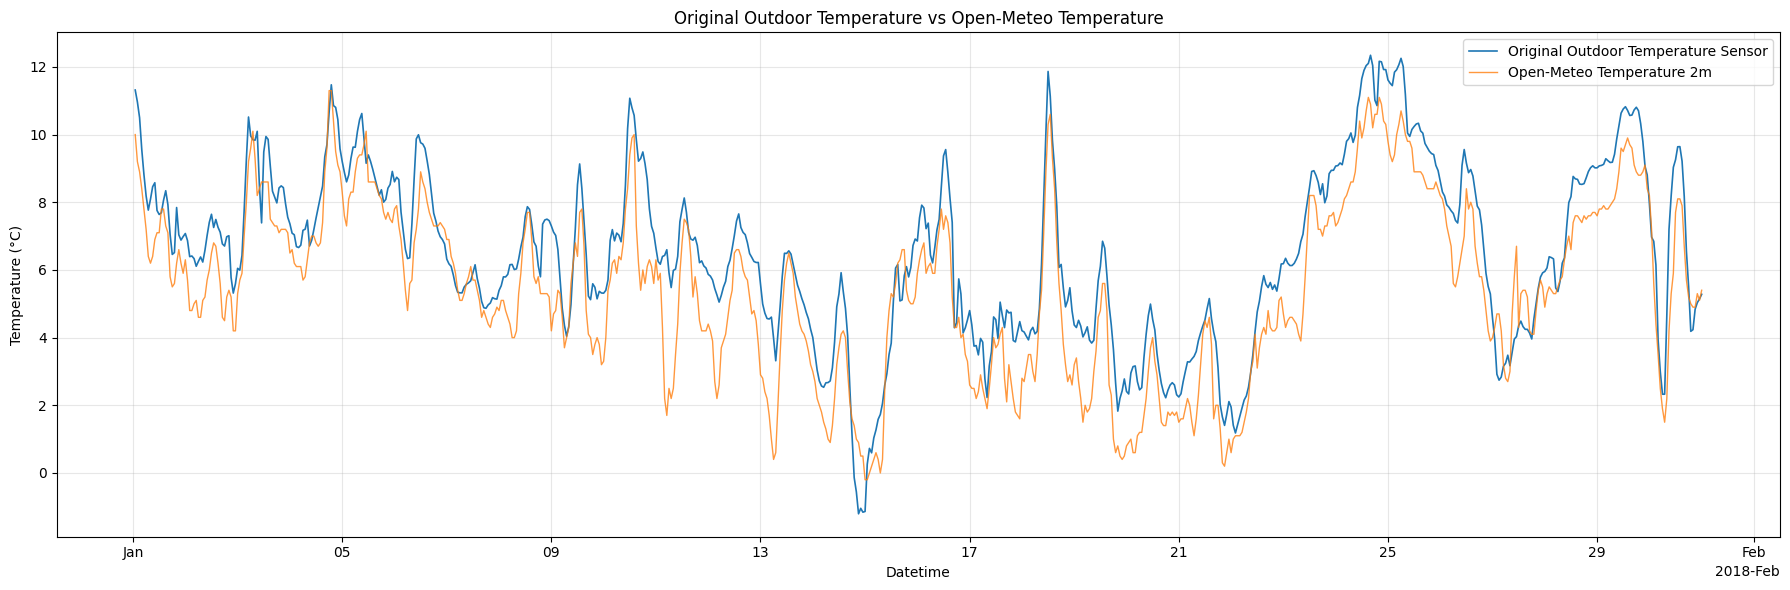

time: 94 ms (started: 2026-05-31 13:29:24 +03:00)


In [54]:
temperature_plot_sample = temperature_comparison_df.copy()

# Show first 30 days only so it is readable
temperature_plot_sample = temperature_plot_sample.head(24 * 30)

plt.figure(figsize=(18, 6))

plt.plot(
    temperature_plot_sample[DATETIME_COL],
    temperature_plot_sample["outdoor_temperature_c"],
    label="Original Outdoor Temperature Sensor",
    linewidth=1.2
)

plt.plot(
    temperature_plot_sample[DATETIME_COL],
    temperature_plot_sample["openmeteo_temperature_2m_c"],
    label="Open-Meteo Temperature 2m",
    linewidth=1.0,
    alpha=0.8
)

plt.title("Original Outdoor Temperature vs Open-Meteo Temperature")
plt.xlabel("Datetime")
plt.ylabel("Temperature (°C)")
plt.grid(True, alpha=0.3)
plt.legend()

ax = plt.gca()
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

### Note
----------------
- It was noticed that temperature matches data, but there is a small bias which can be removed to make the temperature be as similar as possible to actual data
- The temperature API data will be used to impute temperature

### Apply Bias Correction to Open-Meteo Temperature

In [55]:
temperature_bias = (
    temperature_comparison_df["openmeteo_temperature_2m_c"]
    - temperature_comparison_df["outdoor_temperature_c"]
).mean()

print("Temperature bias:", temperature_bias)

weather_validation_df["openmeteo_temperature_2m_c_bias_corrected"] = (
    weather_validation_df["openmeteo_temperature_2m_c"] - temperature_bias
)

weather_validation_df["outdoor_temperature_c_filled"] = (
    weather_validation_df["outdoor_temperature_c"]
    .fillna(weather_validation_df["openmeteo_temperature_2m_c_bias_corrected"])
)

Temperature bias: -0.7102435356050567
time: 16 ms (started: 2026-05-31 13:29:24 +03:00)


In [56]:
temperature_bias_check_df = weather_validation_df[
    [
        DATETIME_COL,
        "outdoor_temperature_c",
        "openmeteo_temperature_2m_c",
        "openmeteo_temperature_2m_c_bias_corrected"
    ]
].dropna().copy()

temp_comparison_rows = []

for candidate in [
    "openmeteo_temperature_2m_c",
    "openmeteo_temperature_2m_c_bias_corrected"
]:
    corr = temperature_bias_check_df["outdoor_temperature_c"].corr(
        temperature_bias_check_df[candidate]
    )

    mae = mean_absolute_error(
        temperature_bias_check_df["outdoor_temperature_c"],
        temperature_bias_check_df[candidate]
    )

    rmse = np.sqrt(mean_squared_error(
        temperature_bias_check_df["outdoor_temperature_c"],
        temperature_bias_check_df[candidate]
    ))

    bias = (
        temperature_bias_check_df[candidate]
        - temperature_bias_check_df["outdoor_temperature_c"]
    ).mean()

    temp_comparison_rows.append({
        "candidate_variable": candidate,
        "available_overlap_rows": len(temperature_bias_check_df),
        "correlation_with_original_temperature": corr,
        "MAE_vs_original_temperature": mae,
        "RMSE_vs_original_temperature": rmse,
        "mean_bias_candidate_minus_original": bias
    })

temperature_bias_comparison_df = pd.DataFrame(temp_comparison_rows).sort_values(
    "RMSE_vs_original_temperature"
).reset_index(drop=True)

display(temperature_bias_comparison_df)

,candidate_variable,available_overlap_rows,correlation_with_original_temperature,MAE_vs_original_temperature,RMSE_vs_original_temperature,mean_bias_candidate_minus_original
0,openmeteo_temperature_2m_c_bias_corrected,51348,0.987866,0.967761,1.291736,-0.000000
1,openmeteo_temperature_2m_c,51348,0.987866,1.155857,1.474119,-0.710244


time: 16 ms (started: 2026-05-31 13:29:24 +03:00)


### Plot temperature after applying bias to check weather forecast values

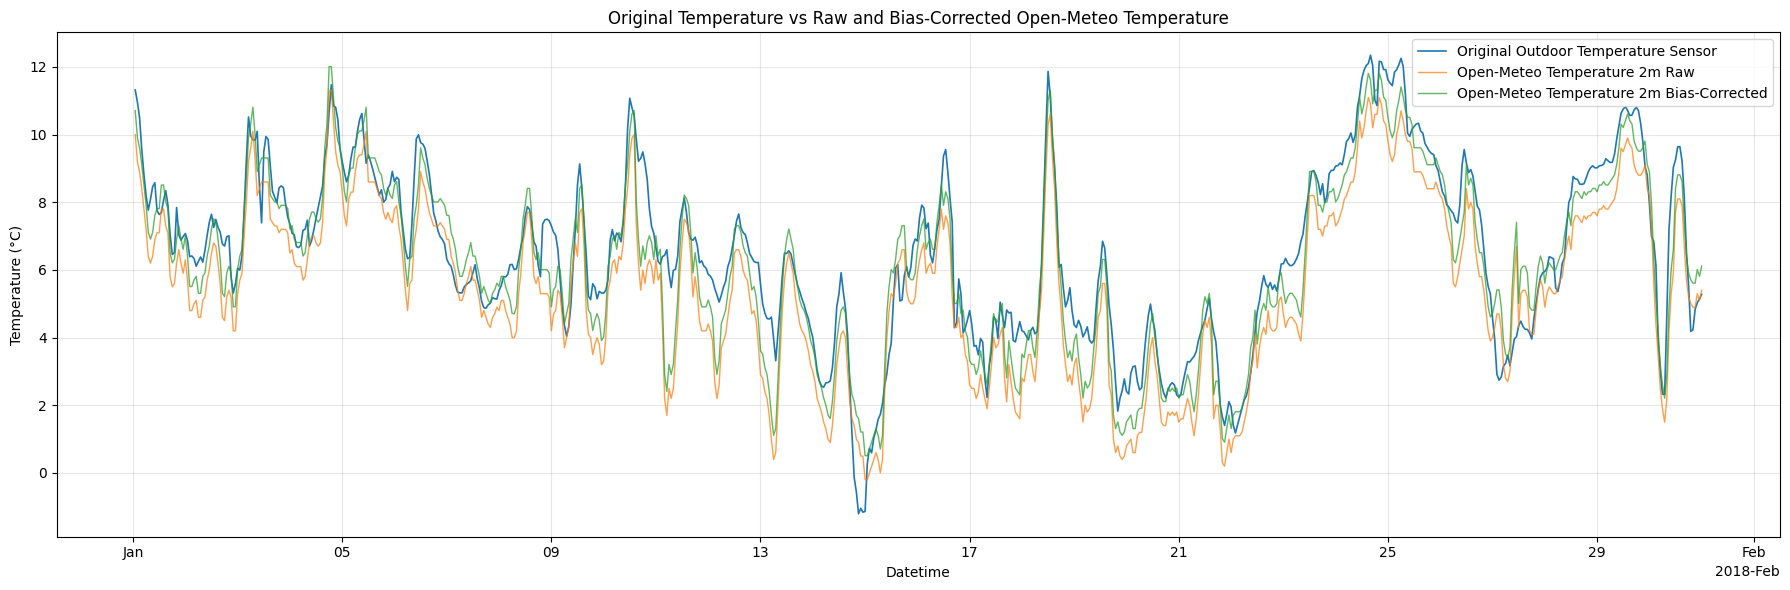

time: 94 ms (started: 2026-05-31 13:29:24 +03:00)


In [57]:
temperature_plot_sample = temperature_bias_check_df.copy()

# First 30 days only for readability
temperature_plot_sample = temperature_plot_sample.head(24 * 30)

plt.figure(figsize=(18, 6))

plt.plot(
    temperature_plot_sample[DATETIME_COL],
    temperature_plot_sample["outdoor_temperature_c"],
    label="Original Outdoor Temperature Sensor",
    linewidth=1.2
)

plt.plot(
    temperature_plot_sample[DATETIME_COL],
    temperature_plot_sample["openmeteo_temperature_2m_c"],
    label="Open-Meteo Temperature 2m Raw",
    linewidth=1.0,
    alpha=0.75
)

plt.plot(
    temperature_plot_sample[DATETIME_COL],
    temperature_plot_sample["openmeteo_temperature_2m_c_bias_corrected"],
    label="Open-Meteo Temperature 2m Bias-Corrected",
    linewidth=1.0,
    alpha=0.75
)

plt.title("Original Temperature vs Raw and Bias-Corrected Open-Meteo Temperature")
plt.xlabel("Datetime")
plt.ylabel("Temperature (°C)")
plt.grid(True, alpha=0.3)
plt.legend()

ax = plt.gca()
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

### Note
----------------
- It was noticed that temperature is very close to actual data, therefore it will be used to impute the missing data

### Fill Missing Outdoor Temperature Values

In [58]:
model_df_temp_humidity = model_df.copy()

model_df_temp_humidity = model_df_temp_humidity.merge(
    weather_validation_df[
        [
            DATETIME_COL,
            "openmeteo_temperature_2m_c_bias_corrected",
            "openmeteo_relative_humidity_2m"
        ]
    ],
    on=DATETIME_COL,
    how="left",
    validate="one_to_one"
)

model_df_temp_humidity["outdoor_temperature_c"] = (
    model_df_temp_humidity["outdoor_temperature_c"]
    .fillna(model_df_temp_humidity["openmeteo_temperature_2m_c_bias_corrected"])
)

time: 16 ms (started: 2026-05-31 13:29:25 +03:00)


In [59]:
model_df_temp_humidity["relative_humidity_2m"] = (
    model_df_temp_humidity["openmeteo_relative_humidity_2m"]
)

# Drop helper Open-Meteo columns after using them
model_df_temp_humidity = model_df_temp_humidity.drop(
    columns=[
        "openmeteo_temperature_2m_c_bias_corrected",
        "openmeteo_relative_humidity_2m"
    ],
    errors="ignore"
)

# Drop solar irradiance for this experiment because radiation did not match well
model_df_temp_humidity = model_df_temp_humidity.drop(
    columns=["solar_irradiance_w_m2"],
    errors="ignore"
)

print("Original model_df shape:", model_df.shape)
print("Temperature + humidity experiment shape:", model_df_temp_humidity.shape)

display(model_df_temp_humidity.head())

display(
    model_df_temp_humidity[
        ["outdoor_temperature_c", "relative_humidity_2m"]
    ].isna().sum()
)

print("Columns in final weather experiment dataframe:")
print(model_df_temp_humidity.columns.tolist())

Original model_df shape: (52582, 10)
Temperature + humidity experiment shape: (52582, 10)


,datetime_utc,grid_energy_kwh,chp_energy_kwh,cooling_energy_kwh,cooling_electricity_kwh,heating_energy_kwh,chp_heat_energy_kwh,chp_electricity_from_heating_kwh,outdoor_temperature_c,relative_humidity_2m
0,2018-01-01 01:00:00+00:00,74.667256,-116.000000,0.000000,0.792500,300.000000,193.333333,-116.000000,11.316956,78
1,2018-01-01 02:00:00+00:00,2.521144,-186.440000,0.000000,0.803333,400.000000,285.000000,-186.440000,10.963065,78
2,2018-01-01 03:00:00+00:00,48.046771,-142.550000,0.000000,0.794167,300.000000,235.000000,-142.550000,10.499501,73
3,2018-01-01 04:00:00+00:00,25.126963,-165.370000,0.000000,0.800000,400.000000,250.000000,-165.370000,9.560892,72
4,2018-01-01 05:00:00+00:00,3.993467,-189.340000,0.000000,0.799167,500.000000,290.000000,-189.340000,8.818692,73


outdoor_temperature_c    0
relative_humidity_2m     0
dtype: int64

Columns in final weather experiment dataframe:
['datetime_utc', 'grid_energy_kwh', 'chp_energy_kwh', 'cooling_energy_kwh', 'cooling_electricity_kwh', 'heating_energy_kwh', 'chp_heat_energy_kwh', 'chp_electricity_from_heating_kwh', 'outdoor_temperature_c', 'relative_humidity_2m']
time: 0 ns (started: 2026-05-31 13:29:25 +03:00)


## Create The Target for regression Task (The Next Hour Electricity Consumption)

In [60]:
def create_next_hour_target( df: pd.DataFrame, feature_policy: dict, horizon_steps: int = FORECAST_HORIZON_STEPS, datetime_col: str = DATETIME_COL ) -> pd.DataFrame:
    """
    Create next-hour prediction target using shift(-1).

    Example:
    row at 10:00 uses current features to predict grid energy at 11:00.
    """
    df = df.copy()
    df = df.sort_values(datetime_col).reset_index(drop=True)

    source_col = feature_policy["target_source_column"]
    target_col = feature_policy["target_column"]

    if source_col not in df.columns:
        raise ValueError(f"Target source column not found: {source_col}")

    if df[source_col].isna().any():
        missing_count = df[source_col].isna().sum()
        raise ValueError(
            f"Target source column '{source_col}' has {missing_count} missing values."
        )

    df[target_col] = df[source_col].shift(-horizon_steps)

    rows_before = len(df)
    df = df.dropna(subset=[target_col]).reset_index(drop=True)
    rows_after = len(df)

    print(f"Created target column: {target_col}")
    print(f"Dropped {rows_before - rows_after} row(s) with unavailable future target.")

    return df

time: 0 ns (started: 2026-05-31 13:29:25 +03:00)


In [61]:
print(model_df_temp_humidity.columns.tolist())

display(
    model_df_temp_humidity[
        ["outdoor_temperature_c", "relative_humidity_2m"]
    ].isna().sum()
)

['datetime_utc', 'grid_energy_kwh', 'chp_energy_kwh', 'cooling_energy_kwh', 'cooling_electricity_kwh', 'heating_energy_kwh', 'chp_heat_energy_kwh', 'chp_electricity_from_heating_kwh', 'outdoor_temperature_c', 'relative_humidity_2m']


outdoor_temperature_c    0
relative_humidity_2m     0
dtype: int64

time: 0 ns (started: 2026-05-31 13:29:25 +03:00)


### Create time features 

In [62]:
def add_time_features( df: pd.DataFrame, datetime_col: str = DATETIME_COL, timezone: str = "Europe/Berlin") -> pd.DataFrame:

    df = df.copy()

    dt = df[datetime_col].dt.tz_convert(timezone)

    df["hour"] = dt.dt.hour
    df["day_of_week"] = dt.dt.dayofweek
    df["month"] = dt.dt.month
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

    df["day_of_week_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["day_of_week_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    return df

time: 0 ns (started: 2026-05-31 13:29:25 +03:00)


#### For Weather Experiment use '''model_df_temp_humidity''' instead of '''model_df'''

In [63]:
validate_hourly_sequence(model_df_temp_humidity)

model_df_supervised = create_next_hour_target(
    model_df_temp_humidity,
    PROJECT_FEATURE_POLICY
)

model_df_supervised = add_time_features(model_df_supervised)

print("Supervised modelling dataframe shape:", model_df_supervised.shape)
print("Columns:")
print(model_df_supervised.columns.tolist())

display(model_df_supervised.head(3))
display(model_df_supervised.tail(3))

Datetime sequence is hourly and continuous.
Created target column: target_next_hour_grid_energy_kwh
Dropped 1 row(s) with unavailable future target.
Supervised modelling dataframe shape: (52581, 21)
Columns:
['datetime_utc', 'grid_energy_kwh', 'chp_energy_kwh', 'cooling_energy_kwh', 'cooling_electricity_kwh', 'heating_energy_kwh', 'chp_heat_energy_kwh', 'chp_electricity_from_heating_kwh', 'outdoor_temperature_c', 'relative_humidity_2m', 'target_next_hour_grid_energy_kwh', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos']


,datetime_utc,grid_energy_kwh,chp_energy_kwh,cooling_energy_kwh,cooling_electricity_kwh,heating_energy_kwh,chp_heat_energy_kwh,chp_electricity_from_heating_kwh,outdoor_temperature_c,relative_humidity_2m,target_next_hour_grid_energy_kwh,hour,day_of_week,month,is_weekend,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos
0,2018-01-01 01:00:00+00:00,74.667256,-116.000000,0.000000,0.792500,300.000000,193.333333,-116.000000,11.316956,78,2.521144,2,0,1,0,0.500000,0.866025,0.000000,1.000000,0.500000,0.866025
1,2018-01-01 02:00:00+00:00,2.521144,-186.440000,0.000000,0.803333,400.000000,285.000000,-186.440000,10.963065,78,48.046771,3,0,1,0,0.707107,0.707107,0.000000,1.000000,0.500000,0.866025
2,2018-01-01 03:00:00+00:00,48.046771,-142.550000,0.000000,0.794167,300.000000,235.000000,-142.550000,10.499501,73,25.126963,4,0,1,0,0.866025,0.500000,0.000000,1.000000,0.500000,0.866025


,datetime_utc,grid_energy_kwh,chp_energy_kwh,cooling_energy_kwh,cooling_electricity_kwh,heating_energy_kwh,chp_heat_energy_kwh,chp_electricity_from_heating_kwh,outdoor_temperature_c,relative_humidity_2m,target_next_hour_grid_energy_kwh,hour,day_of_week,month,is_weekend,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos
52578,2023-12-31 19:00:00+00:00,43.498187,-185.530000,0.000000,4.820000,300.000000,300.000000,-185.530000,8.161996,78,47.348448,20,6,12,1,-0.866025,0.500000,-0.781831,0.623490,-0.000000,1.000000
52579,2023-12-31 20:00:00+00:00,47.348448,-184.730000,100.000000,4.970000,300.000000,290.000000,-184.730000,7.960528,81,42.867470,21,6,12,1,-0.707107,0.707107,-0.781831,0.623490,-0.000000,1.000000
52580,2023-12-31 21:00:00+00:00,42.867470,-185.950000,0.000000,4.890000,400.000000,300.000000,-185.950000,8.033087,80,41.308005,22,6,12,1,-0.500000,0.866025,-0.781831,0.623490,-0.000000,1.000000


time: 94 ms (started: 2026-05-31 13:29:25 +03:00)


## Create Lagged and rolling average Features

In [64]:
def validate_columns_exist( df: pd.DataFrame, columns: List[str], context: str ) -> None:
    """
    Validate that required columns exist in the dataframe.
    """
    missing_columns = [col for col in columns if col not in df.columns]

    if missing_columns:
        raise ValueError(f"Missing columns for {context}: {missing_columns}")

time: 0 ns (started: 2026-05-31 13:29:25 +03:00)


In [65]:
def add_lag_features( df: pd.DataFrame, lag_config: Dict[str, List[int]], datetime_col: str = DATETIME_COL ) -> Tuple[pd.DataFrame, List[str]]:
    """
    Add lag features using past values only.

    Example:
    grid_energy_kwh_lag_1h = grid electricity from previous hour.
    """
    df = df.copy()
    df = df.sort_values(datetime_col).reset_index(drop=True)

    generated_columns = []

    for col, lags in lag_config.items():
        validate_columns_exist(df, [col], context="lag features")

        for lag in lags:
            if lag <= 0:
                raise ValueError(f"Lag must be positive. Got {lag} for column {col}.")

            new_col = f"{col}_lag_{lag}h"
            df[new_col] = df[col].shift(lag)
            generated_columns.append(new_col)

    return df, generated_columns

time: 0 ns (started: 2026-05-31 13:29:25 +03:00)


In [66]:
def add_rolling_mean_features( df: pd.DataFrame, rolling_config: Dict[str, List[int]], include_current_hour: bool = True, datetime_col: str = DATETIME_COL ) -> Tuple[pd.DataFrame, List[str]]:
    """
    Add rolling mean features.

    If include_current_hour=True:
        rolling mean uses current hour and previous hours.

    If include_current_hour=False:
        rolling mean uses only previous hours.
    """
    df = df.copy()
    df = df.sort_values(datetime_col).reset_index(drop=True)

    generated_columns = []

    for col, windows in rolling_config.items():
        validate_columns_exist(df, [col], context="rolling mean features")

        base_series = df[col] if include_current_hour else df[col].shift(1)

        for window in windows:
            if window <= 0:
                raise ValueError(f"Rolling window must be positive. Got {window} for column {col}.")

            new_col = f"{col}_rolling_mean_{window}h"
            df[new_col] = base_series.rolling(
                window=window,
                min_periods=window
            ).mean()

            generated_columns.append(new_col)

    return df, generated_columns

time: 0 ns (started: 2026-05-31 13:29:25 +03:00)


In [67]:
def add_rolling_std_features( df: pd.DataFrame, rolling_config: Dict[str, List[int]], include_current_hour: bool = True, datetime_col: str = DATETIME_COL ) -> Tuple[pd.DataFrame, List[str]]:
    df = df.copy()
    df = df.sort_values(datetime_col).reset_index(drop=True)

    generated_columns = []

    for col, windows in rolling_config.items():
        validate_columns_exist(df, [col], context="rolling std features")

        base_series = df[col] if include_current_hour else df[col].shift(1)

        for window in windows:
            if window <= 1:
                raise ValueError(f"Rolling std window must be greater than 1. Got {window}.")

            new_col = f"{col}_rolling_std_{window}h"

            df[new_col] = base_series.rolling(
                window=window,
                min_periods=window
            ).std()

            generated_columns.append(new_col)

    return df, generated_columns

time: 16 ms (started: 2026-05-31 13:29:25 +03:00)


In [68]:
def add_time_series_features( df: pd.DataFrame,config: dict, datetime_col: str = DATETIME_COL  ) -> Tuple[pd.DataFrame, List[str]]:

    df = df.copy()

    df, lag_cols = add_lag_features(
        df,
        lag_config=config["lag_features"],
        datetime_col=datetime_col
    )

    df, rolling_mean_cols = add_rolling_mean_features(
        df,
        rolling_config=config["rolling_mean_features"],
        include_current_hour=config["rolling_include_current_hour"],
        datetime_col=datetime_col
    )

    rolling_std_cols = []

    if "rolling_std_features" in config:
        df, rolling_std_cols = add_rolling_std_features(
            df,
            rolling_config=config["rolling_std_features"],
            include_current_hour=config["rolling_include_current_hour"],
            datetime_col=datetime_col
        )

    engineered_cols = lag_cols + rolling_mean_cols + rolling_std_cols

    return df, engineered_cols

time: 0 ns (started: 2026-05-31 13:29:25 +03:00)


In [69]:
model_df_features, engineered_history_cols = add_time_series_features(
    model_df_supervised,
    TIME_SERIES_FEATURE_CONFIG
)

print("Shape after adding lag/rolling features:", model_df_features.shape)
print("Engineered history columns:")
print(engineered_history_cols)

display(model_df_features.head(3))

Shape after adding lag/rolling features: (52581, 28)
Engineered history columns:
['grid_energy_kwh_lag_1h', 'grid_energy_kwh_lag_24h', 'grid_energy_kwh_lag_168h', 'grid_energy_kwh_rolling_mean_24h', 'grid_energy_kwh_rolling_mean_168h', 'grid_energy_kwh_rolling_std_24h', 'grid_energy_kwh_rolling_std_168h']


,datetime_utc,grid_energy_kwh,chp_energy_kwh,cooling_energy_kwh,cooling_electricity_kwh,heating_energy_kwh,chp_heat_energy_kwh,chp_electricity_from_heating_kwh,outdoor_temperature_c,relative_humidity_2m,target_next_hour_grid_energy_kwh,hour,day_of_week,month,is_weekend,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,grid_energy_kwh_lag_1h,grid_energy_kwh_lag_24h,grid_energy_kwh_lag_168h,grid_energy_kwh_rolling_mean_24h,grid_energy_kwh_rolling_mean_168h,grid_energy_kwh_rolling_std_24h,grid_energy_kwh_rolling_std_168h
0,2018-01-01 01:00:00+00:00,74.667256,-116.000000,0.000000,0.792500,300.000000,193.333333,-116.000000,11.316956,78,2.521144,2,0,1,0,0.500000,0.866025,0.000000,1.000000,0.500000,0.866025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-01-01 02:00:00+00:00,2.521144,-186.440000,0.000000,0.803333,400.000000,285.000000,-186.440000,10.963065,78,48.046771,3,0,1,0,0.707107,0.707107,0.000000,1.000000,0.500000,0.866025,74.667256,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-01-01 03:00:00+00:00,48.046771,-142.550000,0.000000,0.794167,300.000000,235.000000,-142.550000,10.499501,73,25.126963,4,0,1,0,0.866025,0.500000,0.000000,1.000000,0.500000,0.866025,2.521144,NaN,NaN,NaN,NaN,NaN,NaN


time: 16 ms (started: 2026-05-31 13:29:25 +03:00)


## Remove Rows that are NA after making the lag and rolling average

In [70]:
def drop_rows_without_required_history( df: pd.DataFrame, required_history_columns: List[str], target_col: str, datetime_col: str = DATETIME_COL ) -> pd.DataFrame:
    """
    Drop rows where lag/rolling history features or target are missing.

    This does not drop weather missing values, because those will be imputed
    later inside the ML pipeline.
    """
    df = df.copy()
    df = df.sort_values(datetime_col).reset_index(drop=True)

    required_columns = required_history_columns + [target_col]
    validate_columns_exist(df, required_columns, context="history cleanup")

    rows_before = len(df)

    df = df.dropna(subset=required_columns).reset_index(drop=True)

    rows_after = len(df)

    print(f"Rows before cleanup: {rows_before}")
    print(f"Rows after cleanup: {rows_after}")
    print(f"Dropped rows: {rows_before - rows_after}")

    return df

time: 0 ns (started: 2026-05-31 13:29:25 +03:00)


In [71]:
target_col = PROJECT_FEATURE_POLICY["target_column"]

model_df_features_clean = drop_rows_without_required_history(
    df=model_df_features,
    required_history_columns=engineered_history_cols,
    target_col=target_col
)

print("Clean feature-engineered dataframe shape:", model_df_features_clean.shape)
display(model_df_features_clean.head(3))
display(model_df_features_clean.tail(3))

Rows before cleanup: 52581
Rows after cleanup: 52413
Dropped rows: 168
Clean feature-engineered dataframe shape: (52413, 28)


,datetime_utc,grid_energy_kwh,chp_energy_kwh,cooling_energy_kwh,cooling_electricity_kwh,heating_energy_kwh,chp_heat_energy_kwh,chp_electricity_from_heating_kwh,outdoor_temperature_c,relative_humidity_2m,target_next_hour_grid_energy_kwh,hour,day_of_week,month,is_weekend,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,grid_energy_kwh_lag_1h,grid_energy_kwh_lag_24h,grid_energy_kwh_lag_168h,grid_energy_kwh_rolling_mean_24h,grid_energy_kwh_rolling_mean_168h,grid_energy_kwh_rolling_std_24h,grid_energy_kwh_rolling_std_168h
0,2018-01-08 01:00:00+00:00,86.588667,-120.300000,0.000000,0.815000,400.000000,180.000000,-120.300000,5.534571,77,169.854400,2,0,1,0,0.500000,0.866025,0.000000,1.000000,0.500000,0.866025,121.485867,152.313200,74.667256,137.813178,131.922473,23.938648,101.755392
1,2018-01-08 02:00:00+00:00,169.854400,-36.490000,0.000000,0.814167,300.000000,60.000000,-36.490000,5.795861,77,121.423333,3,0,1,0,0.707107,0.707107,0.000000,1.000000,0.500000,0.866025,86.588667,164.051600,2.521144,138.054961,132.918504,24.242557,101.299110
2,2018-01-08 03:00:00+00:00,121.423333,-85.930000,0.000000,0.817500,300.000000,140.000000,-85.930000,5.793383,77,84.166267,4,0,1,0,0.866025,0.500000,0.000000,1.000000,0.500000,0.866025,169.854400,122.608133,48.046771,138.005594,133.355269,24.276562,101.088951


,datetime_utc,grid_energy_kwh,chp_energy_kwh,cooling_energy_kwh,cooling_electricity_kwh,heating_energy_kwh,chp_heat_energy_kwh,chp_electricity_from_heating_kwh,outdoor_temperature_c,relative_humidity_2m,target_next_hour_grid_energy_kwh,hour,day_of_week,month,is_weekend,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,grid_energy_kwh_lag_1h,grid_energy_kwh_lag_24h,grid_energy_kwh_lag_168h,grid_energy_kwh_rolling_mean_24h,grid_energy_kwh_rolling_mean_168h,grid_energy_kwh_rolling_std_24h,grid_energy_kwh_rolling_std_168h
52410,2023-12-31 19:00:00+00:00,43.498187,-185.530000,0.000000,4.820000,300.000000,300.000000,-185.530000,8.161996,78,47.348448,20,6,12,1,-0.866025,0.500000,-0.781831,0.623490,-0.000000,1.000000,46.424611,48.911610,59.094017,37.478639,38.828706,12.268722,22.970190
52411,2023-12-31 20:00:00+00:00,47.348448,-184.730000,100.000000,4.970000,300.000000,290.000000,-184.730000,7.960528,81,42.867470,21,6,12,1,-0.707107,0.707107,-0.781831,0.623490,-0.000000,1.000000,43.498187,44.307259,63.828862,37.605355,38.730608,12.357700,22.897861
52412,2023-12-31 21:00:00+00:00,42.867470,-185.950000,0.000000,4.890000,400.000000,300.000000,-185.950000,8.033087,80,41.308005,22,6,12,1,-0.500000,0.866025,-0.781831,0.623490,-0.000000,1.000000,47.348448,46.095500,58.077124,37.470854,38.640074,12.278589,22.850931


time: 16 ms (started: 2026-05-31 13:29:25 +03:00)


## Remove Unwanted Variables

**NOTE**
----------------
Variables like **Month** , **Hour** and other time related stuff were already converted into cycical features, so we dont need the original features

In [72]:
model_df_features_clean = model_df_features_clean.drop(
    columns=[ "hour", "day_of_week","month"],
    errors="ignore"
)

time: 0 ns (started: 2026-05-31 13:29:25 +03:00)


# Data Visualization/Exploration

## Create the visualization DataFrame

In [73]:
eda_df = model_df_features_clean.copy()
eda_df = eda_df.sort_values(DATETIME_COL).reset_index(drop=True)

numeric_cols = [
    col for col in EDA_CONFIG["main_columns"]
    if col in eda_df.columns
]

print("EDA dataframe shape:", eda_df.shape)
print("EDA numeric columns:")
print(numeric_cols)

EDA dataframe shape: (52413, 25)
EDA numeric columns:
['grid_energy_kwh', 'target_next_hour_grid_energy_kwh', 'chp_energy_kwh', 'chp_electricity_from_heating_kwh', 'chp_heat_energy_kwh', 'cooling_energy_kwh', 'cooling_electricity_kwh', 'heating_energy_kwh', 'outdoor_temperature_c', 'relative_humidity_2m']
time: 0 ns (started: 2026-05-31 13:29:25 +03:00)


## Summary of the data columns

In [74]:
def eda_summary_table( df: pd.DataFrame, columns: Sequence[str] ) -> pd.DataFrame:
    """
    Create a summary table for selected numeric columns.
    """
    summary = df[list(columns)].describe().T

    summary["missing_count"] = df[list(columns)].isna().sum()
    summary["missing_percentage"] = (df[list(columns)].isna().mean() * 100).round(3)
    summary["zero_count"] = (df[list(columns)] == 0).sum()
    summary["zero_percentage"] = ((df[list(columns)] == 0).mean() * 100).round(3)

    return summary

time: 0 ns (started: 2026-05-31 13:29:25 +03:00)


In [75]:
summary_table = eda_summary_table(eda_df, numeric_cols)
display(summary_table)

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_percentage,zero_count,zero_percentage
grid_energy_kwh,52413.000000,169.741641,123.499255,-1365.217628,92.995067,177.874800,241.880533,2706.552573,0,0.000000,0,0.000000
target_next_hour_grid_energy_kwh,52413.000000,169.740777,123.499995,-1365.217628,92.995067,177.874800,241.880533,2706.552573,0,0.000000,0,0.000000
chp_energy_kwh,52413.000000,-64.354042,75.567933,-928.978817,-143.640000,0.070000,0.089998,745.340442,0,0.000000,16,0.031000
chp_electricity_from_heating_kwh,52413.000000,-64.354042,75.567933,-928.978817,-143.640000,0.070000,0.089998,745.340442,0,0.000000,16,0.031000
chp_heat_energy_kwh,52413.000000,105.999466,123.806545,-4780.000000,0.000000,0.000000,240.000000,590.000000,0,0.000000,26320,50.217000
cooling_energy_kwh,52413.000000,43.268530,70.387936,0.000000,0.000000,4.766333,100.000000,6100.000000,0,0.000000,24800,47.317000
cooling_electricity_kwh,52413.000000,19.550497,21.509946,0.365854,5.180833,12.480000,25.115037,1135.180227,0,0.000000,0,0.000000
heating_energy_kwh,52413.000000,246.354912,198.876017,0.000000,100.000000,200.000000,400.000000,14144.354780,0,0.000000,9170,17.496000
outdoor_temperature_c,52413.000000,12.449653,7.965386,-11.200232,6.280174,11.854125,18.150459,39.349571,0,0.000000,0,0.000000
relative_humidity_2m,52413.000000,72.779883,18.990757,14.000000,60.000000,77.000000,89.000000,100.000000,0,0.000000,0,0.000000


time: 32 ms (started: 2026-05-31 13:29:25 +03:00)


## Plot Time-Series Trend

In [76]:
def plot_daily_trend( df: pd.DataFrame, columns: Sequence[str], datetime_col: str = DATETIME_COL, save_dir: Path | None = None ) -> None:
    """
    Plot daily mean trend for selected columns.
    """
    temp = df[[datetime_col] + list(columns)].copy()
    temp = temp.set_index(datetime_col)

    daily_df = temp.resample("D").mean()

    for col in columns:
        if col not in daily_df.columns:
            continue

        plt.figure(figsize=(14, 5))
        plt.plot(daily_df.index, daily_df[col])
        plt.title(f"Daily Mean Trend: {col}")
        plt.xlabel("Date")
        plt.ylabel(col)
        plt.grid(True, alpha=0.3)

        if save_dir is not None:
            plt.savefig(save_dir / f"daily_trend_{col}.png", bbox_inches="tight", dpi=150)

        plt.show()

time: 0 ns (started: 2026-05-31 13:29:25 +03:00)


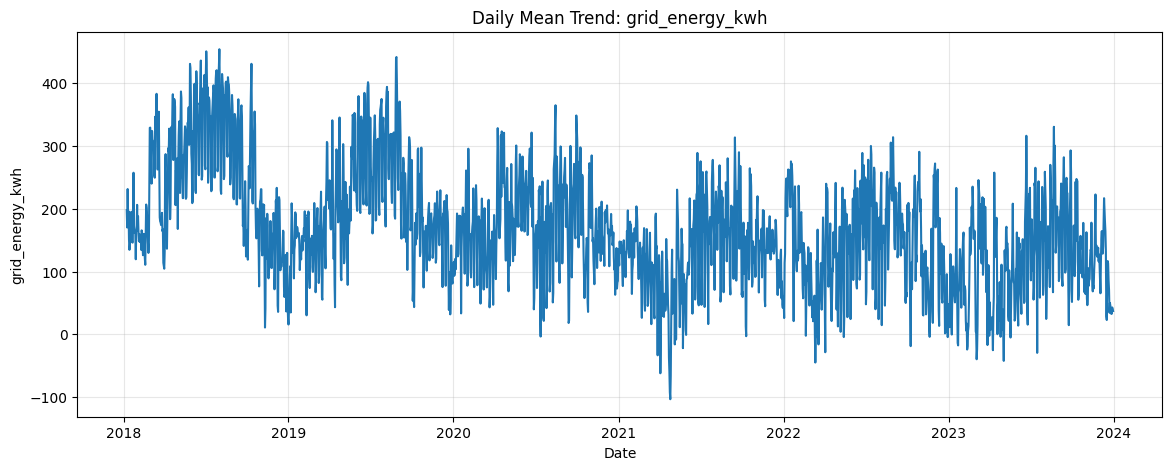

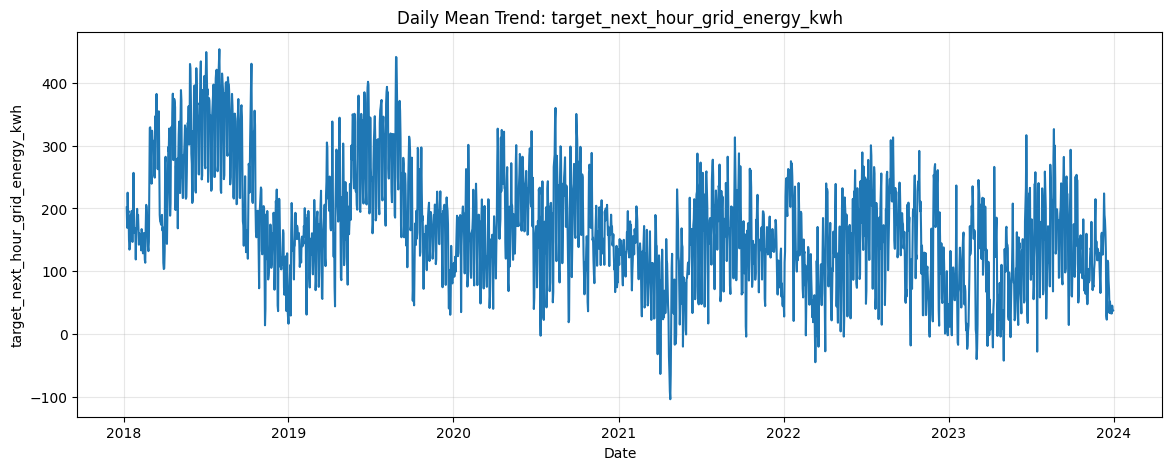

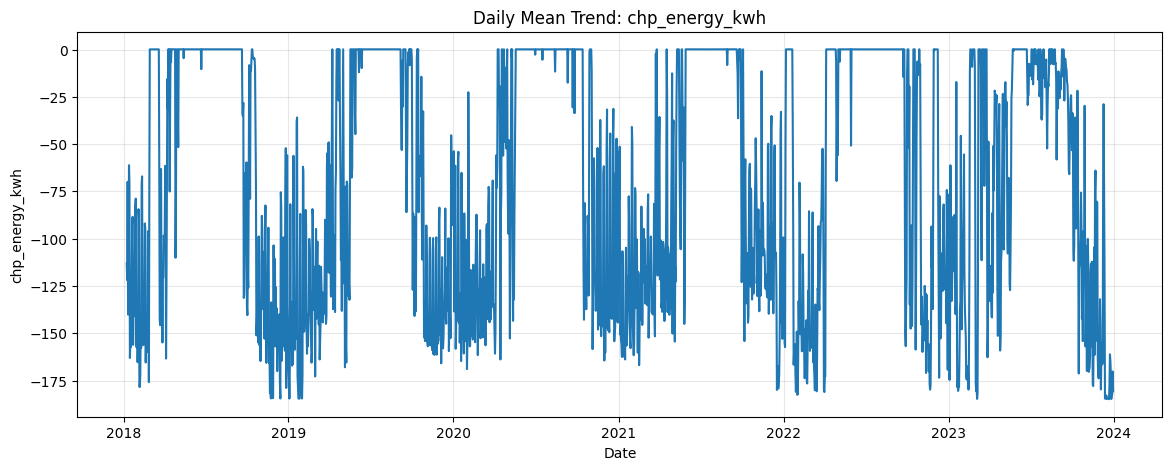

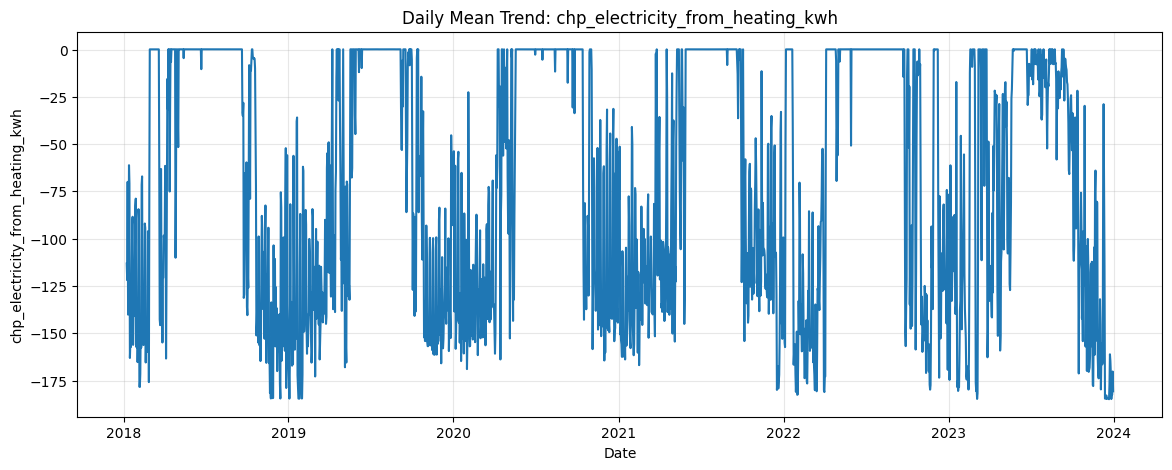

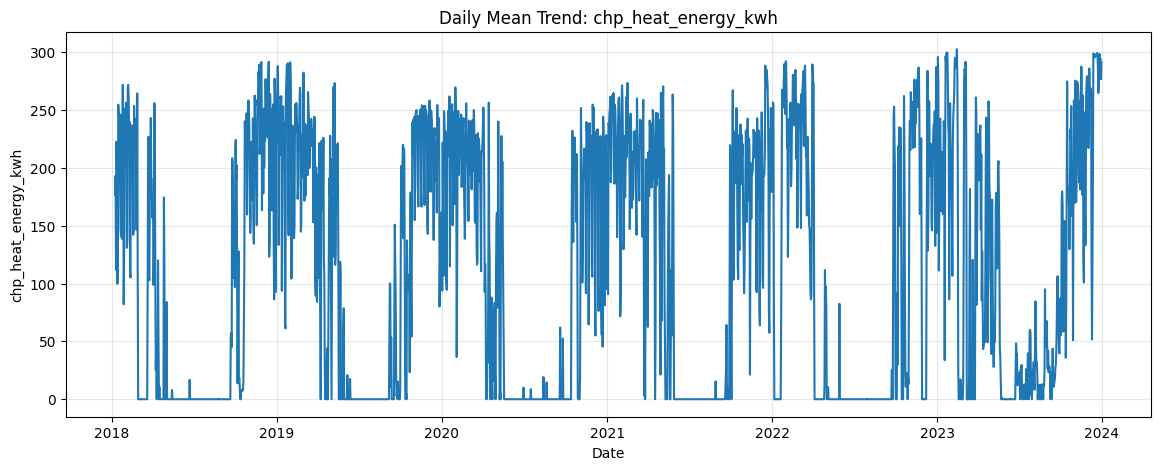

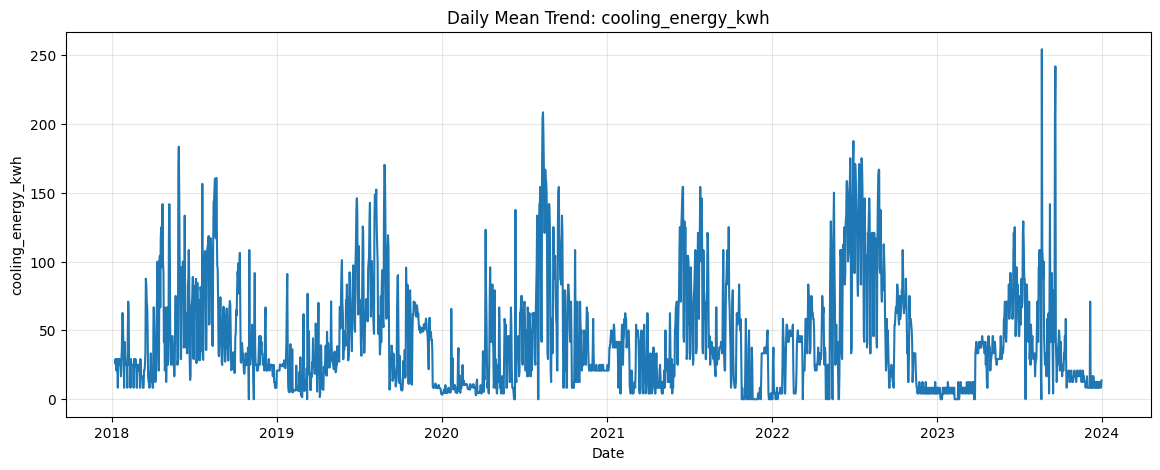

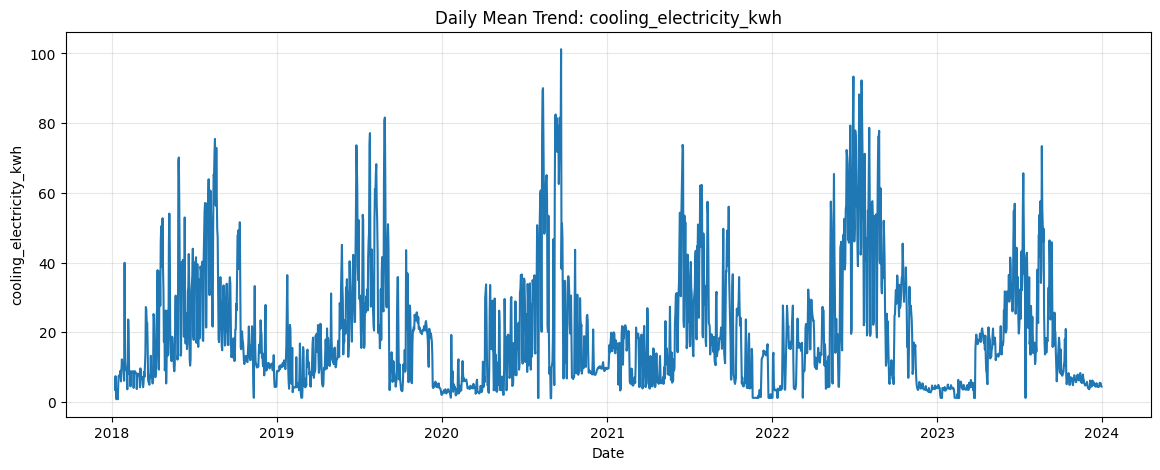

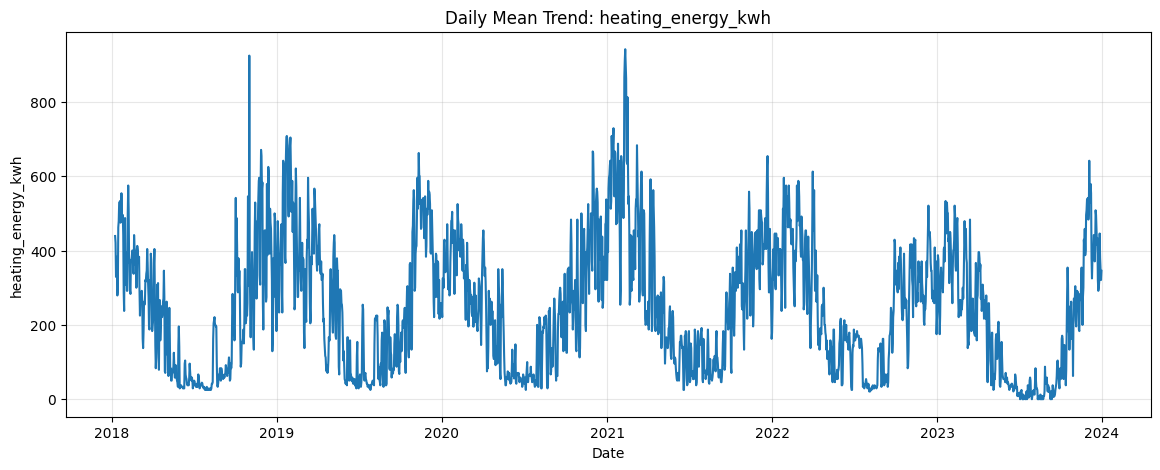

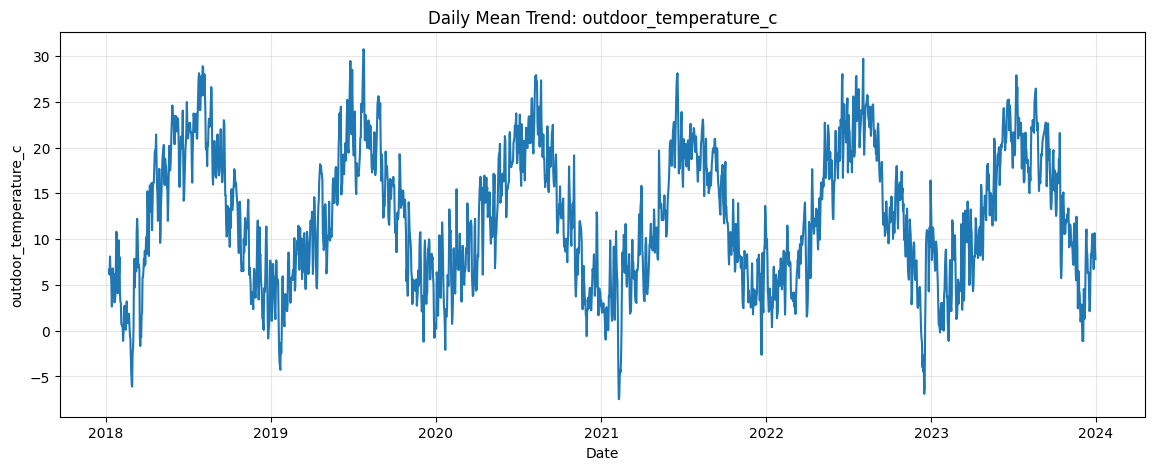

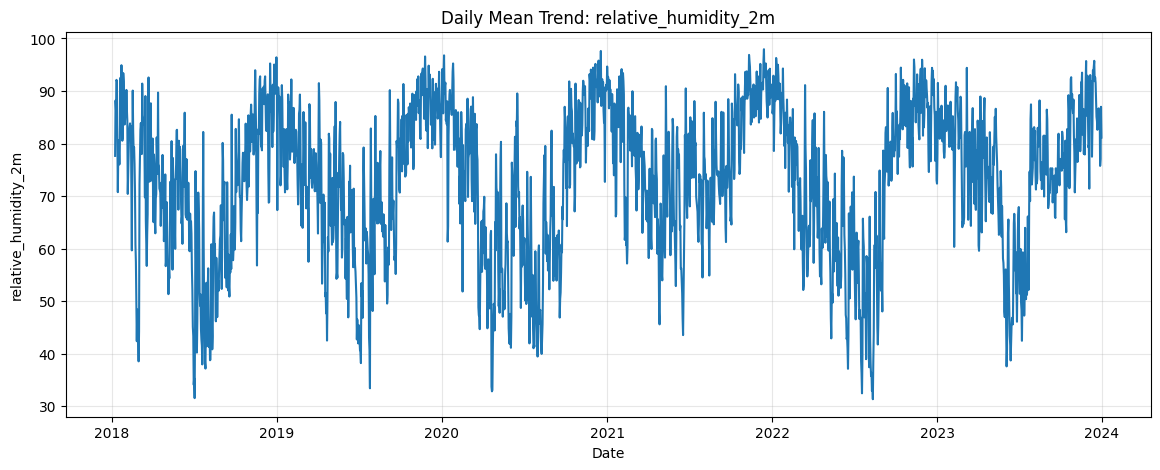

time: 1.7 s (started: 2026-05-31 13:29:25 +03:00)


In [77]:
plot_daily_trend(
    eda_df,
    columns=numeric_cols,
    save_dir=EDA_OUTPUT_DIR
)

## Distribution Block

In [78]:
def plot_histograms( df: pd.DataFrame, columns: Sequence[str], bins: int = 60, save_dir: Path | None = None ) -> None:
    """
    Plot one histogram per selected numeric column.
    """
    for col in columns:
        if col not in df.columns:
            continue

        values = df[col].dropna()

        plt.figure(figsize=(8, 5))
        plt.hist(values, bins=bins)
        plt.title(f"Distribution: {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.grid(True, alpha=0.3)

        if save_dir is not None:
            plt.savefig(save_dir / f"histogram_{col}.png", bbox_inches="tight", dpi=150)

        plt.show()

time: 0 ns (started: 2026-05-31 13:29:27 +03:00)


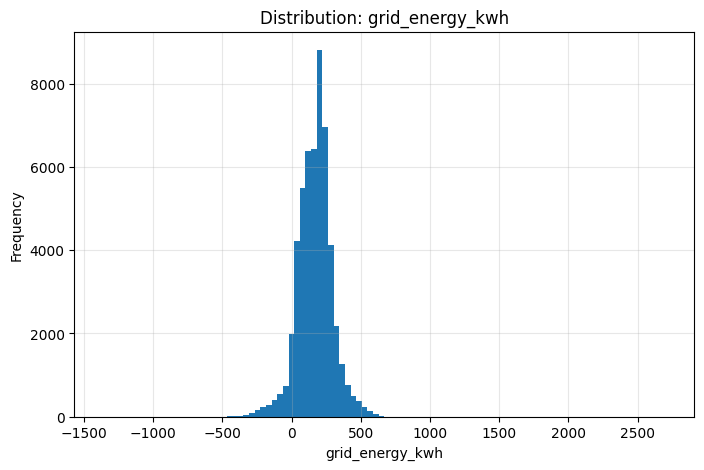

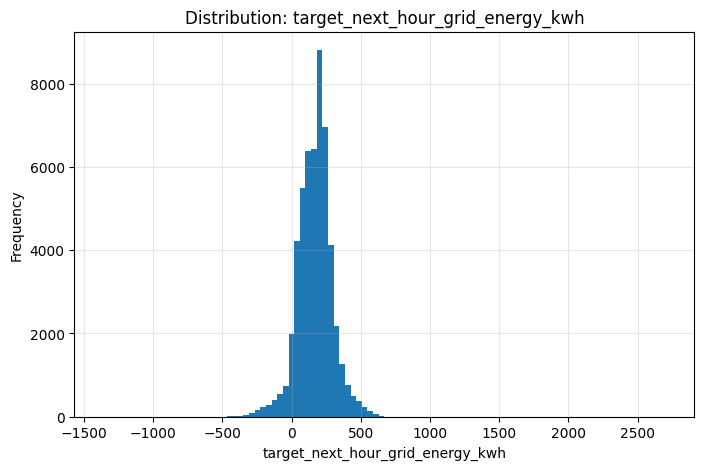

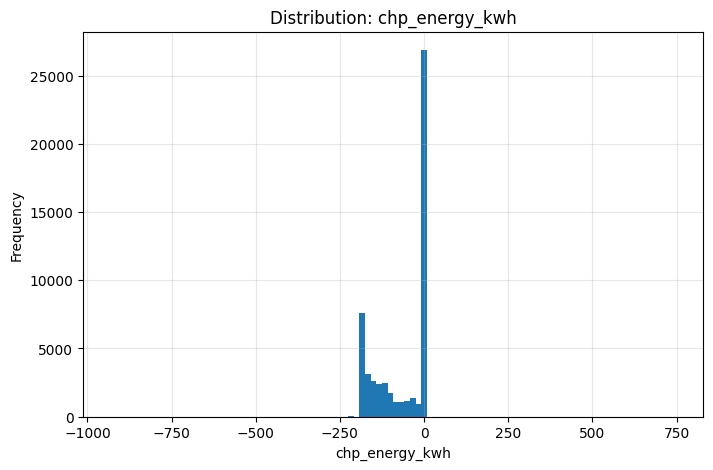

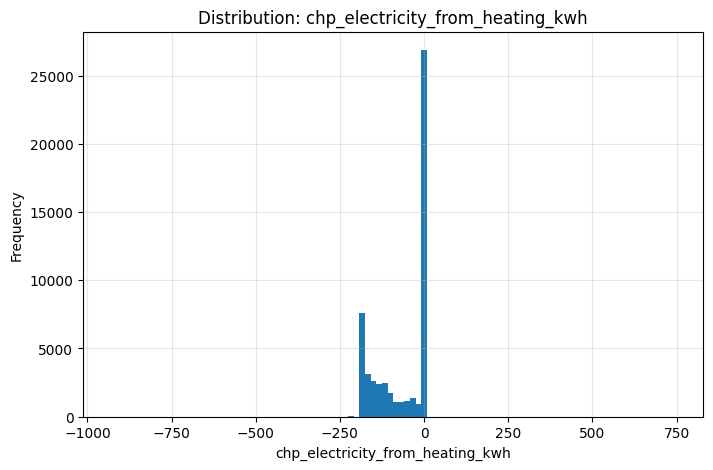

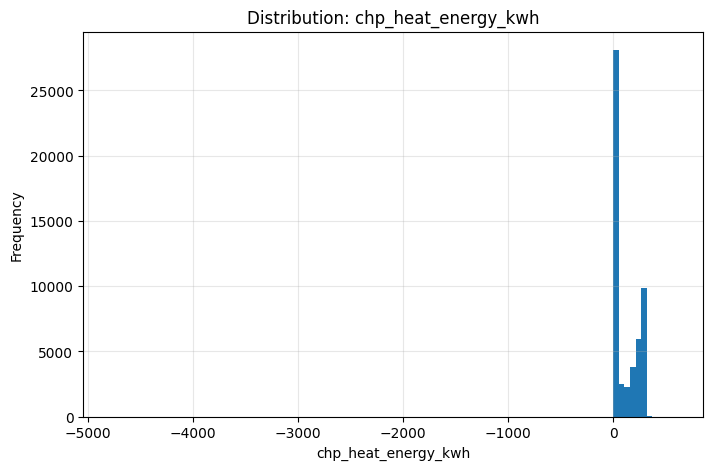

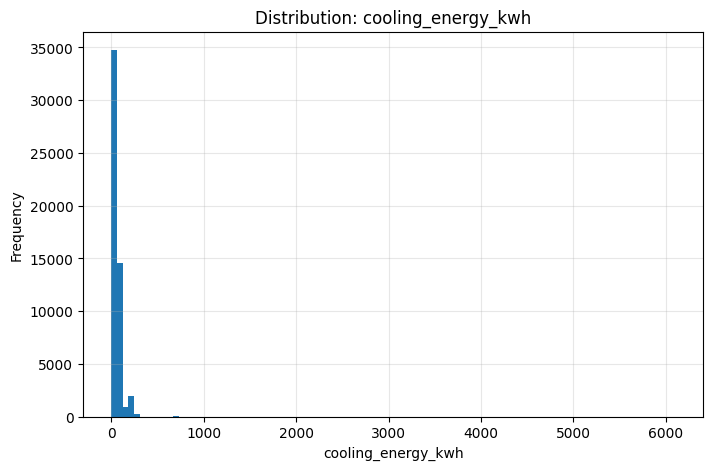

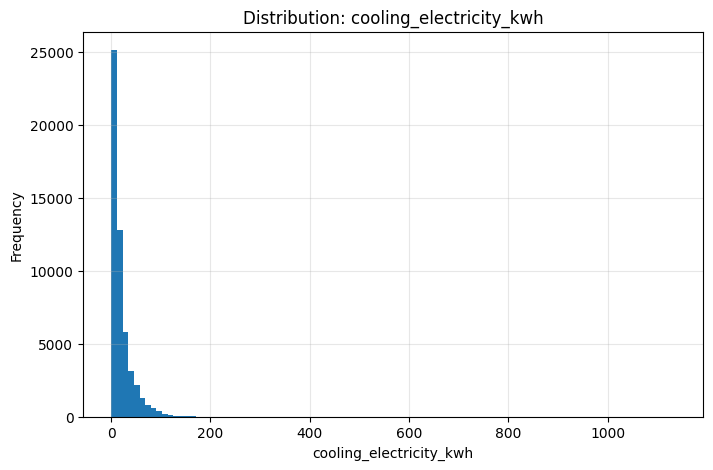

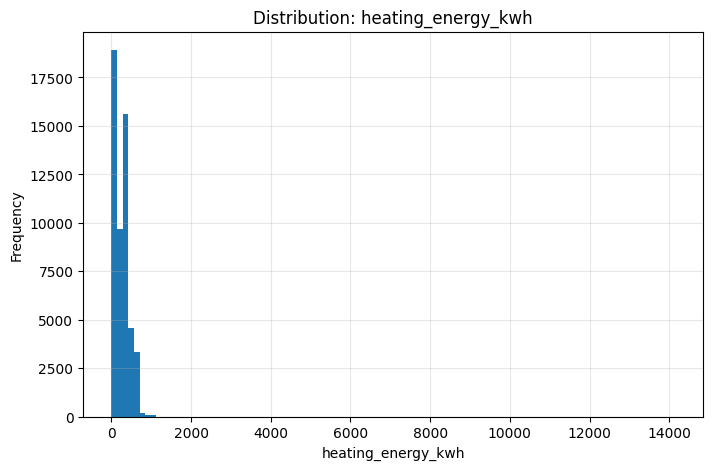

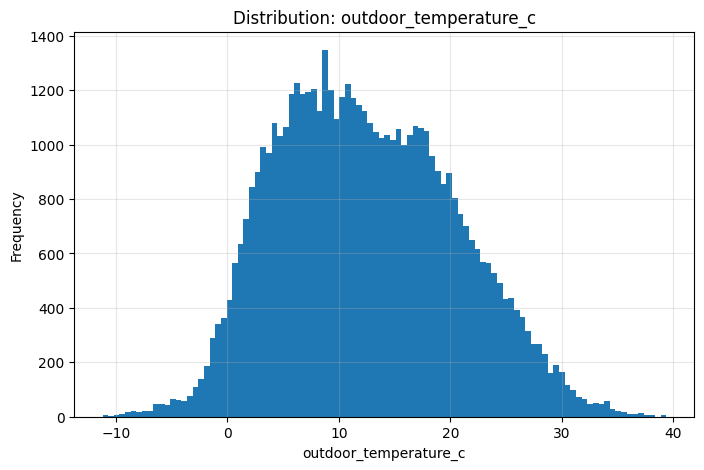

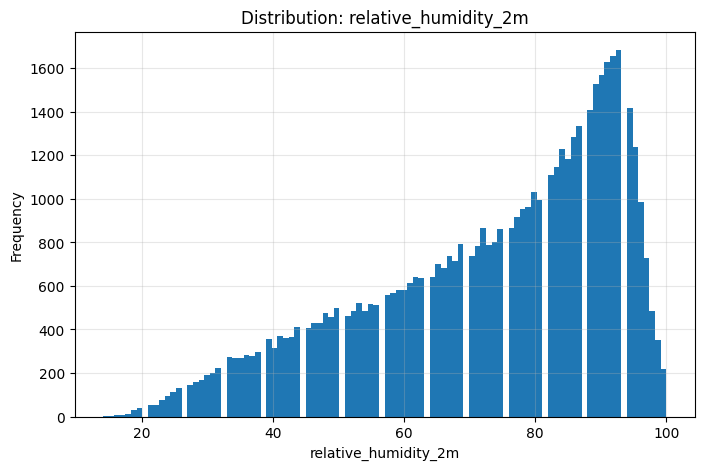

time: 1.47 s (started: 2026-05-31 13:29:27 +03:00)


In [79]:
plot_histograms(
    eda_df,
    columns=numeric_cols,
    bins=100,
    save_dir=EDA_OUTPUT_DIR
)

**Note**
----------------
- It was noticed that some of the variables have log-normal distribution which would require some further pre-processing

## BoxPlot for visualizing

In [80]:
def plot_boxplots( df: pd.DataFrame, columns: Sequence[str], save_dir: Path | None = None ) -> None:
    """
    Plot one boxplot per selected numeric column.
    """
    for col in columns:
        if col not in df.columns:
            continue

        values = df[col].dropna()

        plt.figure(figsize=(8, 4))
        plt.boxplot(values, vert=False)
        plt.title(f"Boxplot: {col}")
        plt.xlabel(col)
        plt.grid(True, alpha=0.3)

        if save_dir is not None:
            plt.savefig(save_dir / f"boxplot_{col}.png", bbox_inches="tight", dpi=150)

        plt.show()

time: 0 ns (started: 2026-05-31 13:29:28 +03:00)


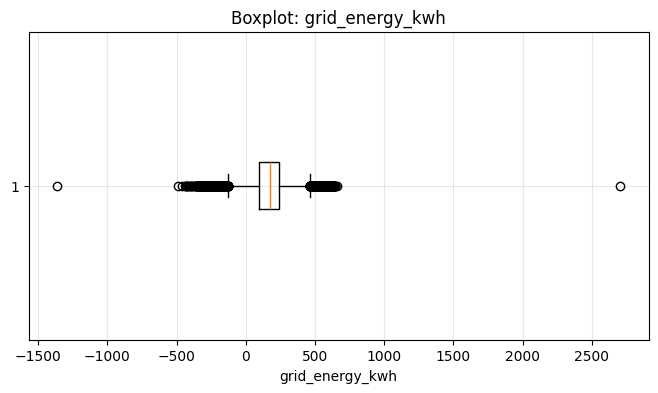

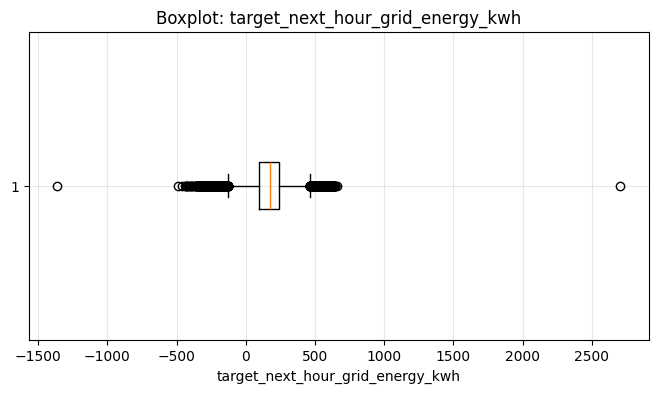

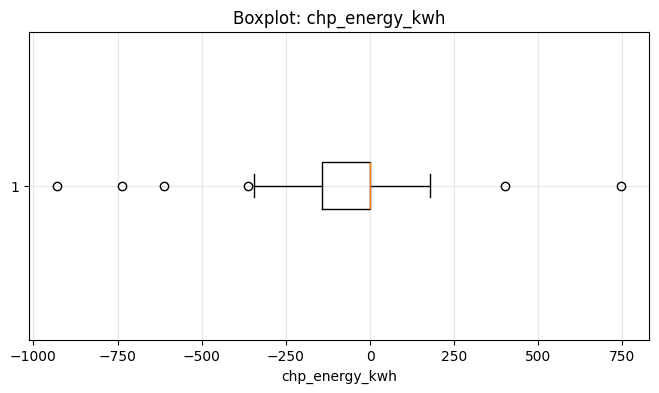

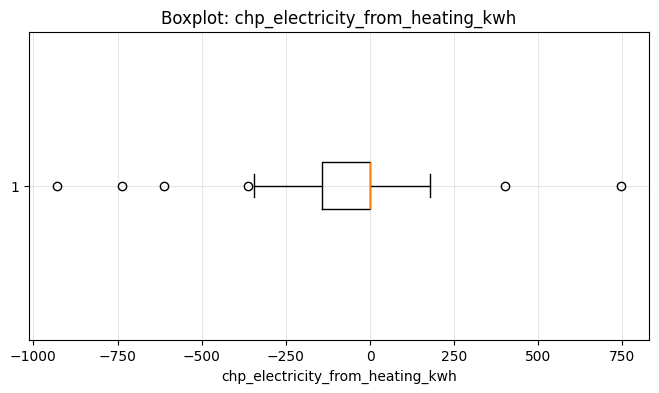

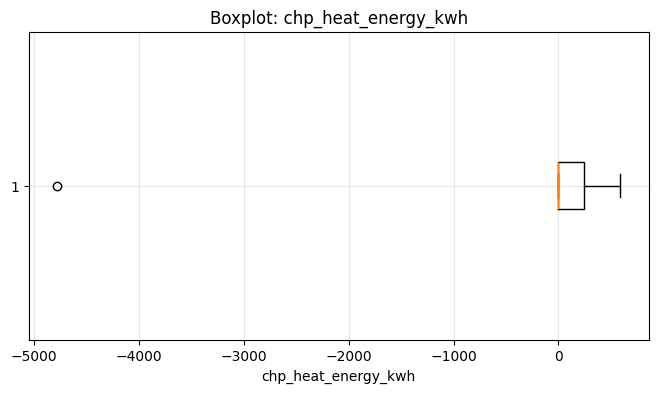

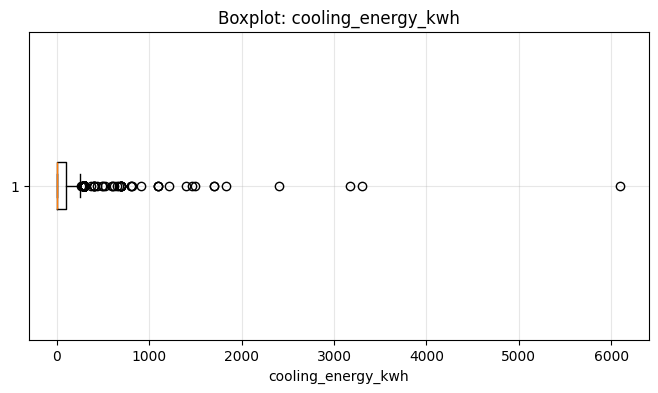

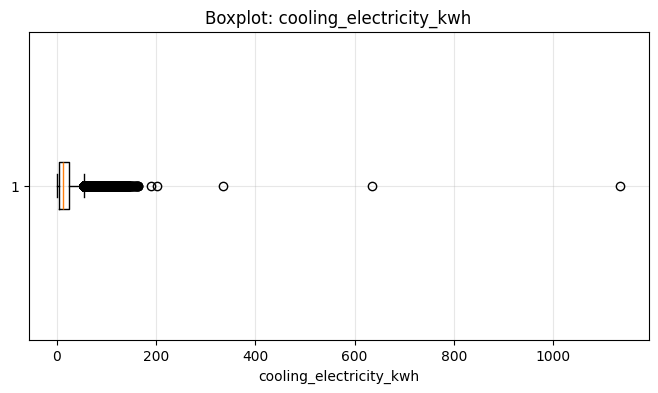

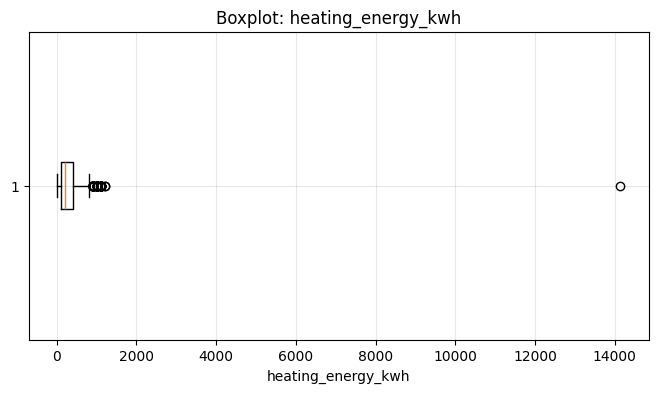

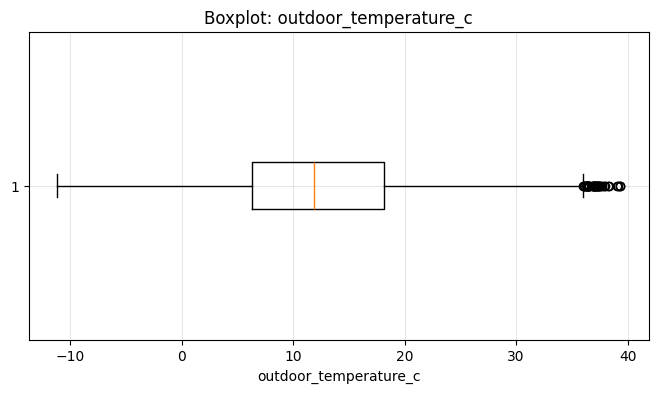

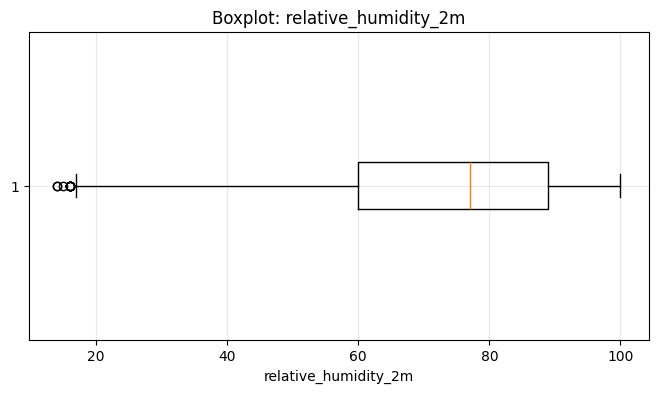

time: 609 ms (started: 2026-05-31 13:29:28 +03:00)


In [81]:
plot_boxplots(
    eda_df,
    columns=numeric_cols,
    save_dir=EDA_OUTPUT_DIR
)

## IQR Outlier Report

In [82]:
def iqr_outlier_report( df: pd.DataFrame, columns: Sequence[str], iqr_multiplier: float = 1.5 ) -> pd.DataFrame:
    """
    Detect outliers using the IQR rule for each selected column.
    """
    records = []

    for col in columns:
        if col not in df.columns:
            continue

        values = df[col].dropna()

        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - iqr_multiplier * iqr
        upper_bound = q3 + iqr_multiplier * iqr

        outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
        outlier_count = int(outlier_mask.sum())

        records.append({
            "column": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": outlier_count,
            "outlier_percentage": round(outlier_count / len(df) * 100, 3),
            "min": values.min(),
            "max": values.max()
        })

    return pd.DataFrame(records).sort_values(
        "outlier_percentage",
        ascending=False
    ).reset_index(drop=True)

time: 0 ns (started: 2026-05-31 13:29:29 +03:00)


In [83]:
outlier_report = iqr_outlier_report(eda_df, numeric_cols)
display(outlier_report)

,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percentage,min,max
0,cooling_electricity_kwh,5.180833,25.115037,19.934203,-24.720472,55.016342,3788,7.227000,0.365854,1135.180227
1,grid_energy_kwh,92.995067,241.880533,148.885467,-130.333133,465.208733,1767,3.371000,-1365.217628,2706.552573
2,target_next_hour_grid_energy_kwh,92.995067,241.880533,148.885467,-130.333133,465.208733,1767,3.371000,-1365.217628,2706.552573
3,cooling_energy_kwh,0.000000,100.000000,100.000000,-150.000000,250.000000,235,0.448000,0.000000,6100.000000
4,heating_energy_kwh,100.000000,400.000000,300.000000,-350.000000,850.000000,123,0.235000,0.000000,14144.354780
5,outdoor_temperature_c,6.280174,18.150459,11.870285,-11.525254,35.955887,43,0.082000,-11.200232,39.349571
6,relative_humidity_2m,60.000000,89.000000,29.000000,16.500000,132.500000,10,0.019000,14.000000,100.000000
7,chp_energy_kwh,-143.640000,0.089998,143.729998,-359.234997,215.684994,6,0.011000,-928.978817,745.340442
8,chp_electricity_from_heating_kwh,-143.640000,0.089998,143.729998,-359.234997,215.684994,6,0.011000,-928.978817,745.340442
9,chp_heat_energy_kwh,0.000000,240.000000,240.000000,-360.000000,600.000000,1,0.002000,-4780.000000,590.000000


time: 15 ms (started: 2026-05-31 13:29:29 +03:00)


## Correlation between variables

In [84]:
def plot_correlation_heatmap( df: pd.DataFrame, columns: Sequence[str], save_dir: Path | None = None, figsize: tuple[int, int] = (12, 10), annot_fontsize: int = 9 ) -> pd.DataFrame:
    """
    Plot a correlation heatmap using matplotlib with:
    - dark blue for negative correlations
    - white near zero
    - red for positive correlations
    - borders around each cell
    - numeric annotation inside each cell
    """
    selected_columns = [col for col in columns if col in df.columns]

    if not selected_columns:
        raise ValueError("No valid columns were provided for the heatmap.")

    corr = df[selected_columns].corr(numeric_only=True)

    # Custom unified color map: dark blue -> white -> red
    cmap = LinearSegmentedColormap.from_list(
        "blue_white_red",
        ["darkblue", "white", "red"]
    )

    fig, ax = plt.subplots(figsize=figsize)

    image = ax.imshow(
        corr.values,
        cmap=cmap,
        vmin=-1,
        vmax=1,
        aspect="auto"
    )

    cbar = plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Correlation", rotation=90)

    ax.set_xticks(np.arange(len(corr.columns)))
    ax.set_yticks(np.arange(len(corr.index)))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticklabels(corr.index)

    ax.set_title("Correlation Heatmap")

    # Add visible borders around each box
    ax.set_xticks(np.arange(-0.5, len(corr.columns), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(corr.index), 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=0.8)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Add values inside each cell
    for i in range(len(corr.index)):
        for j in range(len(corr.columns)):
            value = corr.iloc[i, j]

            # Better contrast for text
            text_color = "white" if abs(value) >= 0.5 else "black"

            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                color=text_color,
                fontsize=annot_fontsize
            )

    plt.tight_layout()

    if save_dir is not None:
        save_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_dir / "correlation_heatmap.png", bbox_inches="tight", dpi=150)

    plt.show()

    return corr


time: 0 ns (started: 2026-05-31 13:29:29 +03:00)


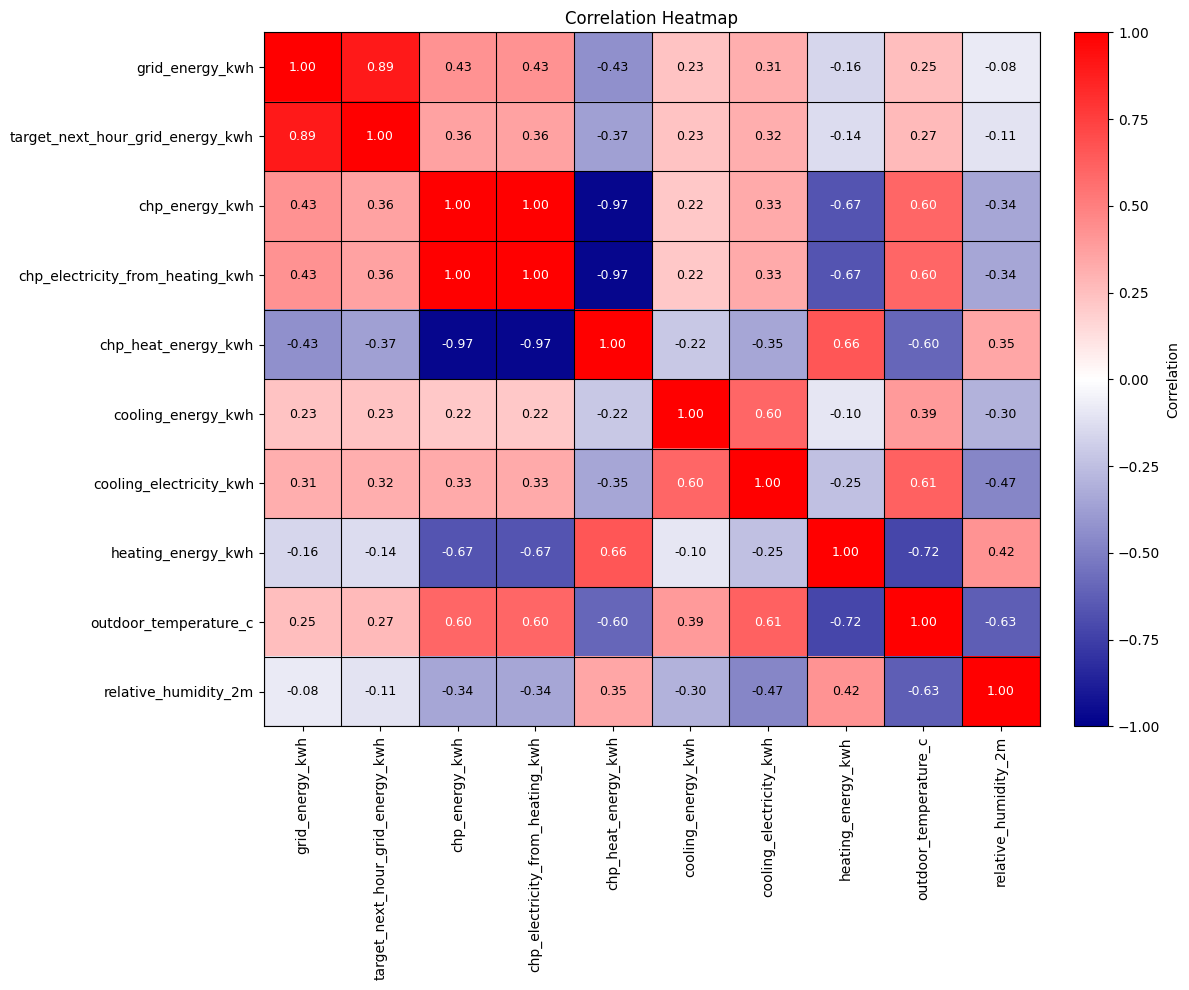

,grid_energy_kwh,target_next_hour_grid_energy_kwh,chp_energy_kwh,chp_electricity_from_heating_kwh,chp_heat_energy_kwh,cooling_energy_kwh,cooling_electricity_kwh,heating_energy_kwh,outdoor_temperature_c,relative_humidity_2m
grid_energy_kwh,1.000000,0.890711,0.426197,0.426197,-0.430868,0.232381,0.313667,-0.158493,0.254962,-0.082385
target_next_hour_grid_energy_kwh,0.890711,1.000000,0.362913,0.362913,-0.368344,0.234313,0.317393,-0.137279,0.268335,-0.105836
chp_energy_kwh,0.426197,0.362913,1.000000,1.000000,-0.974137,0.216518,0.333459,-0.667466,0.600195,-0.344260
chp_electricity_from_heating_kwh,0.426197,0.362913,1.000000,1.000000,-0.974137,0.216518,0.333459,-0.667466,0.600195,-0.344260
chp_heat_energy_kwh,-0.430868,-0.368344,-0.974137,-0.974137,1.000000,-0.216655,-0.345245,0.660923,-0.598952,0.346661
cooling_energy_kwh,0.232381,0.234313,0.216518,0.216518,-0.216655,1.000000,0.601350,-0.098139,0.393900,-0.304512
cooling_electricity_kwh,0.313667,0.317393,0.333459,0.333459,-0.345245,0.601350,1.000000,-0.249790,0.614014,-0.474838
heating_energy_kwh,-0.158493,-0.137279,-0.667466,-0.667466,0.660923,-0.098139,-0.249790,1.000000,-0.719097,0.418399
outdoor_temperature_c,0.254962,0.268335,0.600195,0.600195,-0.598952,0.393900,0.614014,-0.719097,1.000000,-0.626791
relative_humidity_2m,-0.082385,-0.105836,-0.344260,-0.344260,0.346661,-0.304512,-0.474838,0.418399,-0.626791,1.000000


time: 422 ms (started: 2026-05-31 13:29:29 +03:00)


In [85]:
correlation_matrix = plot_correlation_heatmap(
    eda_df,
    columns=numeric_cols,
    save_dir=EDA_OUTPUT_DIR
)

display(correlation_matrix)

# Feature Selection (Filter method)

- After seeing the correlation matrix, both chp_electricity_from_heating_kwh, and chp_heat_energy_kwh have very strong correlation with chp_energy_kwh, which introduce noise and extra dimensionality to the model, so they were removed

In [86]:
redundant_chp_columns = [
    "chp_electricity_from_heating_kwh",
    "chp_heat_energy_kwh"
]

existing_redundant_chp_columns = [
    col for col in redundant_chp_columns
    if col in model_df_features_clean.columns
]

model_df_features_clean = model_df_features_clean.drop(
    columns=existing_redundant_chp_columns,
    errors="ignore"
)

print("Dropped redundant CHP columns:")
print(existing_redundant_chp_columns)

print("Remaining CHP-related columns:")
print([col for col in model_df_features_clean.columns if "chp" in col.lower()])

Dropped redundant CHP columns:
['chp_electricity_from_heating_kwh', 'chp_heat_energy_kwh']
Remaining CHP-related columns:
['chp_energy_kwh']
time: 15 ms (started: 2026-05-31 13:29:29 +03:00)


# Spliting Data for ML models

## Split the Data into Target (y) , and variables (X) Function

In [87]:
def create_feature_target_split( df: pd.DataFrame, target_col: str, datetime_col: str = DATETIME_COL, drop_extra_columns: List[str] | None = None ) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Create feature matrix X and target vector y.

    Drops datetime and target column from X.
    """
    df = df.copy()

    if target_col not in df.columns:
        raise ValueError(f"Target column not found: {target_col}")

    drop_columns = [datetime_col, target_col]

    if drop_extra_columns:
        drop_columns.extend(drop_extra_columns)

    existing_drop_columns = [col for col in drop_columns if col in df.columns]

    X = df.drop(columns=existing_drop_columns)
    y = df[target_col]

    print("Feature matrix shape:", X.shape)
    print("Target vector shape:", y.shape)
    print("Number of features:", X.shape[1])

    return X, y

time: 0 ns (started: 2026-05-31 13:29:29 +03:00)


## Before Splitting, we will remove weather and irradiance for now (before we impute them)

In [88]:
# Only do it if they are still available in code
# model_df_features_clean = model_df_features_clean.drop(columns=['solar_irradiance_w_m2', 'outdoor_temperature_c'], errors="ignore")

time: 0 ns (started: 2026-05-31 13:29:29 +03:00)


## Checking if the split works

In [89]:
X, y = create_feature_target_split(
    model_df_features_clean,
    target_col=target_col
)

display(X.head(3))
display(y.head(3))

Feature matrix shape: (52413, 21)
Target vector shape: (52413,)
Number of features: 21


,grid_energy_kwh,chp_energy_kwh,cooling_energy_kwh,cooling_electricity_kwh,heating_energy_kwh,outdoor_temperature_c,relative_humidity_2m,is_weekend,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,grid_energy_kwh_lag_1h,grid_energy_kwh_lag_24h,grid_energy_kwh_lag_168h,grid_energy_kwh_rolling_mean_24h,grid_energy_kwh_rolling_mean_168h,grid_energy_kwh_rolling_std_24h,grid_energy_kwh_rolling_std_168h
0,86.588667,-120.300000,0.000000,0.815000,400.000000,5.534571,77,0,0.500000,0.866025,0.000000,1.000000,0.500000,0.866025,121.485867,152.313200,74.667256,137.813178,131.922473,23.938648,101.755392
1,169.854400,-36.490000,0.000000,0.814167,300.000000,5.795861,77,0,0.707107,0.707107,0.000000,1.000000,0.500000,0.866025,86.588667,164.051600,2.521144,138.054961,132.918504,24.242557,101.299110
2,121.423333,-85.930000,0.000000,0.817500,300.000000,5.793383,77,0,0.866025,0.500000,0.000000,1.000000,0.500000,0.866025,169.854400,122.608133,48.046771,138.005594,133.355269,24.276562,101.088951


0   169.854400
1   121.423333
2    84.166267
Name: target_next_hour_grid_energy_kwh, dtype: float64

time: 0 ns (started: 2026-05-31 13:29:29 +03:00)


## Train-Test Split The Data

In [90]:
def chronological_percentage_train_test_split( df: pd.DataFrame, target_col: str, train_size: float = 80, datetime_col: str = DATETIME_COL ) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """
    Split time-series data chronologically by percentage.

    Example:
    train_size=80 means:
        first 80% of data -> train
        last 20% of data  -> test

    train_size can be:
        80 for 80%
        0.8 for 80%
    """
    df = df.copy()
    df = df.sort_values(datetime_col).reset_index(drop=True)

    if target_col not in df.columns:
        raise ValueError(f"Target column not found: {target_col}")

    if datetime_col not in df.columns:
        raise ValueError(f"Datetime column not found: {datetime_col}")

    # Allow user to enter either 80 or 0.8
    if train_size > 1:
        train_fraction = train_size / 100
    else:
        train_fraction = train_size

    if not 0 < train_fraction < 1:
        raise ValueError("train_size must be between 0 and 100, or between 0 and 1.")

    split_index = int(len(df) * train_fraction)

    train_df = df.iloc[:split_index].copy()
    test_df = df.iloc[split_index:].copy()

    if train_df.empty:
        raise ValueError("Training set is empty. Increase train_size.")

    if test_df.empty:
        raise ValueError("Test set is empty. Decrease train_size.")

    X_train, y_train = create_feature_target_split(
        train_df,
        target_col=target_col,
        datetime_col=datetime_col
    )

    X_test, y_test = create_feature_target_split(
        test_df,
        target_col=target_col,
        datetime_col=datetime_col
    )

    print("Chronological split completed.")
    print(f"Train size: {len(train_df)} rows ({train_fraction * 100:.1f}%)")
    print(f"Test size: {len(test_df)} rows ({(1 - train_fraction) * 100:.1f}%)")

    print("\nTrain period:")
    print(train_df[datetime_col].min(), "to", train_df[datetime_col].max())

    print("\nTest period:")
    print(test_df[datetime_col].min(), "to", test_df[datetime_col].max())

    return X_train, X_test, y_train, y_test

time: 0 ns (started: 2026-05-31 13:29:29 +03:00)


In [91]:
target_col = PROJECT_FEATURE_POLICY["target_column"]

X_train, X_test, y_train, y_test = chronological_percentage_train_test_split(
    df=model_df_features_clean,
    target_col=target_col,
    train_size=80
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Feature matrix shape: (41930, 21)
Target vector shape: (41930,)
Number of features: 21
Feature matrix shape: (10483, 21)
Target vector shape: (10483,)
Number of features: 21
Chronological split completed.
Train size: 41930 rows (80.0%)
Test size: 10483 rows (20.0%)

Train period:
2018-01-08 01:00:00+00:00 to 2022-10-21 02:00:00+00:00

Test period:
2022-10-21 03:00:00+00:00 to 2023-12-31 21:00:00+00:00
X_train: (41930, 21)
X_test: (10483, 21)
y_train: (41930,)
y_test: (10483,)
time: 0 ns (started: 2026-05-31 13:29:29 +03:00)


## Model Evaluation Function

In [92]:
def evaluate_regression(y_true, y_pred, model_name):
    errors = np.abs(np.asarray(y_true) - np.asarray(y_pred))

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    median_ae = np.median(errors)
    p95_ae = np.percentile(errors, 95)
    p99_ae = np.percentile(errors, 99)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MedianAE": median_ae,
        "P95AE": p95_ae,
        "P99AE": p99_ae
    }

time: 0 ns (started: 2026-05-31 13:29:29 +03:00)


# Functions to save/Load models

## Save Model Function

In [93]:
def make_safe_model_name(model_name: str) -> str:
    """
    Convert model names into safe filename prefixes.
    """
    return (
        model_name
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
    )

time: 0 ns (started: 2026-05-31 13:29:29 +03:00)


## Load Model Functions

In [94]:
def get_feature_signature(feature_columns: list[str]) -> str:
    """
    Create a stable short signature from the exact feature column order.
    This helps detect whether a saved model matches the current feature set.
    """
    joined_features = "||".join(feature_columns)
    return hashlib.md5(joined_features.encode("utf-8")).hexdigest()[:12]

time: 0 ns (started: 2026-05-31 13:29:30 +03:00)


In [95]:
def save_model_artifact(
    model,
    model_name: str,
    feature_columns: list[str],
    target_col: str,
    metrics: dict,
    best_params: dict | None = None,
    scaler=None,
    search_results_df: pd.DataFrame | None = None,
    output_dir: Path = MODEL_OUTPUT_DIR,
    experiment_name: str = "sin_cos_hour"
) -> Path:
    """
    Save a trained model and metadata needed to reuse it later.
    """

    output_dir.mkdir(parents=True, exist_ok=True)

    safe_model_name = make_safe_model_name(model_name)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    feature_signature = get_feature_signature(list(feature_columns))

    artifact = {
        "model_name": model_name,
        "experiment_name": experiment_name,
        "created_at": timestamp,
        "model": model,
        "scaler": scaler,
        "feature_columns": list(feature_columns),
        "feature_signature": feature_signature,
        "target_col": target_col,
        "metrics": metrics,
        "best_params": best_params
    }

    model_path = output_dir / f"{safe_model_name}_{experiment_name}_{feature_signature}_{timestamp}.joblib"
    joblib.dump(artifact, model_path)

    print(f"Saved model artifact to: {model_path}")

    if search_results_df is not None:
        search_path = RESULTS_OUTPUT_DIR / f"{safe_model_name}_{experiment_name}_search_results_{timestamp}.csv"
        search_results_df.to_csv(search_path, index=False)
        print(f"Saved search results to: {search_path}")

    return model_path


time: 16 ms (started: 2026-05-31 13:29:30 +03:00)


In [96]:
def list_model_artifact_paths(
    model_name: str,
    model_dir: Path = MODEL_OUTPUT_DIR
) -> list[Path]:
    """
    Return all saved artifacts whose filenames start with the safe model name.
    Sorted from newest to oldest by file modified time.
    """
    safe_model_name = make_safe_model_name(model_name)

    artifact_paths = sorted(
        model_dir.glob(f"{safe_model_name}_*.joblib"),
        key=lambda path: path.stat().st_mtime,
        reverse=True
    )

    return artifact_paths

time: 0 ns (started: 2026-05-31 13:29:30 +03:00)


In [97]:
def artifact_features_match(
    artifact: dict,
    X: pd.DataFrame
) -> bool:
    """
    Exact feature-order check.
    """
    saved_features = artifact.get("feature_columns", [])
    current_features = X.columns.tolist()

    return saved_features == current_features

time: 0 ns (started: 2026-05-31 13:29:30 +03:00)


In [98]:
def explain_feature_mismatch(
    artifact: dict,
    X: pd.DataFrame
) -> None:
    """
    Print exactly why a saved model does not match current X.
    """
    saved_features = artifact.get("feature_columns", [])
    current_features = X.columns.tolist()

    missing_from_current = [
        col for col in saved_features
        if col not in current_features
    ]

    extra_in_current = [
        col for col in current_features
        if col not in saved_features
    ]

    common_features_different_order = (
        set(saved_features) == set(current_features)
        and saved_features != current_features
    )

    print("Saved model features do not match current notebook features.")
    print("Saved feature count:", len(saved_features))
    print("Current feature count:", len(current_features))
    print("Missing from current X:")
    print(missing_from_current)
    print("Extra in current X:")
    print(extra_in_current)

    if common_features_different_order:
        print("Same feature names exist, but the column order is different.")

time: 0 ns (started: 2026-05-31 13:29:30 +03:00)


In [99]:
def load_best_compatible_model_artifact(
    model_name: str,
    X: pd.DataFrame,
    model_dir: Path = MODEL_OUTPUT_DIR,
    experiment_name: str | None = None,
    strict_model_name: bool = True,
    verbose: bool = True
) -> dict | None:
    """
    Load the newest saved artifact that matches:
    - model name
    - optional experiment name
    - current feature columns exactly

    Important:
    This does NOT stop at the newest incompatible model.
    It checks all candidates until it finds a compatible one.
    """

    artifact_paths = list_model_artifact_paths(
        model_name=model_name,
        model_dir=model_dir
    )

    if verbose:
        print(f"Looking for saved artifacts for: {model_name}")
        print(f"Model directory: {model_dir.resolve()}")
        print(f"Candidate files found: {len(artifact_paths)}")

    if not artifact_paths:
        return None

    incompatible_count = 0

    for path in artifact_paths:
        try:
            artifact = joblib.load(path)
        except Exception as error:
            print(f"Could not load artifact: {path}")
            print(error)
            continue

        saved_model_name = artifact.get("model_name")

        if strict_model_name and saved_model_name != model_name:
            continue

        if experiment_name is not None:
            saved_experiment_name = artifact.get("experiment_name")

            if saved_experiment_name != experiment_name:
                incompatible_count += 1

                if verbose:
                    print(f"Skipping {path.name}: experiment mismatch.")
                    print("Saved experiment:", saved_experiment_name)
                    print("Current experiment:", experiment_name)

                continue

        if artifact_features_match(artifact, X):
            if verbose:
                print("Compatible saved model found.")
                print("Path:", path)
                print("Created at:", artifact.get("created_at"))
                print("Experiment:", artifact.get("experiment_name"))
                print("Feature signature:", artifact.get("feature_signature"))
                print("Metrics:", artifact.get("metrics"))
                print("Best params:", artifact.get("best_params"))

            artifact["artifact_path"] = path
            return artifact

        incompatible_count += 1

        if verbose:
            print(f"Skipping incompatible artifact: {path.name}")
            explain_feature_mismatch(artifact, X)

    if verbose:
        print(f"No compatible saved artifact found for: {model_name}")
        print(f"Incompatible candidates checked: {incompatible_count}")

    return None

time: 16 ms (started: 2026-05-31 13:29:30 +03:00)


In [100]:
def should_use_saved_model(
    model_name: str,
    X: pd.DataFrame,
    use_saved_models: bool = True,
    retrain_if_features_changed: bool = False,
    experiment_name: str | None = None
) -> dict | None:
    """
    Try to load the newest compatible saved model.

    If saved model loading is disabled, return None.
    If no compatible model exists:
      - return None if retraining is allowed
      - raise an error if retraining is disabled and candidate files exist
    """

    if not use_saved_models:
        print(f"Saved model loading disabled for: {model_name}")
        return None

    artifact = load_best_compatible_model_artifact(
        model_name=model_name,
        X=X,
        model_dir=MODEL_OUTPUT_DIR,
        experiment_name=experiment_name,
        strict_model_name=True,
        verbose=True
    )

    if artifact is not None:
        print(f"Feature check passed. Saved {model_name} can be used.")
        return artifact

    candidate_paths = list_model_artifact_paths(model_name, MODEL_OUTPUT_DIR)

    if candidate_paths and not retrain_if_features_changed:
        raise RuntimeError(
            f"Saved artifacts exist for '{model_name}', but none match the current feature set. "
            f"Retraining is disabled because RETRAIN_IF_FEATURES_CHANGED=False. "
            f"Either restore the same feature pipeline, set RETRAIN_IF_FEATURES_CHANGED=True, "
            f"or check MODEL_OUTPUT_DIR."
        )

    print(f"No compatible saved model found for {model_name}. Model will be trained.")
    return None


time: 0 ns (started: 2026-05-31 13:29:30 +03:00)


In [101]:
def diagnose_saved_model_candidates(
    model_name: str,
    X: pd.DataFrame,
    model_dir: Path = MODEL_OUTPUT_DIR
) -> pd.DataFrame:
    """
    Show all saved candidate artifacts and whether they match the current features.
    Use this when a model does not load and you want to know why.
    """
    rows = []

    for path in list_model_artifact_paths(model_name, model_dir):
        try:
            artifact = joblib.load(path)

            saved_features = artifact.get("feature_columns", [])
            current_features = X.columns.tolist()

            rows.append({
                "file": path.name,
                "path": str(path),
                "model_name": artifact.get("model_name"),
                "experiment_name": artifact.get("experiment_name"),
                "created_at": artifact.get("created_at"),
                "feature_count_saved": len(saved_features),
                "feature_count_current": len(current_features),
                "features_match": saved_features == current_features,
                "feature_signature": artifact.get("feature_signature"),
                "best_params": artifact.get("best_params")
            })

        except Exception as error:
            rows.append({
                "file": path.name,
                "path": str(path),
                "error": str(error)
            })

    return pd.DataFrame(rows)

time: 0 ns (started: 2026-05-31 13:29:30 +03:00)


## Predict with Loaded model function

In [102]:
def predict_with_artifact( artifact: dict, X: pd.DataFrame ):
    """
    Predict using a saved artifact.
    Handles scaler automatically if it exists.
    """
    feature_columns = artifact["feature_columns"]
    model = artifact["model"]
    scaler = artifact.get("scaler")

    X_for_model = X[feature_columns]

    if scaler is not None:
        X_for_model = scaler.transform(X_for_model)

    predictions = model.predict(X_for_model)

    return predictions

time: 0 ns (started: 2026-05-31 13:29:30 +03:00)


# Training ML Models

## Helper Functions

### TreeSHAP Function

In [103]:
def compute_tree_feature_importance(
    model,
    X: pd.DataFrame
) -> pd.DataFrame:
    """
    Compute default tree-model feature importance.
    Works for RandomForestRegressor and XGBRegressor.
    """
    if not hasattr(model, "feature_importances_"):
        raise ValueError("This model does not have feature_importances_.")

    importance_df = pd.DataFrame({
        "feature": X.columns,
        "importance": model.feature_importances_
    })

    importance_df = importance_df.sort_values(
        "importance",
        ascending=False
    ).reset_index(drop=True)

    return importance_df

time: 0 ns (started: 2026-05-31 13:29:30 +03:00)


In [104]:
def plot_top_feature_importance(
    importance_df: pd.DataFrame,
    title: str,
    importance_col: str = "importance",
    top_n: int = 15
) -> None:
    """
    Plot top feature importances as a horizontal bar chart.
    """
    top_df = importance_df.head(top_n)

    plt.figure(figsize=(10, 6))

    plt.barh(
        top_df["feature"][::-1],
        top_df[importance_col][::-1]
    )

    plt.title(title)
    plt.xlabel(importance_col)
    plt.ylabel("Feature")
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


time: 0 ns (started: 2026-05-31 13:29:30 +03:00)


In [105]:
def compute_tree_shap_importance(
    model,
    X: pd.DataFrame,
    sample_size: int | None = 2000,
    random_state: int = 42
) -> tuple[pd.DataFrame, np.ndarray, pd.DataFrame]:
    """
    Compute TreeSHAP values for a tree-based model.

    Returns:
    - X_shap: sampled feature dataframe
    - shap_values: SHAP values
    - shap_importance: global mean absolute SHAP table

    If sample_size=None, the full X dataframe is used.
    If sample_size is an integer, a random sample is used.
    """

    X_shap = X.copy()

    if sample_size is not None and len(X_shap) > sample_size:
        X_shap = X_shap.sample(
            n=sample_size,
            random_state=random_state
        )

    print("SHAP sample shape:", X_shap.shape)
    print("Creating TreeExplainer...")

    explainer = shap.TreeExplainer(model)

    print("Computing SHAP values. This may take time for Random Forest...")

    try:
        shap_values = explainer.shap_values(
            X_shap,
            check_additivity=False
        )
    except TypeError:
        shap_values = explainer.shap_values(X_shap)

    print("SHAP values computed.")

    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    shap_values = np.asarray(shap_values)

    shap_importance = pd.DataFrame({
        "feature": X_shap.columns,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0)
    })

    shap_importance = shap_importance.sort_values(
        "mean_abs_shap",
        ascending=False
    ).reset_index(drop=True)

    return X_shap, shap_values, shap_importance

time: 0 ns (started: 2026-05-31 13:29:30 +03:00)


In [106]:
def run_tree_interpretability(
    model,
    X: pd.DataFrame,
    model_label: str,
    sample_size: int | None = 2000,
    top_n: int = 15
) -> tuple[pd.DataFrame, pd.DataFrame, np.ndarray, pd.DataFrame]:
    """
    Run both:
    1. Default tree feature importance
    2. TreeSHAP global importance and SHAP summary plot
    """

    print("=" * 80)
    print(f"{model_label}: Default tree feature importance")

    default_importance_df = compute_tree_feature_importance(
        model=model,
        X=X
    )

    display(default_importance_df)

    plot_top_feature_importance(
        importance_df=default_importance_df,
        title=f"Top {model_label} Features by Default Importance",
        importance_col="importance",
        top_n=top_n
    )

    print("=" * 80)
    print(f"{model_label}: TreeSHAP analysis")

    shap_sample_df, shap_values, shap_importance_df = compute_tree_shap_importance(
        model=model,
        X=X,
        sample_size=sample_size,
        random_state=42
    )

    display(shap_importance_df)

    plot_top_feature_importance(
        importance_df=shap_importance_df,
        title=f"Top {model_label} Features by Mean Absolute SHAP Value",
        importance_col="mean_abs_shap",
        top_n=top_n
    )

    print("Creating SHAP summary plot...")

    shap.summary_plot(
        shap_values,
        shap_sample_df,
        plot_type="dot",
        max_display=top_n,
        show=False
    )

    plt.tight_layout()
    plt.show()

    print("SHAP summary plot completed.")

    return default_importance_df, shap_sample_df, shap_values, shap_importance_df

time: 0 ns (started: 2026-05-31 13:29:30 +03:00)


## Linear Regression

### Creating the model

In [107]:
linear_model = LinearRegression()

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

linear_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


time: 31 ms (started: 2026-05-31 13:30:00 +03:00)


In [108]:
linear_feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": linear_model.coef_.ravel()
})

linear_feature_importance["abs_coefficient"] = (
    linear_feature_importance["coefficient"].abs()
)

linear_feature_importance = linear_feature_importance.sort_values(
    "abs_coefficient",
    ascending=False
).reset_index(drop=True)

linear_feature_importance

,feature,coefficient,abs_coefficient
0,grid_energy_kwh,88.745598,88.745598
1,outdoor_temperature_c,9.987338,9.987338
2,grid_energy_kwh_rolling_mean_24h,8.223876,8.223876
3,grid_energy_kwh_lag_1h,7.545290,7.545290
4,heating_energy_kwh,5.972201,5.972201
5,grid_energy_kwh_lag_168h,5.924212,5.924212
6,grid_energy_kwh_lag_24h,5.613239,5.613239
7,chp_energy_kwh,-4.682095,4.682095
8,day_of_week_cos,3.336241,3.336241
9,is_weekend,-3.224703,3.224703


time: 16 ms (started: 2026-05-31 13:30:03 +03:00)


In [109]:
linear_pred = linear_model.predict(X_test_scaled)

linear_results = evaluate_regression(
    y_true=y_test,
    y_pred=linear_pred,
    model_name="Linear Regression"
)

linear_results

{'Model': 'Linear Regression',
 'MAE': 41.2387298985886,
 'RMSE': np.float64(60.54612690389643),
 'R2': 0.7182852647431025,
 'MedianAE': np.float64(27.214776632057692),
 'P95AE': np.float64(123.84257616799933),
 'P99AE': np.float64(180.69721662015732)}

time: 0 ns (started: 2026-05-30 23:42:45 +03:00)


### Cross-Validation (Time-aware)

In [110]:
tscv = TimeSeriesSplit(n_splits=5)

def time_series_cv(model, X, y, model_name, scale=False):
    results = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X), start=1):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        if scale:
            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_tr)
            X_val = scaler.transform(X_val)

        fold_model = clone(model)
        fold_model.fit(X_tr, y_tr)
        pred = fold_model.predict(X_val)

        fold_result = evaluate_regression(
            y_true=y_val,
            y_pred=pred,
            model_name=model_name
        )

        fold_result["Fold"] = fold
        fold_result["Train Rows"] = len(train_idx)
        fold_result["Validation Rows"] = len(val_idx)

        results.append(fold_result)

    return pd.DataFrame(results)

time: 0 ns (started: 2026-05-30 23:42:45 +03:00)


## Elastic Net

### Elastic Net (Baseline)

### Creating the model

In [111]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline_elastic_model = ElasticNet(
    max_iter=10000,
    random_state=42
)

time: 0 ns (started: 2026-05-30 23:42:45 +03:00)


### Testing the model

In [112]:
baseline_elastic_model.fit(X_train_scaled, y_train)

baseline_elastic_pred = baseline_elastic_model.predict(X_test_scaled)

elastic_results = evaluate_regression(
    y_true=y_test,
    y_pred=baseline_elastic_pred,
    model_name="Elastic Net Baseline"
)

elastic_results

{'Model': 'Elastic Net Baseline',
 'MAE': 47.38280864498222,
 'RMSE': np.float64(66.19239072166624),
 'R2': 0.6632923651099591,
 'MedianAE': np.float64(34.09554998687092),
 'P95AE': np.float64(135.7382538634118),
 'P99AE': np.float64(201.51131196440468)}

time: 31 ms (started: 2026-05-30 23:42:45 +03:00)


### Try Loading Tuned Elastic Net

In [113]:
tuned_elastic_artifact = should_use_saved_model(
    model_name="Tuned Elastic Net",
    X=X_train,
    use_saved_models=USE_SAVED_TUNED_MODELS,
    retrain_if_features_changed=RETRAIN_IF_FEATURES_CHANGED,
    experiment_name=None
)

elastic_model_loaded = tuned_elastic_artifact is not None

Looking for saved artifacts for: Tuned Elastic Net
Model directory: D:\MSc in AI\Term 2\Machine Learning\Project\Code\outputs\saved_models
Candidate files found: 1
Compatible saved model found.
Path: outputs\saved_models\tuned_elastic_net_sin_cos_hour_c81df027dccd_20260529_133934.joblib
Created at: 20260529_133934
Experiment: sin_cos_hour
Feature signature: c81df027dccd
Metrics: {'Model': 'Tuned Elastic Net', 'MAE': 41.24351060135143, 'RMSE': np.float64(60.54473871037478), 'R2': 0.7182981828307551, 'MedianAE': np.float64(27.21154890889204), 'P95AE': np.float64(123.92686289932124), 'P99AE': np.float64(180.76443219541267)}
Best params: {'alpha': 0.01, 'l1_ratio': 0.9, 'max_iter': 20000, 'random_state': 42}
Feature check passed. Saved Tuned Elastic Net can be used.
time: 0 ns (started: 2026-05-30 23:42:45 +03:00)


### Elastic Net (Hyperparameter Tuning)

### The set of hyperparameters

In [114]:
metric_cols = ["MAE", "RMSE", "R2", "MedianAE", "P95AE", "P99AE"]

alpha_values = [0.01, 0.1, 0.5, 1, 5]
l1_ratio_values = [0.1, 0.3, 0.5, 0.7, 0.9]

time: 0 ns (started: 2026-05-30 23:42:45 +03:00)


### Hyperparameter Search Space

In [115]:
elastic_search_results = []

total_runs = len(alpha_values) * len(l1_ratio_values)
run = 1

time: 0 ns (started: 2026-05-30 23:42:45 +03:00)


### Elastic Net Hyperparameter Tuning or Load Saved Model

In [116]:
if elastic_model_loaded:
    print("Skipping Elastic Net fine-tuning because saved model was loaded.")

    elastic_search_results_df = None

else:
    elastic_search_results = []

    total_runs = len(alpha_values) * len(l1_ratio_values)
    run = 1

    for alpha in alpha_values:
        for l1_ratio in l1_ratio_values:
            print(f"Running {run}/{total_runs}: alpha={alpha}, l1_ratio={l1_ratio}")

            model = ElasticNet(
                alpha=alpha,
                l1_ratio=l1_ratio,
                max_iter=20000,
                random_state=42
            )

            cv_results = time_series_cv(
                model=model,
                X=X_train,
                y=y_train,
                model_name="Elastic Net",
                scale=True
            )

            row = {
                "alpha": alpha,
                "l1_ratio": l1_ratio
            }

            for metric in metric_cols:
                row[f"{metric}_mean"] = cv_results[metric].mean()
                row[f"{metric}_std"] = cv_results[metric].std()

            elastic_search_results.append(row)
            run += 1

    elastic_search_results_df = pd.DataFrame(elastic_search_results)

    elastic_search_results_df = elastic_search_results_df.sort_values(
        "RMSE_mean"
    ).reset_index(drop=True)

    display(elastic_search_results_df.head(10))

Skipping Elastic Net fine-tuning because saved model was loaded.
time: 16 ms (started: 2026-05-30 23:42:45 +03:00)


### Get Best Elastic Net Hyperparameters

In [117]:
if elastic_model_loaded:
    tuned_elastic_model = tuned_elastic_artifact["model"]
    scaler = tuned_elastic_artifact["scaler"]

    best_elastic_params = tuned_elastic_artifact["best_params"]

    best_alpha = best_elastic_params["alpha"]
    best_l1_ratio = best_elastic_params["l1_ratio"]

    best_elastic_row = pd.Series({
        "alpha": best_alpha,
        "l1_ratio": best_l1_ratio,
        "MAE_mean": np.nan,
        "RMSE_mean": np.nan,
        "R2_mean": np.nan,
        "MedianAE_mean": np.nan,
        "P95AE_mean": np.nan,
        "P99AE_mean": np.nan
    })

    print("Best Elastic Net hyperparameters loaded from saved model:")
    print("alpha:", best_alpha)
    print("l1_ratio:", best_l1_ratio)

    print("\nCV results not recalculated because model was loaded from saved artifact.")

else:
    best_elastic_row = elastic_search_results_df.iloc[0]

    best_alpha = best_elastic_row["alpha"]
    best_l1_ratio = best_elastic_row["l1_ratio"]

    print("Best Elastic Net hyperparameters:")
    print("alpha:", best_alpha)
    print("l1_ratio:", best_l1_ratio)

    print("\nBest CV results:")
    print("CV MAE:", best_elastic_row["MAE_mean"])
    print("CV RMSE:", best_elastic_row["RMSE_mean"])
    print("CV R2:", best_elastic_row["R2_mean"])
    print("CV MedianAE:", best_elastic_row["MedianAE_mean"])
    print("CV P95AE:", best_elastic_row["P95AE_mean"])
    print("CV P99AE:", best_elastic_row["P99AE_mean"])

Best Elastic Net hyperparameters loaded from saved model:
alpha: 0.01
l1_ratio: 0.9

CV results not recalculated because model was loaded from saved artifact.
time: 0 ns (started: 2026-05-30 23:42:45 +03:00)


### Evaluate Tuned Elastic Net on Test Data

In [118]:
if elastic_model_loaded:
    X_test_for_elastic = X_test[tuned_elastic_artifact["feature_columns"]]
    X_test_scaled = scaler.transform(X_test_for_elastic)

    tuned_elastic_pred = tuned_elastic_model.predict(X_test_scaled)

else:
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    tuned_elastic_model = ElasticNet(
        alpha=best_alpha,
        l1_ratio=best_l1_ratio,
        max_iter=20000,
        random_state=42
    )

    tuned_elastic_model.fit(X_train_scaled, y_train)

    tuned_elastic_pred = tuned_elastic_model.predict(X_test_scaled)

tuned_elastic_results = evaluate_regression(
    y_true=y_test,
    y_pred=tuned_elastic_pred,
    model_name="Tuned Elastic Net"
)

tuned_elastic_results

{'Model': 'Tuned Elastic Net',
 'MAE': 41.24351060135143,
 'RMSE': np.float64(60.54473871037478),
 'R2': 0.7182981828307551,
 'MedianAE': np.float64(27.21154890889204),
 'P95AE': np.float64(123.92686289932124),
 'P99AE': np.float64(180.76443219541267)}

time: 0 ns (started: 2026-05-30 23:42:45 +03:00)


### Save Tuned Elastic Net

In [119]:
if elastic_model_loaded:
    print("Tuned Elastic Net was loaded from saved artifact. No need to save again.")

else:
    tuned_elastic_artifact_path = save_model_artifact(
        model=tuned_elastic_model,
        model_name="Tuned Elastic Net",
        feature_columns=X_train.columns.tolist(),
        target_col=target_col,
        metrics=tuned_elastic_results,
        best_params={
            "alpha": float(best_alpha),
            "l1_ratio": float(best_l1_ratio),
            "max_iter": 20000,
            "random_state": 42
        },
        scaler=scaler,
        search_results_df=elastic_search_results_df,
        experiment_name=EXPERIMENT_NAME
)

Tuned Elastic Net was loaded from saved artifact. No need to save again.
time: 0 ns (started: 2026-05-30 23:42:45 +03:00)


### Compare Baseline ElasticNet with Tuned ElasticNet

In [120]:
elastic_comparison_df = pd.DataFrame([
    elastic_results,
    tuned_elastic_results
])

elastic_comparison_df.sort_values("RMSE")

,Model,MAE,RMSE,R2,MedianAE,P95AE,P99AE
1,Tuned Elastic Net,41.243511,60.544739,0.718298,27.211549,123.926863,180.764432
0,Elastic Net Baseline,47.382809,66.192391,0.663292,34.095550,135.738254,201.511312


time: 0 ns (started: 2026-05-30 23:42:45 +03:00)


In [121]:
elastic_feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": tuned_elastic_model.coef_
})

elastic_feature_importance["abs_coefficient"] = elastic_feature_importance["coefficient"].abs()

elastic_feature_importance = elastic_feature_importance.sort_values(
    "abs_coefficient",
    ascending=False
).reset_index(drop=True)

elastic_feature_importance

,feature,coefficient,abs_coefficient
0,grid_energy_kwh,88.207091,88.207091
1,outdoor_temperature_c,9.831575,9.831575
2,grid_energy_kwh_rolling_mean_24h,8.185069,8.185069
3,grid_energy_kwh_lag_1h,7.898067,7.898067
4,grid_energy_kwh_lag_168h,5.974113,5.974113
5,heating_energy_kwh,5.918588,5.918588
6,grid_energy_kwh_lag_24h,5.671367,5.671367
7,chp_energy_kwh,-4.526632,4.526632
8,day_of_week_cos,3.319963,3.319963
9,is_weekend,-3.217021,3.217021


time: 0 ns (started: 2026-05-30 23:42:45 +03:00)


### Visualize prediction vs actual

In [122]:
def create_test_prediction_plot_df(
    full_df: pd.DataFrame,
    X_train: pd.DataFrame,
    y_test: pd.Series,
    predictions,
    prediction_col_name: str,
    target_col: str,
    datetime_col: str = DATETIME_COL
) -> pd.DataFrame:
    """
    Create a test-only dataframe for plotting actual vs predicted values.
    Assumes the original dataframe was split chronologically.
    """

    full_df_sorted = full_df.sort_values(datetime_col).reset_index(drop=True).copy()

    split_idx = len(X_train)

    test_df = full_df_sorted.iloc[split_idx:].copy().reset_index(drop=True)

    plot_df = pd.DataFrame({
        datetime_col: test_df[datetime_col],
        "actual": y_test.reset_index(drop=True),
        prediction_col_name: np.asarray(predictions)
    })

    return plot_df

time: 0 ns (started: 2026-05-30 23:42:45 +03:00)


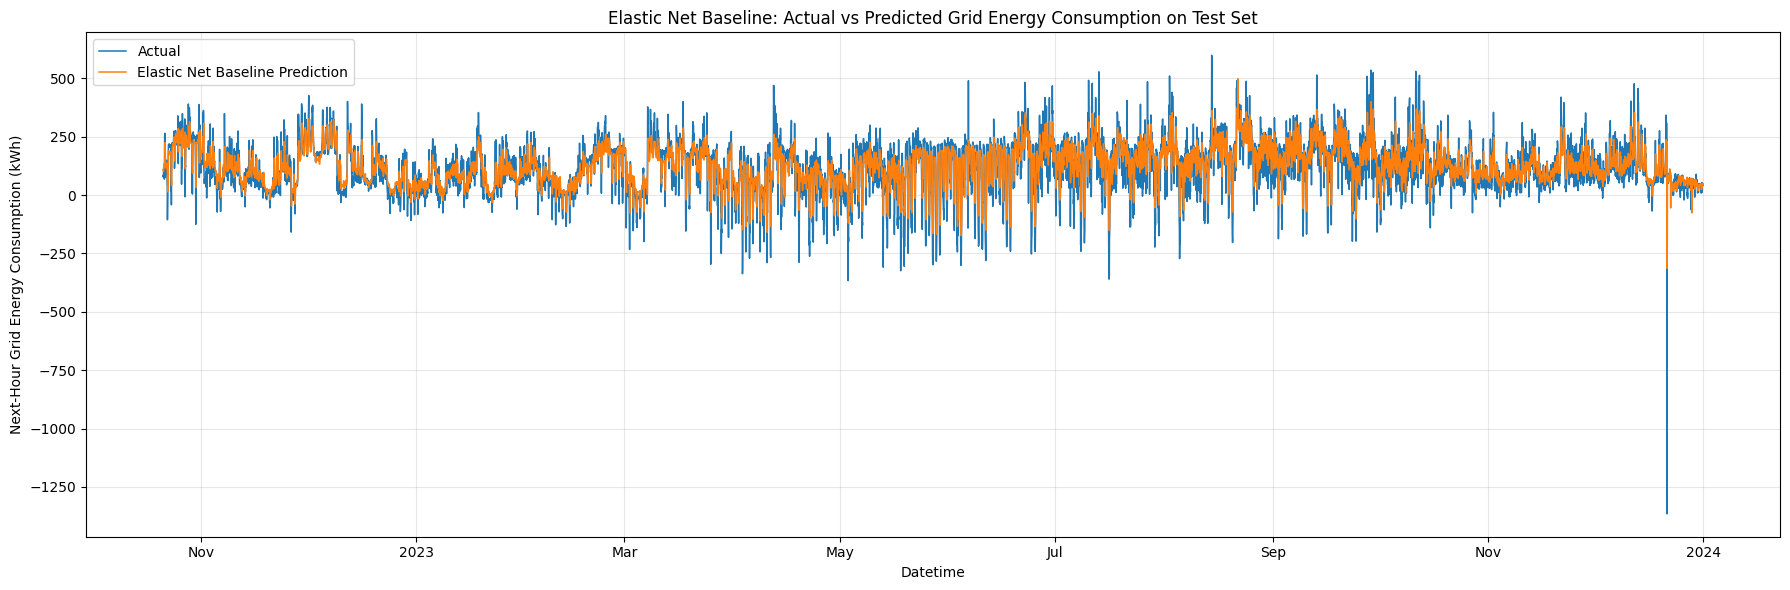

time: 187 ms (started: 2026-05-30 23:42:45 +03:00)


In [123]:
baseline_test_plot_df = create_test_prediction_plot_df(
    full_df=model_df_features_clean,
    X_train=X_train,
    y_test=y_test,
    predictions=baseline_elastic_pred,
    prediction_col_name="baseline_prediction",
    target_col=target_col
)

plt.figure(figsize=(18, 6))

plt.plot(
    baseline_test_plot_df[DATETIME_COL],
    baseline_test_plot_df["actual"],
    label="Actual",
    linewidth=1.1
)

plt.plot(
    baseline_test_plot_df[DATETIME_COL],
    baseline_test_plot_df["baseline_prediction"],
    label="Elastic Net Baseline Prediction",
    linewidth=1.1
)

plt.title("Elastic Net Baseline: Actual vs Predicted Grid Energy Consumption on Test Set")
plt.xlabel("Datetime")
plt.ylabel("Next-Hour Grid Energy Consumption (kWh)")
plt.grid(True, alpha=0.3)
plt.legend()

ax = plt.gca()
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

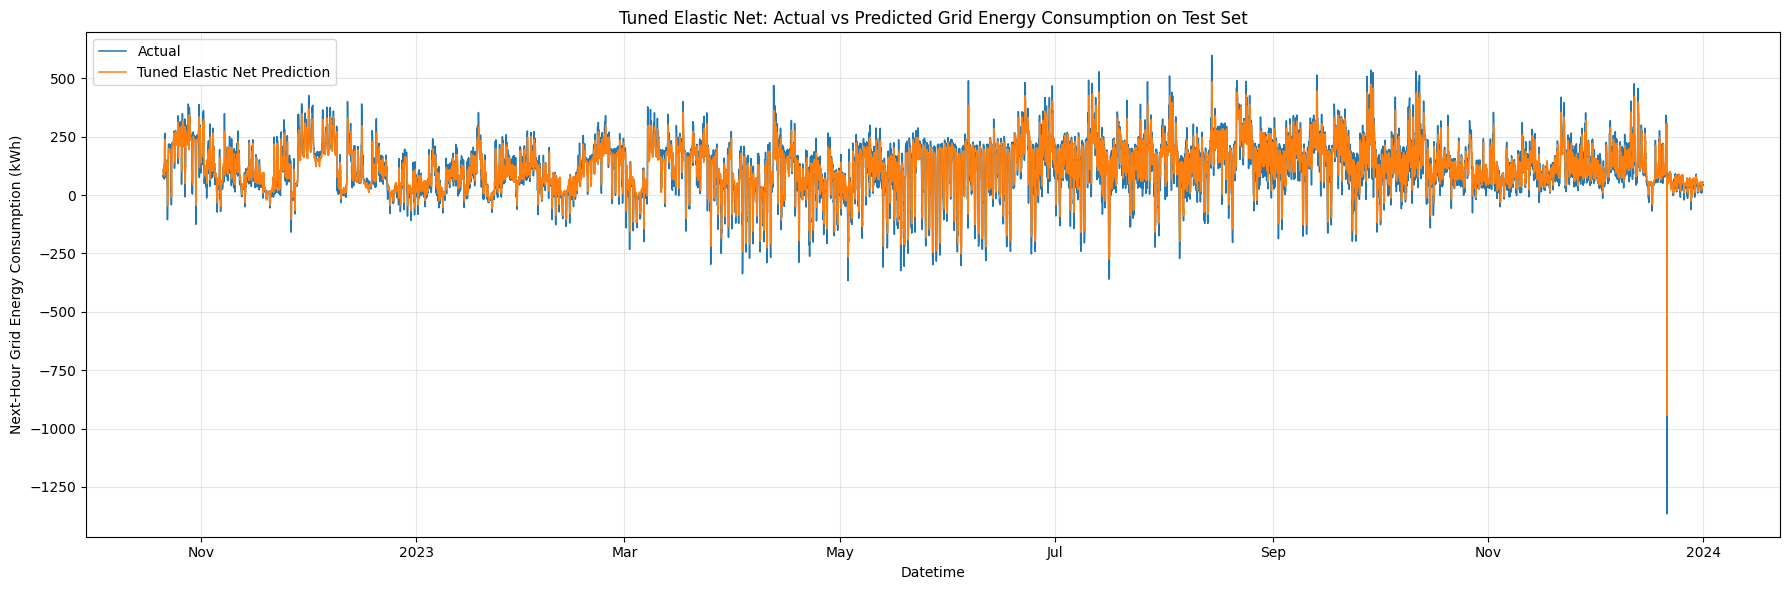

time: 265 ms (started: 2026-05-30 23:42:45 +03:00)


In [124]:
tuned_test_plot_df = create_test_prediction_plot_df(
    full_df=model_df_features_clean,
    X_train=X_train,
    y_test=y_test,
    predictions=tuned_elastic_pred,
    prediction_col_name="tuned_prediction",
    target_col=target_col
)

plt.figure(figsize=(18, 6))

plt.plot(
    tuned_test_plot_df[DATETIME_COL],
    tuned_test_plot_df["actual"],
    label="Actual",
    linewidth=1.1
)

plt.plot(
    tuned_test_plot_df[DATETIME_COL],
    tuned_test_plot_df["tuned_prediction"],
    label="Tuned Elastic Net Prediction",
    linewidth=1.1
)

plt.title("Tuned Elastic Net: Actual vs Predicted Grid Energy Consumption on Test Set")
plt.xlabel("Datetime")
plt.ylabel("Next-Hour Grid Energy Consumption (kWh)")
plt.grid(True, alpha=0.3)
plt.legend()

ax = plt.gca()
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

## Random Forest Regressor

### Random Forest Regressor (Baseline)

In [125]:
rf_baseline_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_baseline_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

time: 9.08 s (started: 2026-05-30 23:42:46 +03:00)


In [126]:
rf_baseline_pred = rf_baseline_model.predict(X_test)

rf_baseline_results = evaluate_regression(
    y_true=y_test,
    y_pred=rf_baseline_pred,
    model_name="Random Forest Baseline"
)

rf_baseline_results

{'Model': 'Random Forest Baseline',
 'MAE': 38.12179348675319,
 'RMSE': np.float64(57.23504699403764),
 'R2': 0.748254963018288,
 'MedianAE': np.float64(24.51422687794127),
 'P95AE': np.float64(120.11440337029605),
 'P99AE': np.float64(174.8867756597658)}

time: 47 ms (started: 2026-05-30 23:42:55 +03:00)


In [127]:
model_comparison_df = pd.DataFrame([
    elastic_results,
    tuned_elastic_results,
    rf_baseline_results
])

model_comparison_df.sort_values("RMSE")

,Model,MAE,RMSE,R2,MedianAE,P95AE,P99AE
2,Random Forest Baseline,38.121793,57.235047,0.748255,24.514227,120.114403,174.886776
1,Tuned Elastic Net,41.243511,60.544739,0.718298,27.211549,123.926863,180.764432
0,Elastic Net Baseline,47.382809,66.192391,0.663292,34.095550,135.738254,201.511312


time: 0 ns (started: 2026-05-30 23:42:55 +03:00)


In [128]:
rf_baseline_cv_results = time_series_cv(
    model=rf_baseline_model,
    X=X_train,
    y=y_train,
    model_name="Random Forest Baseline",
    scale=False
)

display(rf_baseline_cv_results)

rf_baseline_cv_summary = rf_baseline_cv_results[metric_cols].agg(["mean", "std"]).T
display(rf_baseline_cv_summary)

,Model,MAE,RMSE,R2,MedianAE,P95AE,P99AE,Fold,Train Rows,Validation Rows
0,Random Forest Baseline,35.676404,49.735549,0.811042,25.566351,104.256291,149.098035,1,6990,6988
1,Random Forest Baseline,28.023058,48.337264,0.775691,20.502930,77.473516,115.097422,2,13978,6988
2,Random Forest Baseline,35.884385,54.920016,0.708144,21.226883,117.733538,197.974444,3,20966,6988
3,Random Forest Baseline,35.907295,54.910912,0.801811,21.720866,119.228998,199.491634,4,27954,6988
4,Random Forest Baseline,32.472738,50.341523,0.824539,19.144335,105.387205,187.750044,5,34942,6988


,mean,std
MAE,33.592776,3.436067
RMSE,51.649053,3.069120
R2,0.784245,0.046137
MedianAE,21.632273,2.403872
P95AE,104.815910,16.754464
P99AE,169.882316,36.805251


time: 20 s (started: 2026-05-30 23:42:55 +03:00)


### Random Forests (Hyperparameters Tuning)

### Try loading Tuned Random Forest

In [129]:
tuned_rf_artifact = should_use_saved_model(
    model_name="Tuned Random Forest",
    X=X_train,
    use_saved_models=USE_SAVED_TUNED_MODELS,
    retrain_if_features_changed=RETRAIN_IF_FEATURES_CHANGED,
    experiment_name=None
)

rf_model_loaded = tuned_rf_artifact is not None

Looking for saved artifacts for: Tuned Random Forest
Model directory: D:\MSc in AI\Term 2\Machine Learning\Project\Code\outputs\saved_models
Candidate files found: 1
Compatible saved model found.
Path: outputs\saved_models\tuned_random_forest_sin_cos_hour_c81df027dccd_20260529_142118.joblib
Created at: 20260529_142118
Experiment: sin_cos_hour
Feature signature: c81df027dccd
Metrics: {'Model': 'Tuned Random Forest', 'MAE': 37.08873541253574, 'RMSE': np.float64(56.07700867116331), 'R2': 0.758339033676401, 'MedianAE': np.float64(23.216161335075498), 'P95AE': np.float64(119.31296257185289), 'P99AE': np.float64(171.89108218992413)}
Best params: {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 3, 'max_features': 0.7}
Feature check passed. Saved Tuned Random Forest can be used.
time: 359 ms (started: 2026-05-30 23:43:15 +03:00)


### Random Forest Hyperparameter Tuning or Load Saved Model

In [130]:
if rf_model_loaded:
    print("Skipping Random Forest fine-tuning because saved model was loaded.")

    rf_search_results_df = None

else:
    rf_search_results = []

    rf_param_grid = {
        "n_estimators": [100, 500, 1000],
        "max_depth": [4, 8, 12, None],
        "min_samples_leaf": [1, 3, 5, 7],
        "max_features": ["sqrt", 0.7, 1.0]
    }

    param_combinations = list(ParameterGrid(rf_param_grid))

    print(f"Total Random Forest combinations: {len(param_combinations)}")

    for run, params in enumerate(param_combinations, start=1):
        print(f"Running {run}/{len(param_combinations)}: {params}")

        model = RandomForestRegressor(
            **params,
            random_state=42,
            n_jobs=-1
        )

        cv_results = time_series_cv(
            model=model,
            X=X_train,
            y=y_train,
            model_name="Random Forest",
            scale=False
        )

        row = params.copy()

        for metric in metric_cols:
            row[f"{metric}_mean"] = cv_results[metric].mean()
            row[f"{metric}_std"] = cv_results[metric].std()

        rf_search_results.append(row)

    rf_search_results_df = pd.DataFrame(rf_search_results)

    rf_search_results_df = rf_search_results_df.sort_values(
        "RMSE_mean"
    ).reset_index(drop=True)

    display(rf_search_results_df.head(10))

Skipping Random Forest fine-tuning because saved model was loaded.
time: 15 ms (started: 2026-05-30 23:43:15 +03:00)


### Get Best Random Forest Hyperparameters

In [131]:
if rf_model_loaded:
    tuned_rf_model = tuned_rf_artifact["model"]
    best_rf_params = tuned_rf_artifact["best_params"]

    best_rf_row = pd.Series({
        "n_estimators": best_rf_params.get("n_estimators"),
        "max_depth": best_rf_params.get("max_depth"),
        "min_samples_leaf": best_rf_params.get("min_samples_leaf"),
        "max_features": best_rf_params.get("max_features"),
        "MAE_mean": np.nan,
        "RMSE_mean": np.nan,
        "R2_mean": np.nan,
        "MedianAE_mean": np.nan,
        "P95AE_mean": np.nan,
        "P99AE_mean": np.nan
    })

    print("Best Random Forest hyperparameters loaded from saved model:")
    print(best_rf_params)

    print("\nCV results not recalculated because model was loaded from saved artifact.")

else:
    best_rf_row = rf_search_results_df.iloc[0]

    best_rf_params = {
        "n_estimators": int(best_rf_row["n_estimators"]),
        "max_depth": None if pd.isna(best_rf_row["max_depth"]) else int(best_rf_row["max_depth"]),
        "min_samples_leaf": int(best_rf_row["min_samples_leaf"]),
        "max_features": best_rf_row["max_features"]
    }

    print("Best Random Forest hyperparameters:")
    print(best_rf_params)

    print("\nBest CV results:")
    print("CV MAE:", best_rf_row["MAE_mean"])
    print("CV RMSE:", best_rf_row["RMSE_mean"])
    print("CV R2:", best_rf_row["R2_mean"])
    print("CV MedianAE:", best_rf_row["MedianAE_mean"])
    print("CV P95AE:", best_rf_row["P95AE_mean"])
    print("CV P99AE:", best_rf_row["P99AE_mean"])

Best Random Forest hyperparameters loaded from saved model:
{'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 3, 'max_features': 0.7}

CV results not recalculated because model was loaded from saved artifact.
time: 0 ns (started: 2026-05-30 23:43:15 +03:00)


### Evaluate Tuned Random Forest on Test Data

In [132]:
if rf_model_loaded:
    X_test_for_rf = X_test[tuned_rf_artifact["feature_columns"]]
    tuned_rf_pred = tuned_rf_model.predict(X_test_for_rf)

else:
    tuned_rf_model = RandomForestRegressor(
        **best_rf_params,
        random_state=42,
        n_jobs=-1
    )

    tuned_rf_model.fit(X_train, y_train)

    tuned_rf_pred = tuned_rf_model.predict(X_test)

tuned_rf_results = evaluate_regression(
    y_true=y_test,
    y_pred=tuned_rf_pred,
    model_name="Tuned Random Forest"
)

tuned_rf_results

{'Model': 'Tuned Random Forest',
 'MAE': 37.08873541253574,
 'RMSE': np.float64(56.07700867116331),
 'R2': 0.758339033676401,
 'MedianAE': np.float64(23.216161335075512),
 'P95AE': np.float64(119.31296257185289),
 'P99AE': np.float64(171.89108218992416)}

time: 94 ms (started: 2026-05-30 23:43:15 +03:00)


### Save Tuned Random Forest

In [133]:
if rf_model_loaded:
    print("Tuned Random Forest was loaded from saved artifact. No need to save again.")

else:
    tuned_rf_artifact_path = save_model_artifact(
        model=tuned_rf_model,
        model_name="Tuned Random Forest",
        feature_columns=X_train.columns.tolist(),
        target_col=target_col,
        metrics=tuned_rf_results,
        best_params=best_rf_params,
        scaler=None,
        search_results_df=rf_search_results_df,
        experiment_name=EXPERIMENT_NAME
    )

Tuned Random Forest was loaded from saved artifact. No need to save again.
time: 0 ns (started: 2026-05-30 23:43:15 +03:00)


### Compare baseline models vs Tuned Models

In [134]:
model_comparison_df = pd.DataFrame([
    elastic_results,
    tuned_elastic_results,
    rf_baseline_results,
    tuned_rf_results
])

model_comparison_df.sort_values("RMSE")

,Model,MAE,RMSE,R2,MedianAE,P95AE,P99AE
3,Tuned Random Forest,37.088735,56.077009,0.758339,23.216161,119.312963,171.891082
2,Random Forest Baseline,38.121793,57.235047,0.748255,24.514227,120.114403,174.886776
1,Tuned Elastic Net,41.243511,60.544739,0.718298,27.211549,123.926863,180.764432
0,Elastic Net Baseline,47.382809,66.192391,0.663292,34.095550,135.738254,201.511312


time: 0 ns (started: 2026-05-30 23:43:15 +03:00)


### TreeSHAP Feature Importance for Random Forests

Tuned Random Forest: Default tree feature importance


,feature,importance
0,grid_energy_kwh,0.629514
1,grid_energy_kwh_lag_1h,0.192118
2,grid_energy_kwh_rolling_mean_24h,0.036058
3,grid_energy_kwh_lag_168h,0.019550
4,grid_energy_kwh_lag_24h,0.015954
5,hour_sin,0.014396
6,chp_energy_kwh,0.014337
7,hour_cos,0.012587
8,outdoor_temperature_c,0.011763
9,cooling_electricity_kwh,0.008738


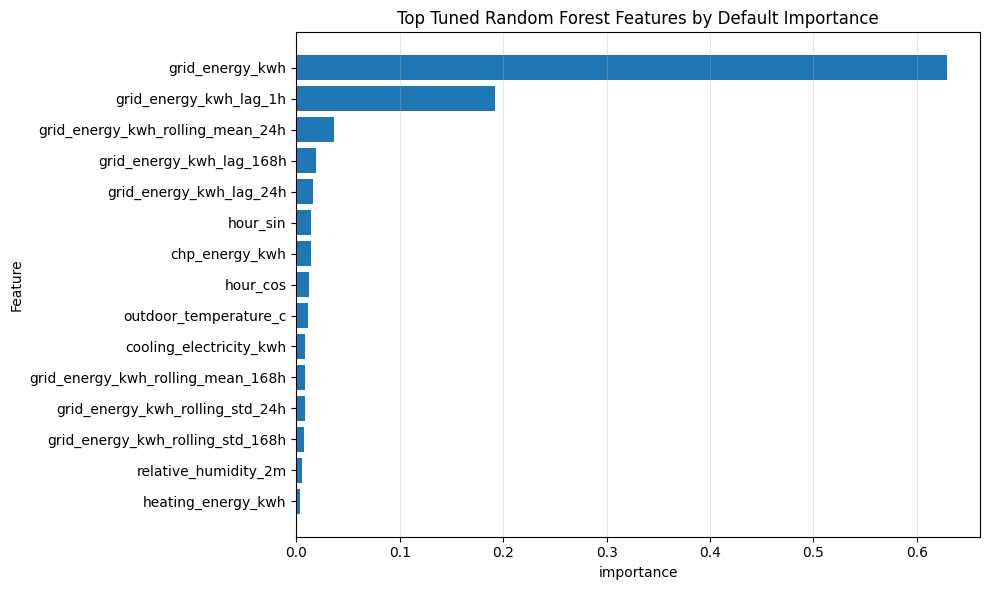

Tuned Random Forest: TreeSHAP analysis
SHAP sample shape: (2000, 21)
Creating TreeExplainer...
Computing SHAP values. This may take time for Random Forest...
SHAP values computed.


,feature,mean_abs_shap
0,grid_energy_kwh,65.808704
1,grid_energy_kwh_lag_1h,21.866646
2,chp_energy_kwh,5.645664
3,grid_energy_kwh_rolling_mean_24h,5.483833
4,hour_sin,4.250601
5,outdoor_temperature_c,4.175371
6,grid_energy_kwh_lag_24h,3.024528
7,hour_cos,2.996501
8,grid_energy_kwh_rolling_mean_168h,2.765343
9,grid_energy_kwh_lag_168h,2.384749


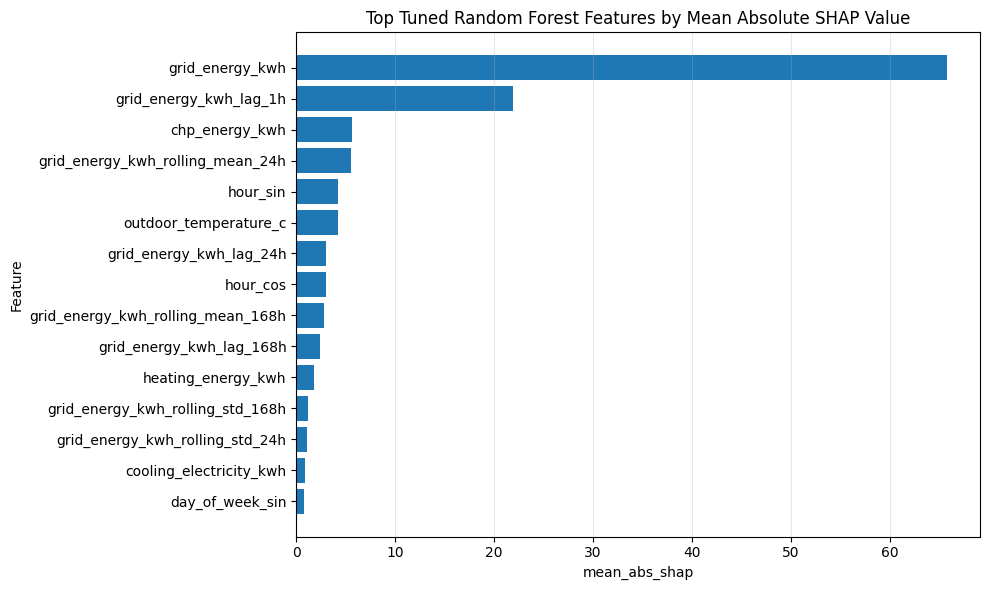

Creating SHAP summary plot...


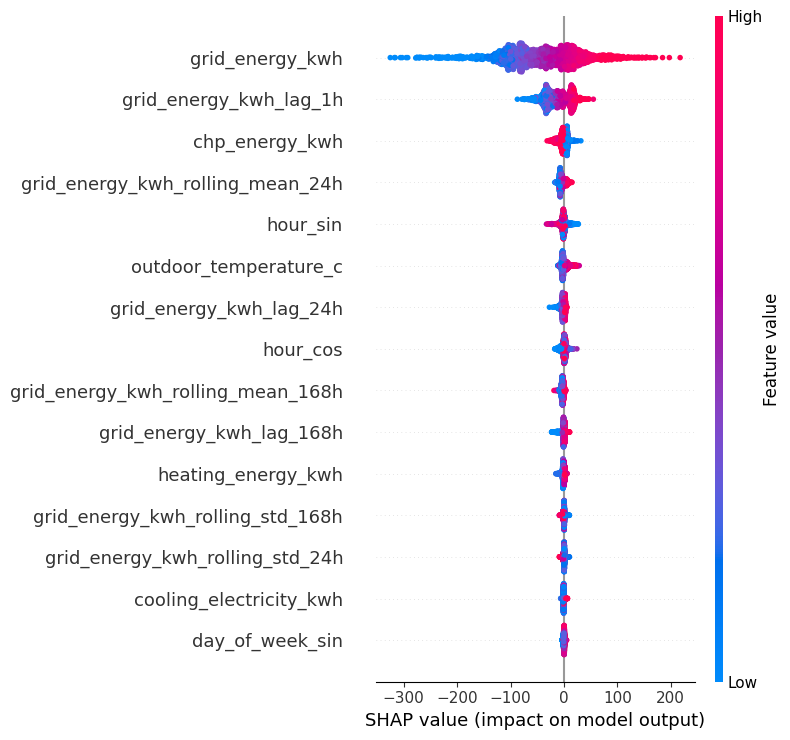

SHAP summary plot completed.
time: 25min 55s (started: 2026-05-30 23:43:15 +03:00)


In [135]:
rf_default_importance, rf_shap_sample_df, rf_shap_values, rf_shap_importance = run_tree_interpretability(
    model=tuned_rf_model,
    X=X_test,
    model_label="Tuned Random Forest",
    sample_size=2000,
    top_n=15
)

### Plot Baseline and Tuned Random Forest Predictions vs Actual

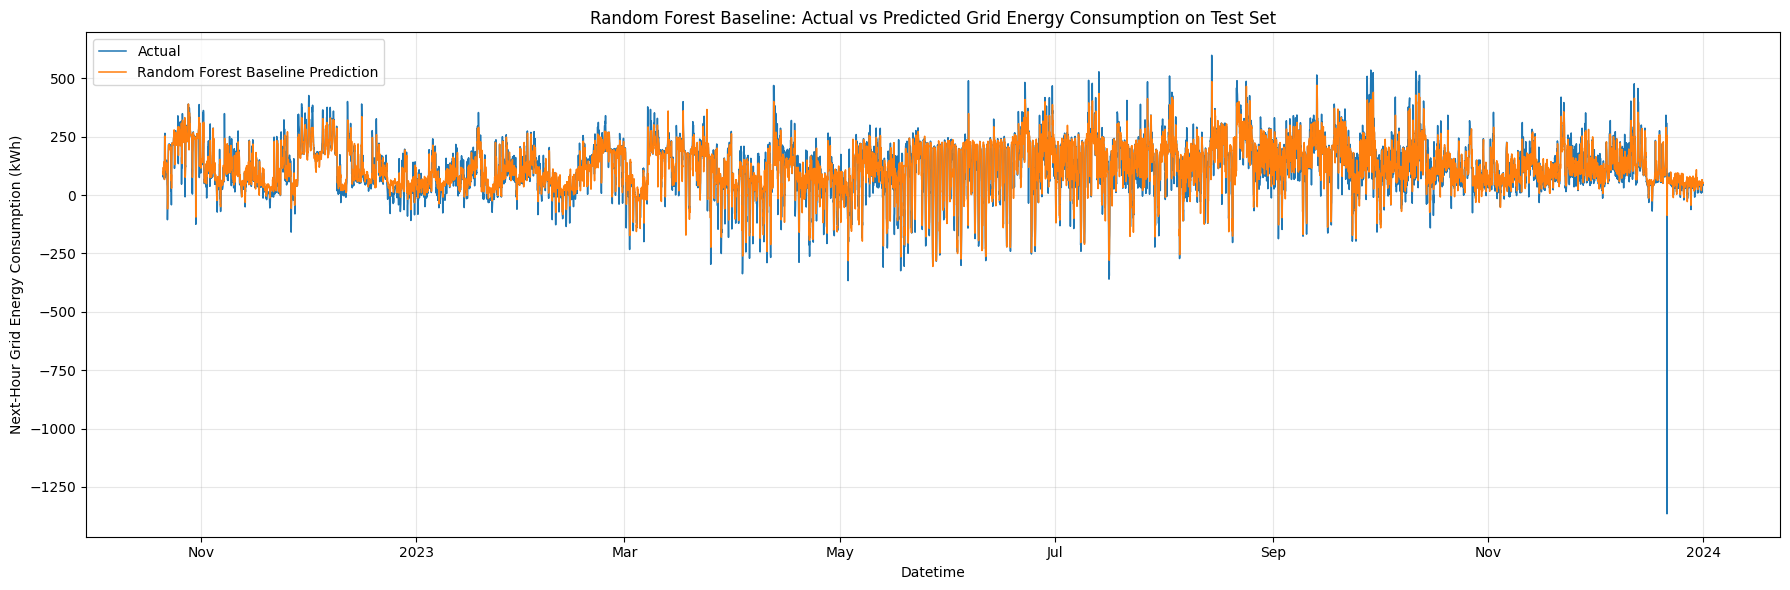

time: 282 ms (started: 2026-05-31 00:09:10 +03:00)


In [136]:
rf_baseline_test_plot_df = create_test_prediction_plot_df(
    full_df=model_df_features_clean,
    X_train=X_train,
    y_test=y_test,
    predictions=rf_baseline_pred,
    prediction_col_name="rf_baseline_prediction",
    target_col=target_col
)

plt.figure(figsize=(18, 6))

plt.plot(
    rf_baseline_test_plot_df[DATETIME_COL],
    rf_baseline_test_plot_df["actual"],
    label="Actual",
    linewidth=1.1
)

plt.plot(
    rf_baseline_test_plot_df[DATETIME_COL],
    rf_baseline_test_plot_df["rf_baseline_prediction"],
    label="Random Forest Baseline Prediction",
    linewidth=1.1
)

plt.title("Random Forest Baseline: Actual vs Predicted Grid Energy Consumption on Test Set")
plt.xlabel("Datetime")
plt.ylabel("Next-Hour Grid Energy Consumption (kWh)")
plt.grid(True, alpha=0.3)
plt.legend()

ax = plt.gca()
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

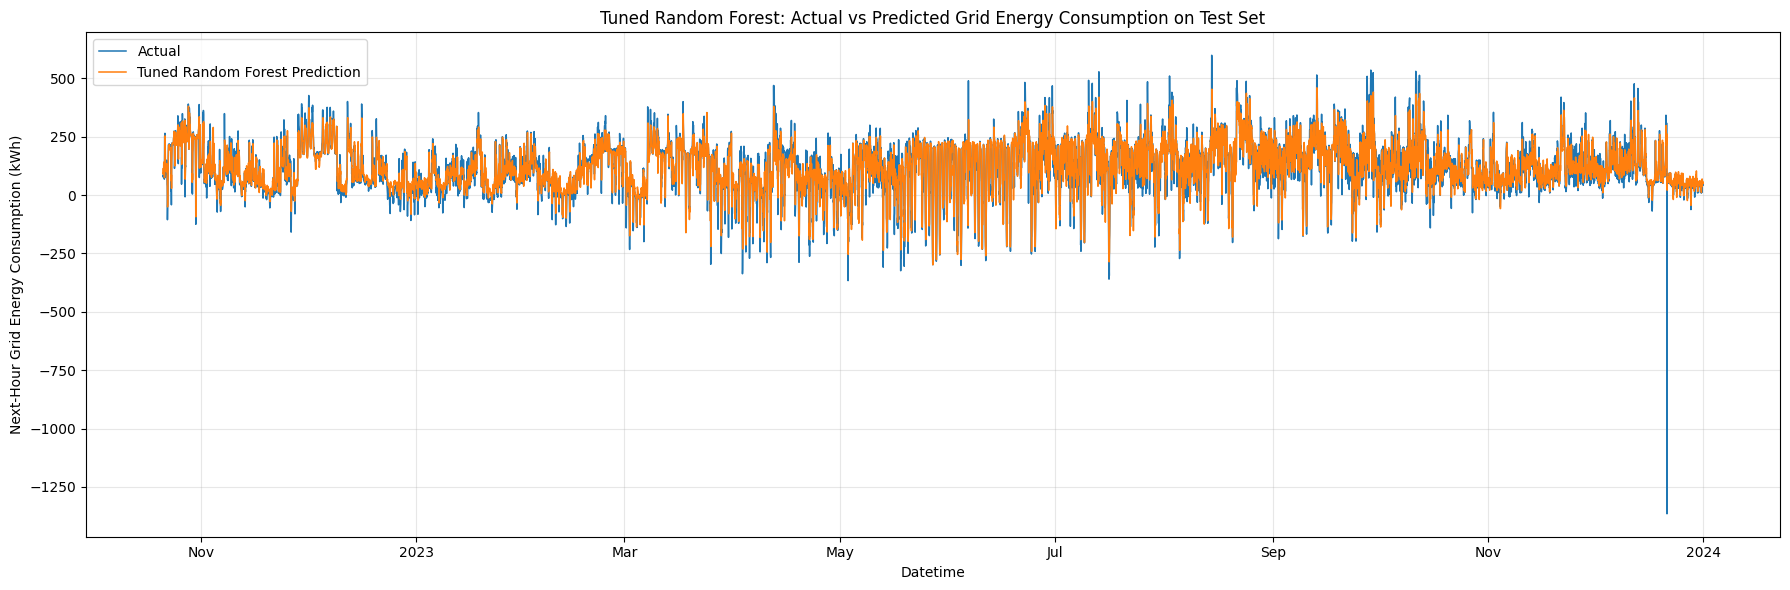

time: 187 ms (started: 2026-05-31 00:09:11 +03:00)


In [137]:
rf_test_plot_df = create_test_prediction_plot_df(
    full_df=model_df_features_clean,
    X_train=X_train,
    y_test=y_test,
    predictions=tuned_rf_pred,
    prediction_col_name="tuned_rf_prediction",
    target_col=target_col
)

plt.figure(figsize=(18, 6))

plt.plot(
    rf_test_plot_df[DATETIME_COL],
    rf_test_plot_df["actual"],
    label="Actual",
    linewidth=1.1
)

plt.plot(
    rf_test_plot_df[DATETIME_COL],
    rf_test_plot_df["tuned_rf_prediction"],
    label="Tuned Random Forest Prediction",
    linewidth=1.1
)

plt.title("Tuned Random Forest: Actual vs Predicted Grid Energy Consumption on Test Set")
plt.xlabel("Datetime")
plt.ylabel("Next-Hour Grid Energy Consumption (kWh)")
plt.grid(True, alpha=0.3)
plt.legend()

ax = plt.gca()
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

## XGboost

### XGboost (Baseline)

In [138]:
xgb_baseline_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    device="cuda",
    random_state=42,
    n_jobs=-1
)

xgb_baseline_model.fit(X_train, y_train)

xgb_baseline_pred = xgb_baseline_model.predict(X_test)

xgb_baseline_results = evaluate_regression(
    y_true=y_test,
    y_pred=xgb_baseline_pred,
    model_name="XGBoost Baseline"
)

xgb_baseline_results

C:\Users\salma\anaconda3\envs\ML_DM_venv\Lib\site-packages\xgboost\core.py:751: UserWarning: [00:09:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


{'Model': 'XGBoost Baseline',
 'MAE': 37.325548350149134,
 'RMSE': np.float64(56.10693278067424),
 'R2': 0.7580810520598731,
 'MedianAE': np.float64(23.67905419971794),
 'P95AE': np.float64(118.44871278591445),
 'P99AE': np.float64(172.37598192326726)}

time: 797 ms (started: 2026-05-31 00:09:11 +03:00)


### XGboost Using CV (Baseline)

In [139]:
xgb_baseline_cv_results = time_series_cv(
    model=xgb_baseline_model,
    X=X_train,
    y=y_train,
    model_name="XGBoost Baseline",
    scale=False
)

display(xgb_baseline_cv_results)

xgb_baseline_cv_summary = xgb_baseline_cv_results[metric_cols].agg(["mean", "std"]).T
display(xgb_baseline_cv_summary)

,Model,MAE,RMSE,R2,MedianAE,P95AE,P99AE,Fold,Train Rows,Validation Rows
0,XGBoost Baseline,36.292463,49.929074,0.809568,26.525831,101.212536,141.013033,1,6990,6988
1,XGBoost Baseline,28.462173,48.558021,0.773637,21.033682,79.034219,116.017864,2,13978,6988
2,XGBoost Baseline,40.497901,67.266271,0.562174,22.103699,144.129997,280.634723,3,20966,6988
3,XGBoost Baseline,35.830637,55.670641,0.796289,21.441321,120.372183,207.287399,4,27954,6988
4,XGBoost Baseline,30.560909,48.377410,0.837963,17.496408,102.263582,179.391007,5,34942,6988


,mean,std
MAE,34.328817,4.816212
RMSE,53.960283,8.009029
R2,0.755926,0.110782
MedianAE,21.720188,3.226091
P95AE,109.402503,24.323883
P99AE,184.868805,63.967749


time: 3.47 s (started: 2026-05-31 00:09:12 +03:00)


### XGboost feature Importance (Baseline)

In [140]:
xgb_feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_baseline_model.feature_importances_
})

xgb_feature_importance = xgb_feature_importance.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

display(xgb_feature_importance)

,feature,importance
0,grid_energy_kwh,0.569053
1,grid_energy_kwh_lag_1h,0.136583
2,grid_energy_kwh_rolling_mean_24h,0.056180
3,hour_sin,0.025029
4,grid_energy_kwh_lag_168h,0.023989
5,hour_cos,0.021256
6,is_weekend,0.018190
7,chp_energy_kwh,0.015618
8,grid_energy_kwh_lag_24h,0.014409
9,outdoor_temperature_c,0.013647


time: 0 ns (started: 2026-05-31 00:09:15 +03:00)


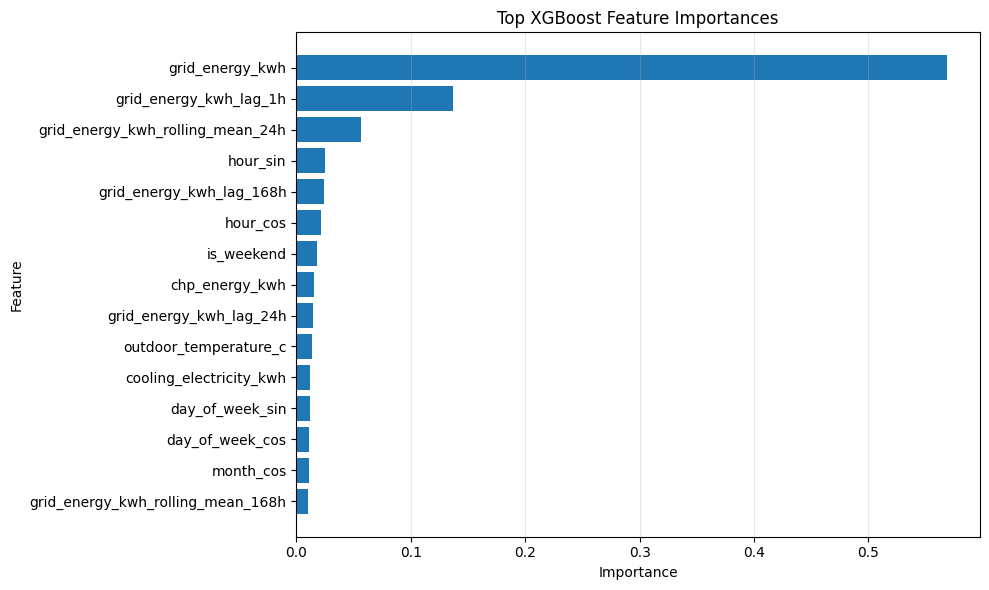

time: 79 ms (started: 2026-05-31 00:09:15 +03:00)


In [141]:
top_n = 15

plt.figure(figsize=(10, 6))

plt.barh(
    xgb_feature_importance.head(top_n)["feature"][::-1],
    xgb_feature_importance.head(top_n)["importance"][::-1]
)

plt.title("Top XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### XGboost Prediction Visualization

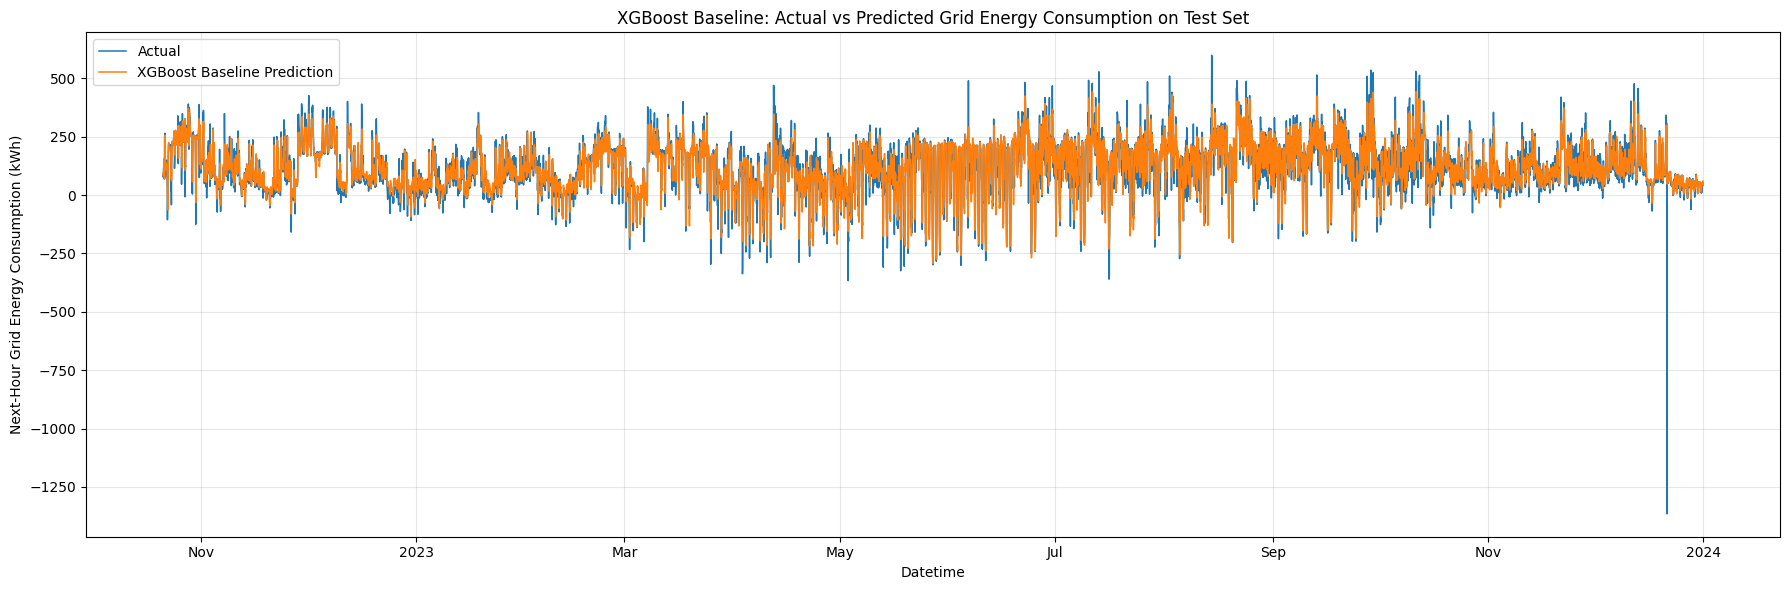

time: 187 ms (started: 2026-05-31 00:09:15 +03:00)


In [142]:
xgb_test_plot_df = create_test_prediction_plot_df(
    full_df=model_df_features_clean,
    X_train=X_train,
    y_test=y_test,
    predictions=xgb_baseline_pred,
    prediction_col_name="xgb_baseline_prediction",
    target_col=target_col
)

plt.figure(figsize=(18, 6))

plt.plot(
    xgb_test_plot_df[DATETIME_COL],
    xgb_test_plot_df["actual"],
    label="Actual",
    linewidth=1.1
)

plt.plot(
    xgb_test_plot_df[DATETIME_COL],
    xgb_test_plot_df["xgb_baseline_prediction"],
    label="XGBoost Baseline Prediction",
    linewidth=1.1
)

plt.title("XGBoost Baseline: Actual vs Predicted Grid Energy Consumption on Test Set")
plt.xlabel("Datetime")
plt.ylabel("Next-Hour Grid Energy Consumption (kWh)")
plt.grid(True, alpha=0.3)
plt.legend()

ax = plt.gca()
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

### XGboost Hyperparameter Tuning

### Try loading Tuned XGboost

In [143]:
tuned_xgb_artifact = should_use_saved_model(
    model_name="Tuned XGBoost",
    X=X_train,
    use_saved_models=USE_SAVED_TUNED_MODELS,
    retrain_if_features_changed=RETRAIN_IF_FEATURES_CHANGED,
    experiment_name=None
)

xgb_model_loaded = tuned_xgb_artifact is not None

Looking for saved artifacts for: Tuned XGBoost
Model directory: D:\MSc in AI\Term 2\Machine Learning\Project\Code\outputs\saved_models
Candidate files found: 1
Compatible saved model found.
Path: outputs\saved_models\tuned_xgboost_sin_cos_hour_c81df027dccd_20260529_161305.joblib
Created at: 20260529_161305
Experiment: sin_cos_hour
Feature signature: c81df027dccd
Metrics: {'Model': 'Tuned XGBoost', 'MAE': 37.12142724654595, 'RMSE': np.float64(55.61835850727382), 'R2': 0.7622759260577316, 'MedianAE': np.float64(23.83491001650691), 'P95AE': np.float64(117.62540154084562), 'P99AE': np.float64(167.98885465573522)}
Best params: {'n_estimators': 1000, 'learning_rate': 0.01, 'max_depth': 4, 'subsample': 0.6, 'colsample_bytree': 1.0, 'reg_lambda': 5.0}
Feature check passed. Saved Tuned XGBoost can be used.
time: 0 ns (started: 2026-05-31 00:09:16 +03:00)


### XGBoost Hyperparameter Tuning or Load Saved Model

In [144]:
if xgb_model_loaded:
    print("Skipping XGBoost fine-tuning because saved model was loaded.")

    xgb_search_results_df = None

else:
    xgb_search_results = []

    xgb_param_grid = {
        "n_estimators": [100, 500, 1000],
        "learning_rate": [0.001, 0.005, 0.01, 0.05],
        "max_depth": [3, 4, 5, 6],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "reg_lambda": [0.1, 1, 5]
    }

    param_combinations = list(ParameterGrid(xgb_param_grid))

    print(f"Total XGBoost combinations: {len(param_combinations)}")
    print(f"Total model trainings with 5 CV folds: {len(param_combinations) * 5}")

    checkpoint_path = Path("outputs/xgb_search_results_checkpoint.csv")
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

    start_time = time.time()

    for run, params in enumerate(param_combinations, start=1):
        print("=" * 80)
        print(f"Running {run}/{len(param_combinations)}: {params}")

        model = XGBRegressor(
            objective="reg:squarederror",
            eval_metric="rmse",
            tree_method="hist",
            device="cuda",
            random_state=42,
            n_jobs=-1,
            **params
        )

        cv_results = time_series_cv(
            model=model,
            X=X_train,
            y=y_train,
            model_name="XGBoost",
            scale=False
        )

        row = params.copy()

        for metric in metric_cols:
            row[f"{metric}_mean"] = cv_results[metric].mean()
            row[f"{metric}_std"] = cv_results[metric].std()

        xgb_search_results.append(row)

        pd.DataFrame(xgb_search_results).to_csv(checkpoint_path, index=False)

    elapsed_minutes = (time.time() - start_time) / 60
    print(f"XGBoost tuning completed in {elapsed_minutes:.2f} minutes.")

    xgb_search_results_df = pd.DataFrame(xgb_search_results)

    xgb_search_results_df = xgb_search_results_df.sort_values(
        "RMSE_mean"
    ).reset_index(drop=True)

    display(xgb_search_results_df.head(10))

Skipping XGBoost fine-tuning because saved model was loaded.
time: 0 ns (started: 2026-05-31 00:09:16 +03:00)


### Get Best XGboost Hyperparameters

In [145]:
if xgb_model_loaded:
    tuned_xgb_model = tuned_xgb_artifact["model"]
    best_xgb_params = tuned_xgb_artifact["best_params"]

    best_xgb_row = pd.Series({
        "n_estimators": best_xgb_params.get("n_estimators"),
        "learning_rate": best_xgb_params.get("learning_rate"),
        "max_depth": best_xgb_params.get("max_depth"),
        "subsample": best_xgb_params.get("subsample"),
        "colsample_bytree": best_xgb_params.get("colsample_bytree"),
        "reg_lambda": best_xgb_params.get("reg_lambda"),
        "MAE_mean": np.nan,
        "RMSE_mean": np.nan,
        "R2_mean": np.nan,
        "MedianAE_mean": np.nan,
        "P95AE_mean": np.nan,
        "P99AE_mean": np.nan
    })

    print("Best XGBoost hyperparameters loaded from saved model:")
    print(best_xgb_params)

    print("\nCV results not recalculated because model was loaded from saved artifact.")

else:
    best_xgb_row = xgb_search_results_df.iloc[0]

    best_xgb_params = {
        "n_estimators": int(best_xgb_row["n_estimators"]),
        "learning_rate": float(best_xgb_row["learning_rate"]),
        "max_depth": int(best_xgb_row["max_depth"]),
        "subsample": float(best_xgb_row["subsample"]),
        "colsample_bytree": float(best_xgb_row["colsample_bytree"]),
        "reg_lambda": float(best_xgb_row["reg_lambda"])
    }

    print("Best XGBoost hyperparameters:")
    print(best_xgb_params)

    print("\nBest CV results:")
    print("CV MAE:", best_xgb_row["MAE_mean"])
    print("CV RMSE:", best_xgb_row["RMSE_mean"])
    print("CV R2:", best_xgb_row["R2_mean"])
    print("CV MedianAE:", best_xgb_row["MedianAE_mean"])
    print("CV P95AE:", best_xgb_row["P95AE_mean"])
    print("CV P99AE:", best_xgb_row["P99AE_mean"])

Best XGBoost hyperparameters loaded from saved model:
{'n_estimators': 1000, 'learning_rate': 0.01, 'max_depth': 4, 'subsample': 0.6, 'colsample_bytree': 1.0, 'reg_lambda': 5.0}

CV results not recalculated because model was loaded from saved artifact.
time: 0 ns (started: 2026-05-31 00:09:16 +03:00)


### Evaluate Tuned XGboost on test data

In [146]:
if xgb_model_loaded:
    X_test_for_xgb = X_test[tuned_xgb_artifact["feature_columns"]]
    tuned_xgb_pred = tuned_xgb_model.predict(X_test_for_xgb)

else:
    tuned_xgb_model = XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        device="cuda",
        random_state=42,
        n_jobs=-1,
        **best_xgb_params
    )

    tuned_xgb_model.fit(X_train, y_train)

    tuned_xgb_pred = tuned_xgb_model.predict(X_test)

tuned_xgb_results = evaluate_regression(
    y_true=y_test,
    y_pred=tuned_xgb_pred,
    model_name="Tuned XGBoost"
)

tuned_xgb_results

{'Model': 'Tuned XGBoost',
 'MAE': 37.12142724654595,
 'RMSE': np.float64(55.61835850727382),
 'R2': 0.7622759260577316,
 'MedianAE': np.float64(23.83491001650691),
 'P95AE': np.float64(117.62540154084562),
 'P99AE': np.float64(167.98885465573522)}

time: 47 ms (started: 2026-05-31 00:09:16 +03:00)


### Save Tuned XGBoost

In [147]:
if xgb_model_loaded:
    print("Tuned XGBoost was loaded from saved artifact. No need to save again.")

else:
    tuned_xgb_artifact_path = save_model_artifact(
        model=tuned_xgb_model,
        model_name="Tuned XGBoost",
        feature_columns=X_train.columns.tolist(),
        target_col=target_col,
        metrics=tuned_xgb_results,
        best_params=best_xgb_params,
        scaler=None,
        search_results_df=xgb_search_results_df,
        experiment_name=EXPERIMENT_NAME
)

Tuned XGBoost was loaded from saved artifact. No need to save again.
time: 0 ns (started: 2026-05-31 00:09:16 +03:00)


### Models comparison

In [148]:
model_comparison_df = pd.DataFrame([
    elastic_results,
    tuned_elastic_results,
    rf_baseline_results,
    tuned_rf_results,
    xgb_baseline_results,
    tuned_xgb_results
])

model_comparison_df = model_comparison_df.sort_values("RMSE").reset_index(drop=True)

display(model_comparison_df)

,Model,MAE,RMSE,R2,MedianAE,P95AE,P99AE
0,Tuned XGBoost,37.121427,55.618359,0.762276,23.834910,117.625402,167.988855
1,Tuned Random Forest,37.088735,56.077009,0.758339,23.216161,119.312963,171.891082
2,XGBoost Baseline,37.325548,56.106933,0.758081,23.679054,118.448713,172.375982
3,Random Forest Baseline,38.121793,57.235047,0.748255,24.514227,120.114403,174.886776
4,Tuned Elastic Net,41.243511,60.544739,0.718298,27.211549,123.926863,180.764432
5,Elastic Net Baseline,47.382809,66.192391,0.663292,34.095550,135.738254,201.511312


time: 0 ns (started: 2026-05-31 00:09:16 +03:00)


### TreeSHAP Feature Importance for hyperparameter-tuned XGboost

Tuned XGBoost: Default tree feature importance


,feature,importance
0,grid_energy_kwh,0.711664
1,grid_energy_kwh_lag_1h,0.056167
2,grid_energy_kwh_rolling_mean_24h,0.028997
3,hour_sin,0.020967
4,hour_cos,0.018836
5,grid_energy_kwh_lag_168h,0.017070
6,chp_energy_kwh,0.016985
7,grid_energy_kwh_rolling_mean_168h,0.016084
8,outdoor_temperature_c,0.013764
9,is_weekend,0.013017


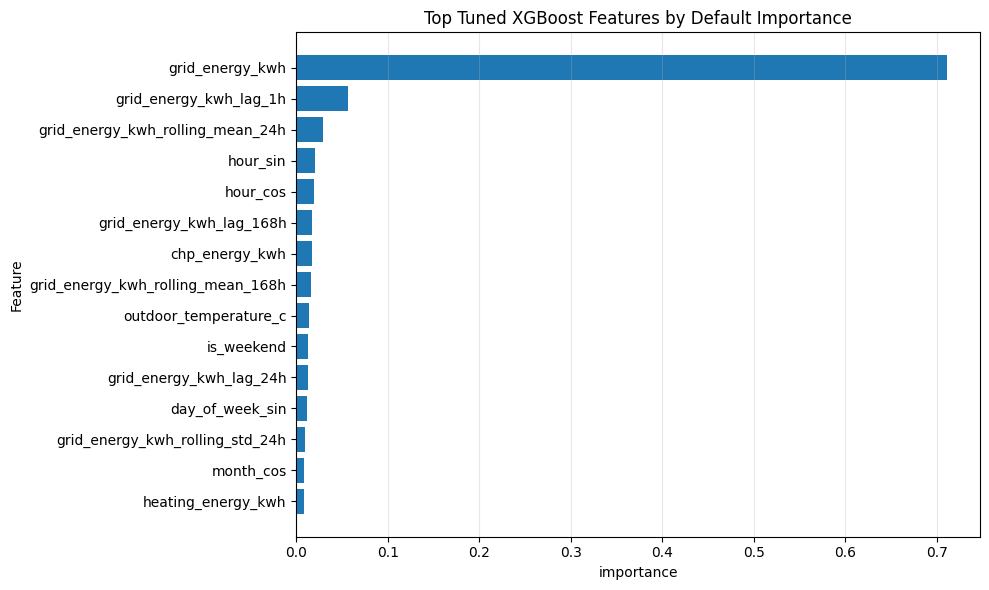

Tuned XGBoost: TreeSHAP analysis
SHAP sample shape: (2000, 21)
Creating TreeExplainer...
Computing SHAP values. This may take time for Random Forest...
SHAP values computed.


,feature,mean_abs_shap
0,grid_energy_kwh,72.484337
1,grid_energy_kwh_lag_1h,11.640162
2,chp_energy_kwh,7.960152
3,outdoor_temperature_c,7.242390
4,grid_energy_kwh_rolling_mean_24h,5.948525
5,hour_cos,4.033550
6,hour_sin,3.997688
7,grid_energy_kwh_lag_168h,2.873299
8,grid_energy_kwh_lag_24h,2.814244
9,heating_energy_kwh,2.385774


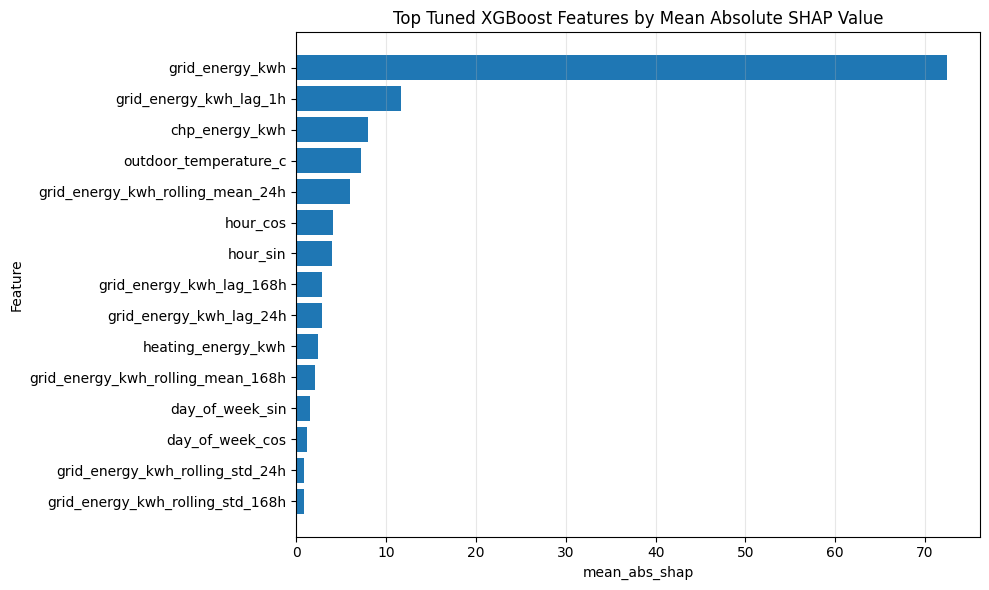

Creating SHAP summary plot...


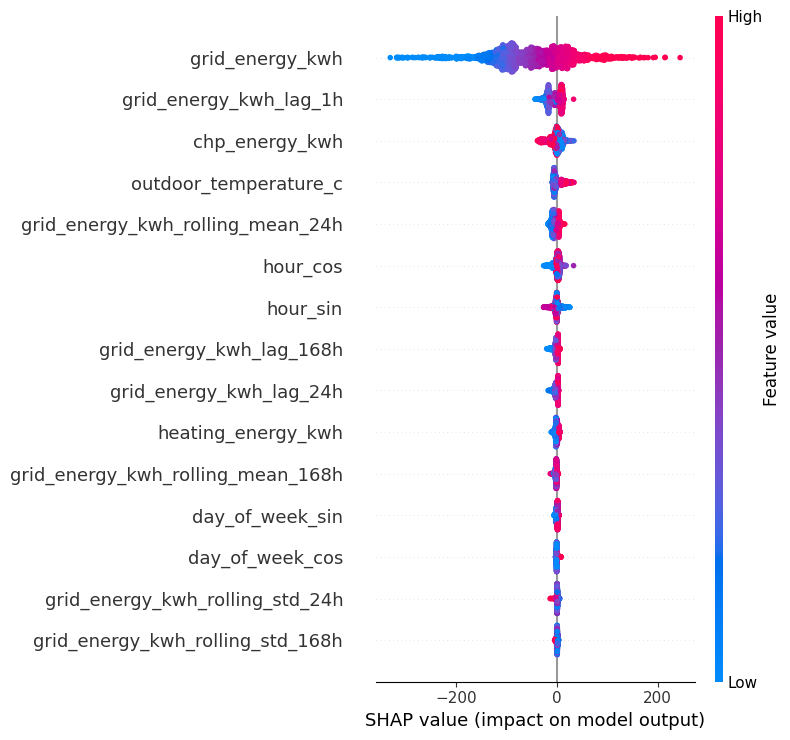

SHAP summary plot completed.
time: 641 ms (started: 2026-05-31 00:09:16 +03:00)


In [149]:
xgb_default_importance, xgb_shap_sample_df, xgb_shap_values, xgb_shap_importance = run_tree_interpretability(
    model=tuned_xgb_model,
    X=X_test,
    model_label="Tuned XGBoost",
    sample_size=2000,
    top_n=15
)

### Plot of predicitons for Hyperparameter-tuned XGboost

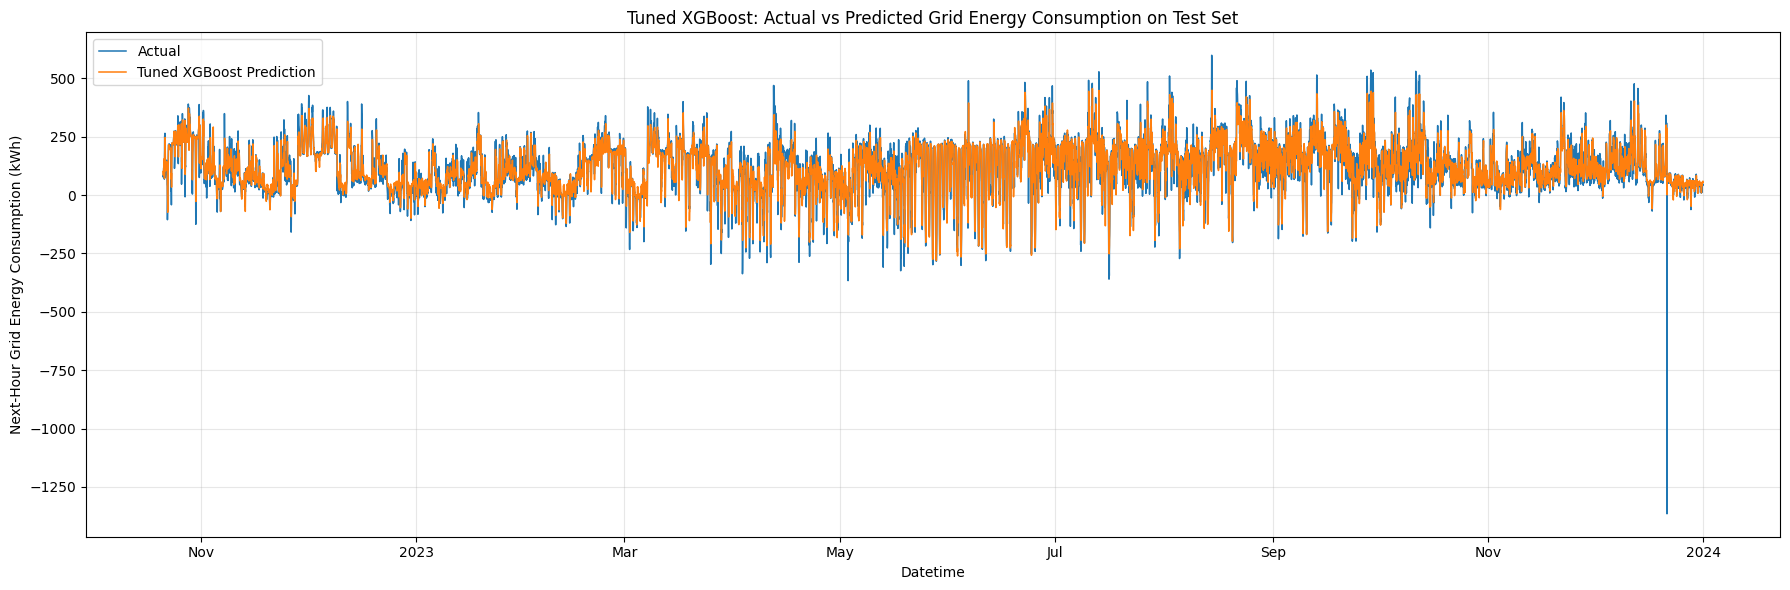

time: 187 ms (started: 2026-05-31 00:09:17 +03:00)


In [150]:
xgb_tuned_test_plot_df = create_test_prediction_plot_df(
    full_df=model_df_features_clean,
    X_train=X_train,
    y_test=y_test,
    predictions=tuned_xgb_pred,
    prediction_col_name="tuned_xgb_prediction",
    target_col=target_col
)

plt.figure(figsize=(18, 6))

plt.plot(
    xgb_tuned_test_plot_df[DATETIME_COL],
    xgb_tuned_test_plot_df["actual"],
    label="Actual",
    linewidth=1.1
)

plt.plot(
    xgb_tuned_test_plot_df[DATETIME_COL],
    xgb_tuned_test_plot_df["tuned_xgb_prediction"],
    label="Tuned XGBoost Prediction",
    linewidth=1.1
)

plt.title("Tuned XGBoost: Actual vs Predicted Grid Energy Consumption on Test Set")
plt.xlabel("Datetime")
plt.ylabel("Next-Hour Grid Energy Consumption (kWh)")
plt.grid(True, alpha=0.3)
plt.legend()

ax = plt.gca()
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

## Save the Final model comparison table

In [151]:
comparison_path = RESULTS_OUTPUT_DIR / "final_model_comparison.csv"
model_comparison_df.to_csv(comparison_path, index=False)

print(f"Saved final model comparison to: {comparison_path}")

Saved final model comparison to: outputs\model_results\final_model_comparison.csv
time: 15 ms (started: 2026-05-31 00:09:17 +03:00)


In [152]:
final_comparison_df = pd.read_csv(comparison_path)

time: 0 ns (started: 2026-05-31 00:09:17 +03:00)


In [153]:
final_comparison_df

,Model,MAE,RMSE,R2,MedianAE,P95AE,P99AE
0,Tuned XGBoost,37.121427,55.618359,0.762276,23.834910,117.625402,167.988855
1,Tuned Random Forest,37.088735,56.077009,0.758339,23.216161,119.312963,171.891082
2,XGBoost Baseline,37.325548,56.106933,0.758081,23.679054,118.448713,172.375982
3,Random Forest Baseline,38.121793,57.235047,0.748255,24.514227,120.114403,174.886776
4,Tuned Elastic Net,41.243511,60.544739,0.718298,27.211549,123.926863,180.764432
5,Elastic Net Baseline,47.382809,66.192391,0.663292,34.095550,135.738254,201.511312


time: 16 ms (started: 2026-05-31 00:09:17 +03:00)
